# **Gráficos e Tabelas do banco de dados filtrados**

In [11]:
%%capture
%run "/workspaces/CEA-1/análise de dados/dados_finais.ipynb"

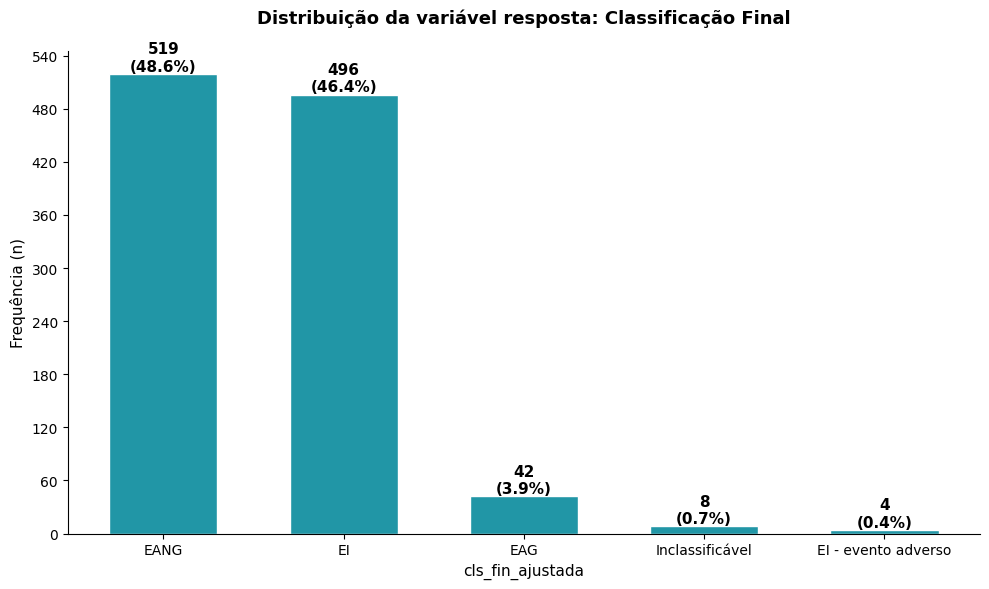

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
# ── Distribuição da variável resposta ────────────────────────────────────────
coluna_resposta = ['cls_fin_ajustada']
dados_finais = df_filtrado[coluna_resposta + colunas_explicativas]
resposta = coluna_resposta[0]
contagem_resposta = dados_finais[resposta].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    contagem_resposta.index.astype(str),
    contagem_resposta.values,
    color='#2196a6', edgecolor='white', width=0.6
)

for bar in bars:
    h = bar.get_height()
    pct = h / len(dados_finais) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5,
            f'{int(h)}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title(f'Distribuição da variável resposta: Classificação Final', fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel(resposta, fontsize=11)
ax.set_ylabel('Frequência (n)', fontsize=11)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## **cls_fin_ajustada vs explicativas**

In [13]:
coluna_resposta = ['cls_fin_ajustada']

colunas_explicativas = ['dt_not_ano', 'regiao', 'pais_nasc', 'sexo', 'cor', 'gestante',
            'dt_apl_ano', 'dose_ajustada', 'via_adm_ajustada', 'local_aplic_ajustada', 'tp_med', 'cls_ei_ajustada',  'tp_atd_ajustada', 
            'idade_anos','dor_abdominal', 'dor_no_corpo', 'artralgia', 'cefaleia', 'dor',
    'exantema_local', 'exantema', 'edema', 'eritema', 'calor', 'enduracao',
    'abscesso_quente', 'lesao', 'linfonodomegalia', 'prurido', 'febre',
    'nausea', 'emese', 'diarreia', 'tontura', 'sincope', 'parestesia',
    'convulsao', 'confusao_mental', 'fraqueza', 'hipotensao', 'taquicardia',
    'bradicardia', 'extremidades_frias', 'palidez', 'sudorese', 'urticaria',
    'broncoespasmo', 'dispneia', 'angioedema', 'tremor', 'fotofobia',
    'visao_turva', 'guillain_barre', 'encefalite', 'epilepsia', 'paralisia',
    'purpura_trombocitopenica', 'manifestacoes_locais', 'manifestacoes_sistemicas']

dados_finais = df_filtrado[coluna_resposta + colunas_explicativas]
print(dados_finais.columns.tolist())
print(f"Dimensões: {dados_finais.shape[0]} linhas × {dados_finais.shape[1]} colunas")

['cls_fin_ajustada', 'dt_not_ano', 'regiao', 'pais_nasc', 'sexo', 'cor', 'gestante', 'dt_apl_ano', 'dose_ajustada', 'via_adm_ajustada', 'local_aplic_ajustada', 'tp_med', 'cls_ei_ajustada', 'tp_atd_ajustada', 'idade_anos', 'dor_abdominal', 'dor_no_corpo', 'artralgia', 'cefaleia', 'dor', 'exantema_local', 'exantema', 'edema', 'eritema', 'calor', 'enduracao', 'abscesso_quente', 'lesao', 'linfonodomegalia', 'prurido', 'febre', 'nausea', 'emese', 'diarreia', 'tontura', 'sincope', 'parestesia', 'convulsao', 'confusao_mental', 'fraqueza', 'hipotensao', 'taquicardia', 'bradicardia', 'extremidades_frias', 'palidez', 'sudorese', 'urticaria', 'broncoespasmo', 'dispneia', 'angioedema', 'tremor', 'fotofobia', 'visao_turva', 'guillain_barre', 'encefalite', 'epilepsia', 'paralisia', 'purpura_trombocitopenica', 'manifestacoes_locais', 'manifestacoes_sistemicas']
Dimensões: 1069 linhas × 60 colunas


### **Variáveis binárias**

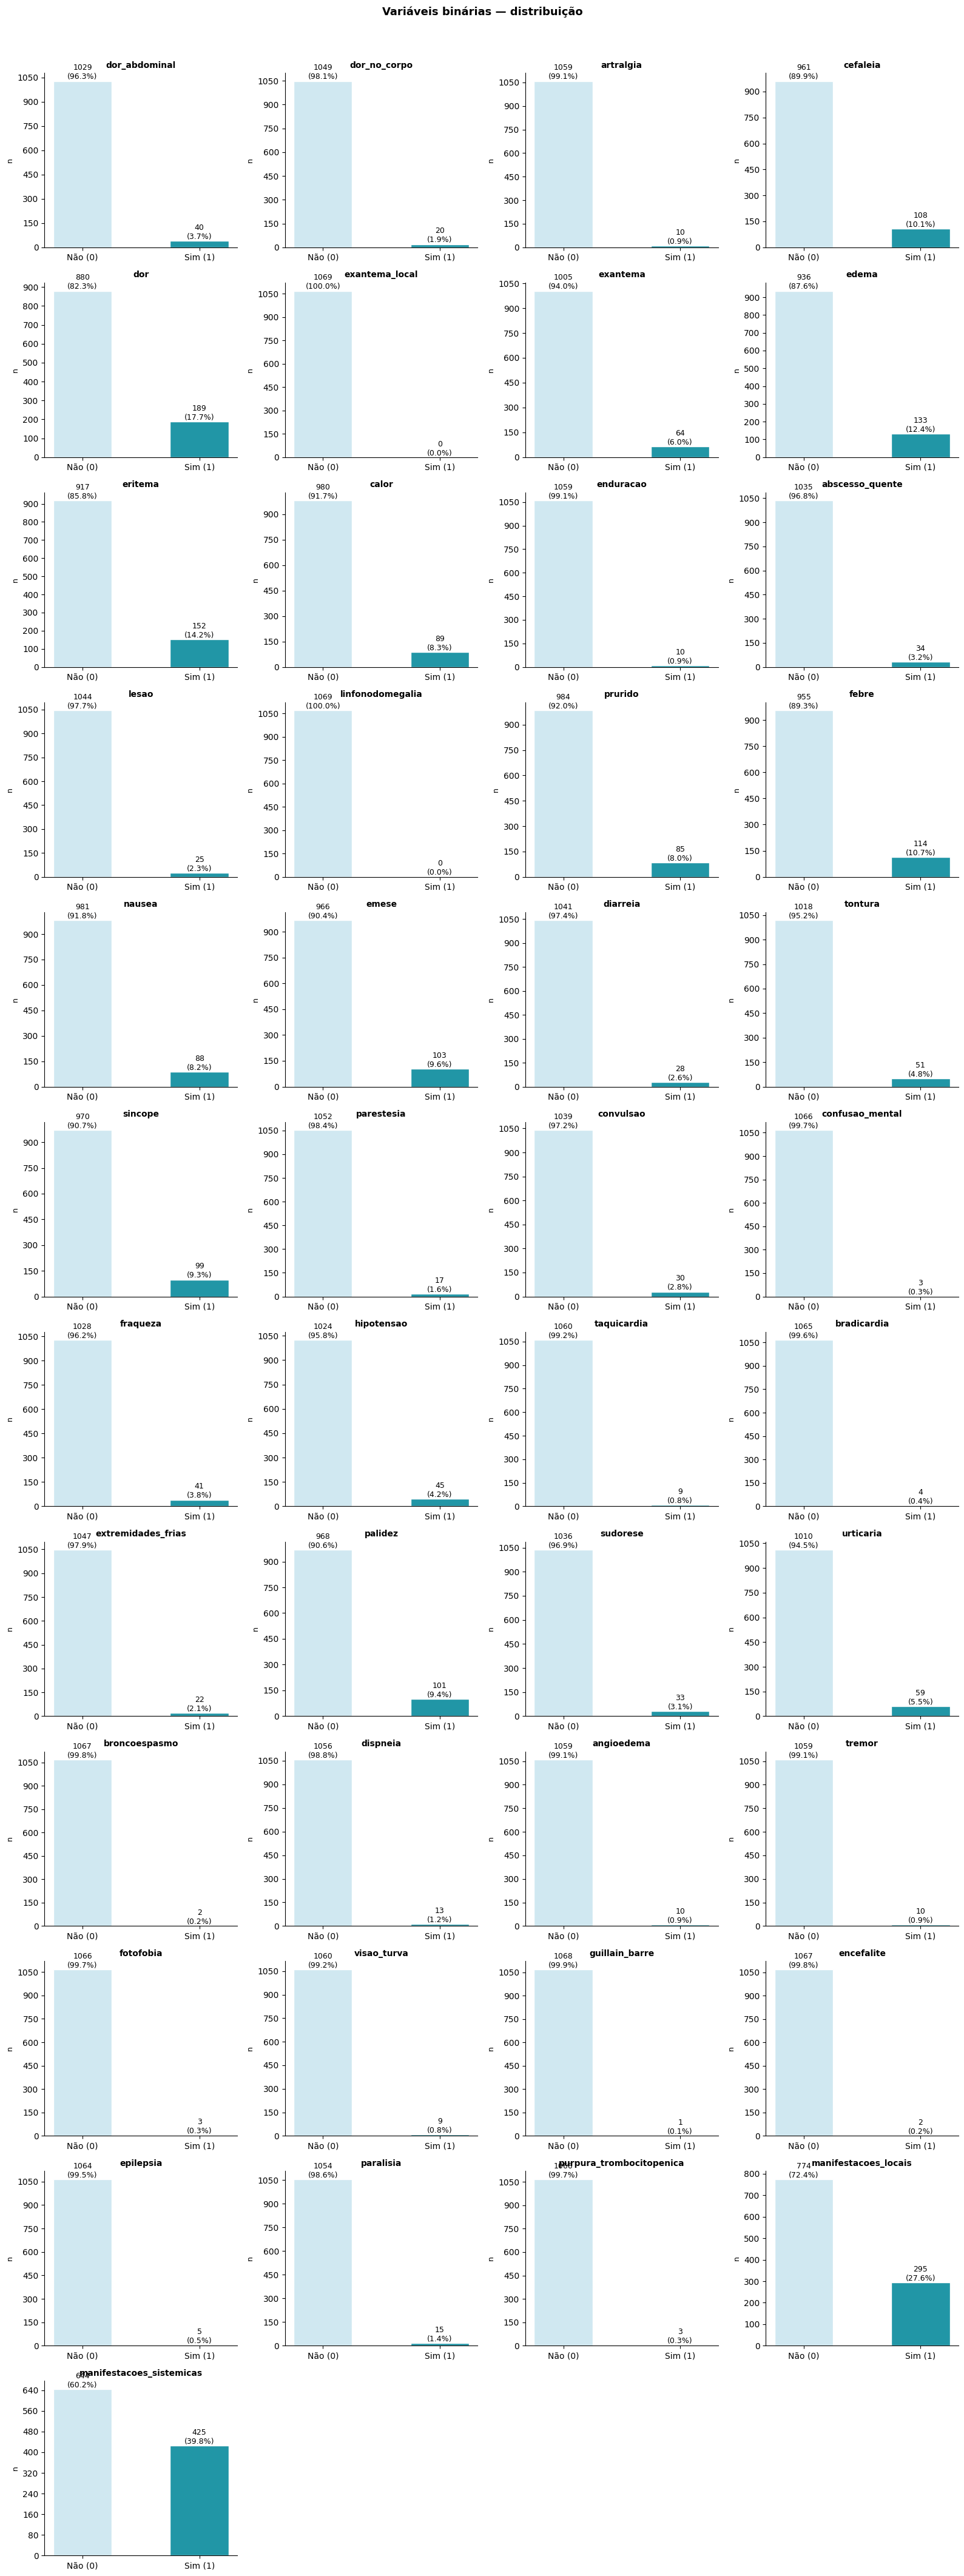

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

colunas_binarias = [
    'dor_abdominal', 'dor_no_corpo', 'artralgia', 'cefaleia', 'dor',
    'exantema_local', 'exantema', 'edema', 'eritema', 'calor', 'enduracao',
    'abscesso_quente', 'lesao', 'linfonodomegalia', 'prurido', 'febre',
    'nausea', 'emese', 'diarreia', 'tontura', 'sincope', 'parestesia',
    'convulsao', 'confusao_mental', 'fraqueza', 'hipotensao', 'taquicardia',
    'bradicardia', 'extremidades_frias', 'palidez', 'sudorese', 'urticaria',
    'broncoespasmo', 'dispneia', 'angioedema', 'tremor', 'fotofobia',
    'visao_turva', 'guillain_barre', 'encefalite', 'epilepsia', 'paralisia',
    'purpura_trombocitopenica', 'manifestacoes_locais', 'manifestacoes_sistemicas'
]

def plot_binaria(col, ax):
    contagem = dados_finais[col].value_counts().sort_index()
    cores = ['#d0e8f1', '#2196a6']
    bars = ax.bar(
        ['Não (0)', 'Sim (1)'],
        [contagem.get(0, 0), contagem.get(1, 0)],
        color=cores, edgecolor='white', width=0.5
    )
    for bar in bars:
        h = bar.get_height()
        pct = h / len(dados_finais) * 100
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5,
                f'{int(h)}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
    ax.set_title(col, fontsize=10, fontweight='bold', pad=6)
    ax.set_ylabel('n', fontsize=9)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.spines[['top', 'right']].set_visible(False)

# ── variáveis binárias ───────────────────────────────────────────────────────
n_bin = len(colunas_binarias)
ncols = 4
nrows = -(-n_bin // ncols)  # ceil

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(colunas_binarias):
    plot_binaria(col, axes[i])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Variáveis binárias — distribuição', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
#plt.savefig('graficos_binarias.png', dpi=150, bbox_inches='tight')
plt.show()

### **Variáveis Categóricas**

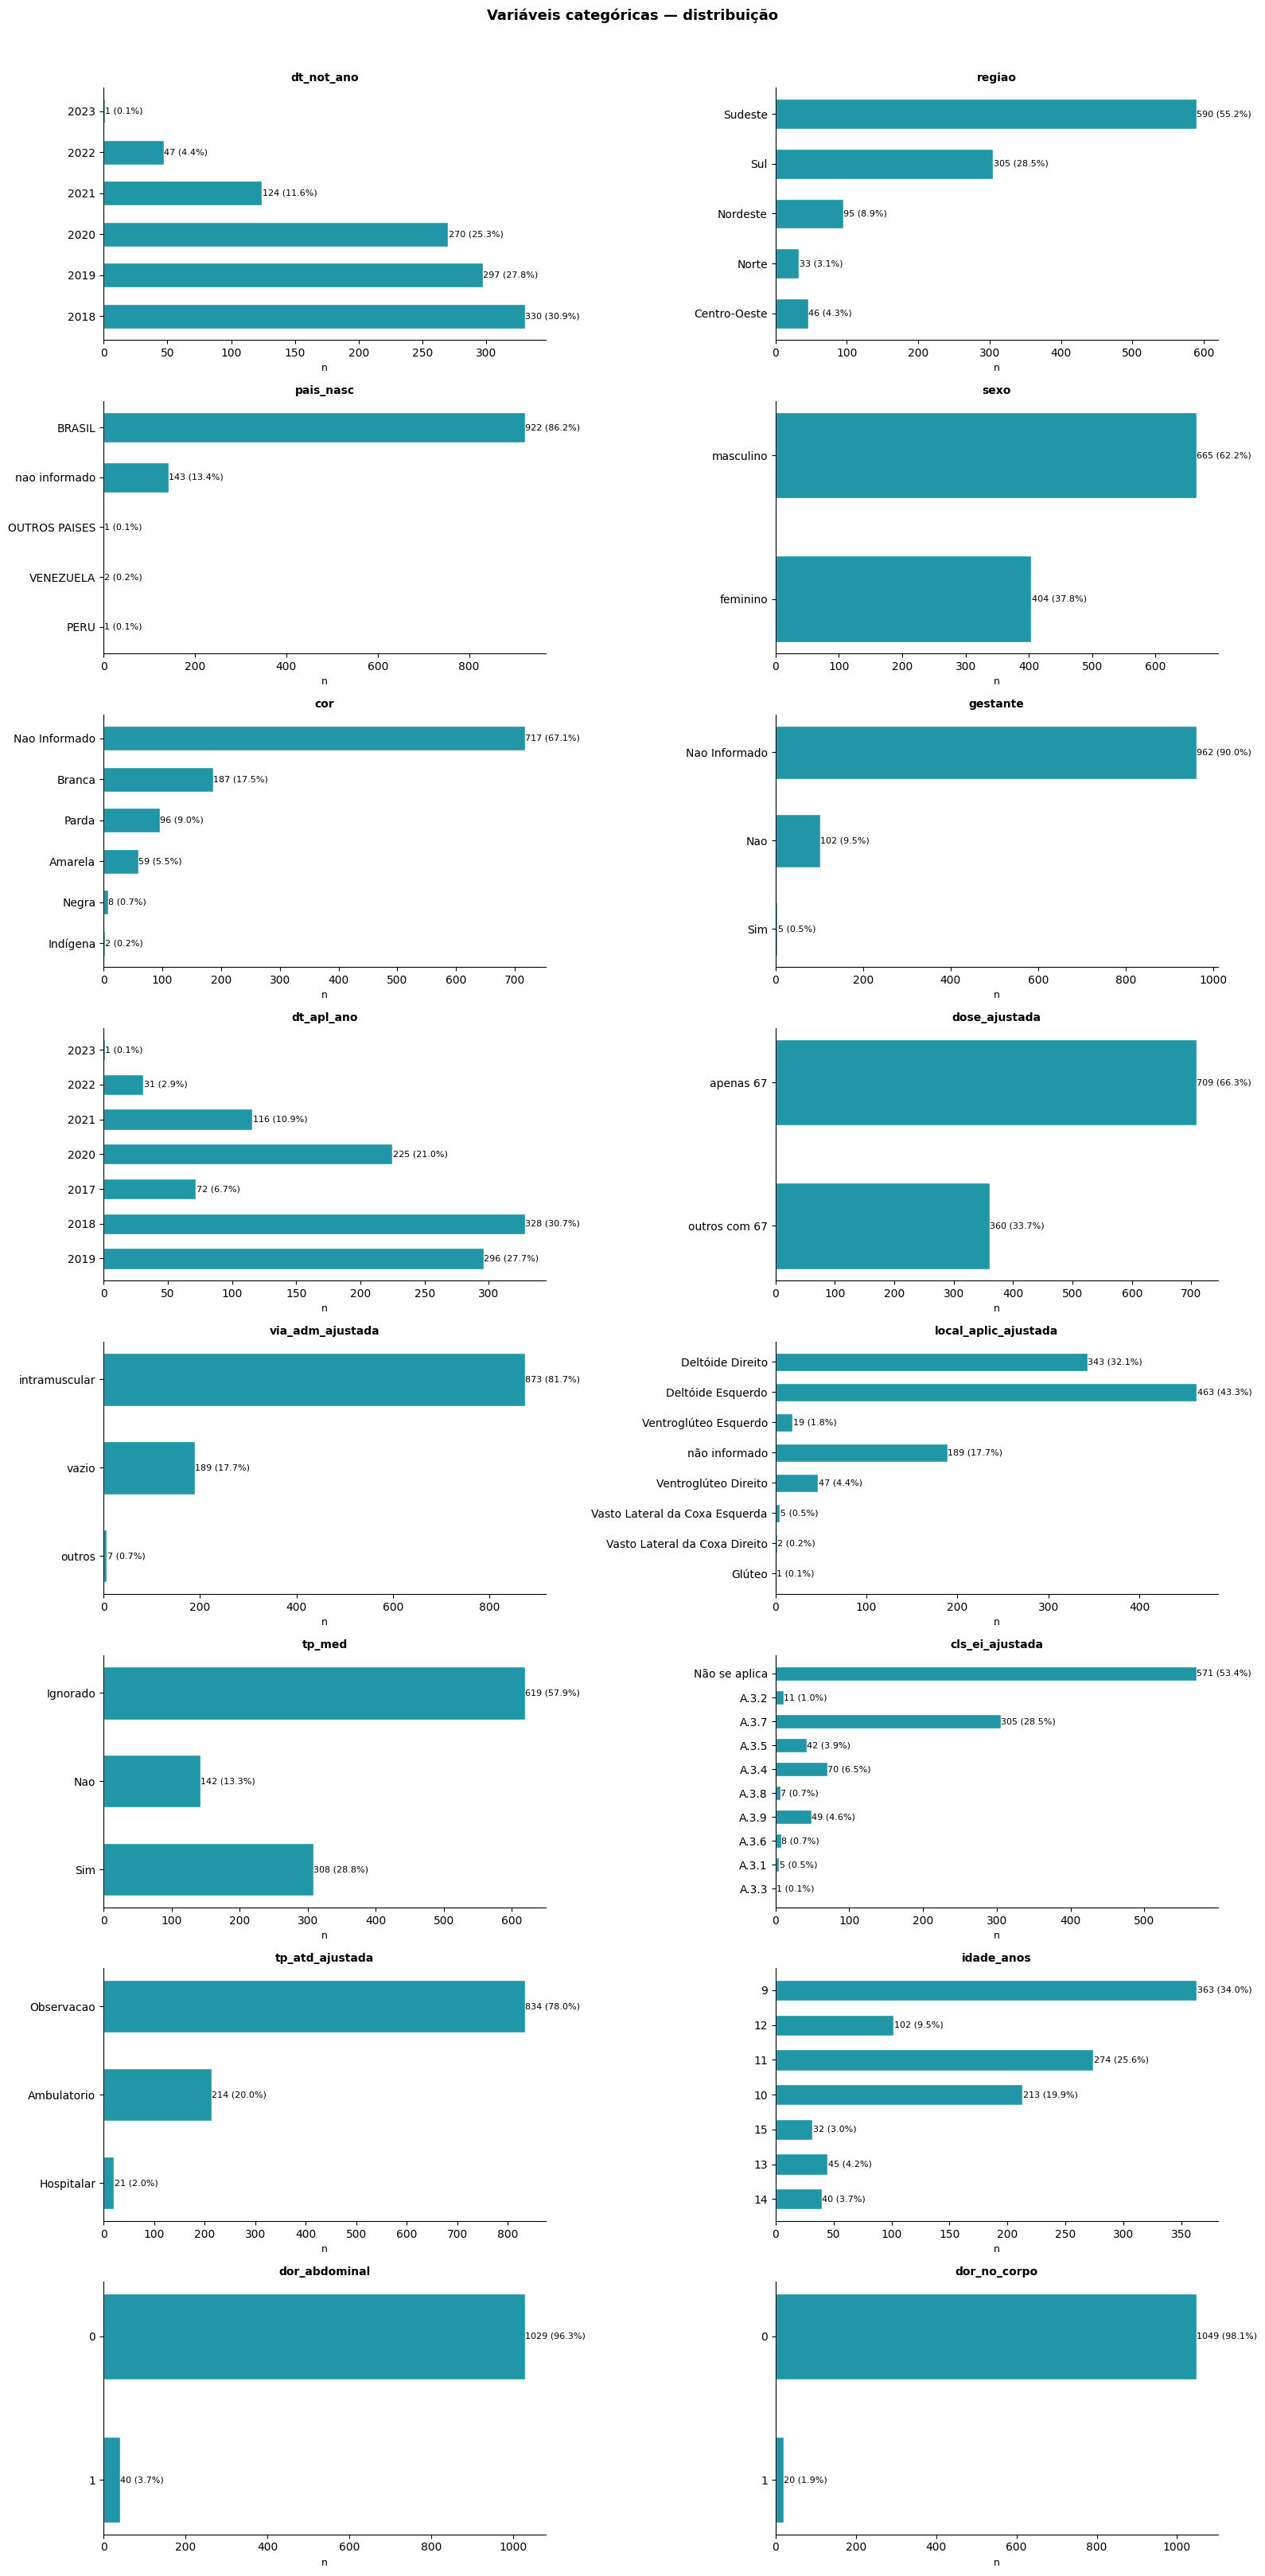

In [14]:
colunas_categoricas = ['dt_not_ano', 'regiao', 'pais_nasc', 'sexo', 'cor', 'gestante',
            'dt_apl_ano', 'dose_ajustada', 'via_adm_ajustada', 'local_aplic_ajustada',
            'tp_med', 'cls_ei_ajustada',  'tp_atd_ajustada', 
            'idade_anos','dor_abdominal', 'dor_no_corpo']


def plot_categorica(col, ax, max_cats=15):
    # Mantém a ordem original das categorias (não por frequência)
    unique_vals = dados_finais[col].dropna().unique()
    if len(unique_vals) > max_cats:
        unique_vals = unique_vals[:max_cats]
    contagem = dados_finais[col].value_counts().reindex(unique_vals)
    bars = ax.barh(
        contagem.index.astype(str)[::-1],
        contagem.values[::-1],
        color='#2196a6', edgecolor='white', height=0.6
    )
    for bar in bars:
        w = bar.get_width()
        pct = w / len(dados_finais) * 100
        ax.text(w + 0.3, bar.get_y() + bar.get_height() / 2,
                f'{int(w)} ({pct:.1f}%)', va='center', fontsize=8)
    ax.set_title(col, fontsize=10, fontweight='bold', pad=6)
    ax.set_xlabel('n', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)


# ── variáveis categóricas ────────────────────────────────────────────────────
n_cat = len(colunas_categoricas)
nrows_cat = -(-n_cat // 2)

fig2, axes2 = plt.subplots(nrows_cat, 2, figsize=(16, nrows_cat * 4))
axes2 = axes2.flatten()

for i, col in enumerate(colunas_categoricas):
    plot_categorica(col, axes2[i])

for j in range(i + 1, len(axes2)):
    axes2[j].set_visible(False)

fig2.suptitle('Variáveis categóricas — distribuição', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('graficos_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()


Gerando gráficos para: dt_not_ano vs cls_fin_ajustada


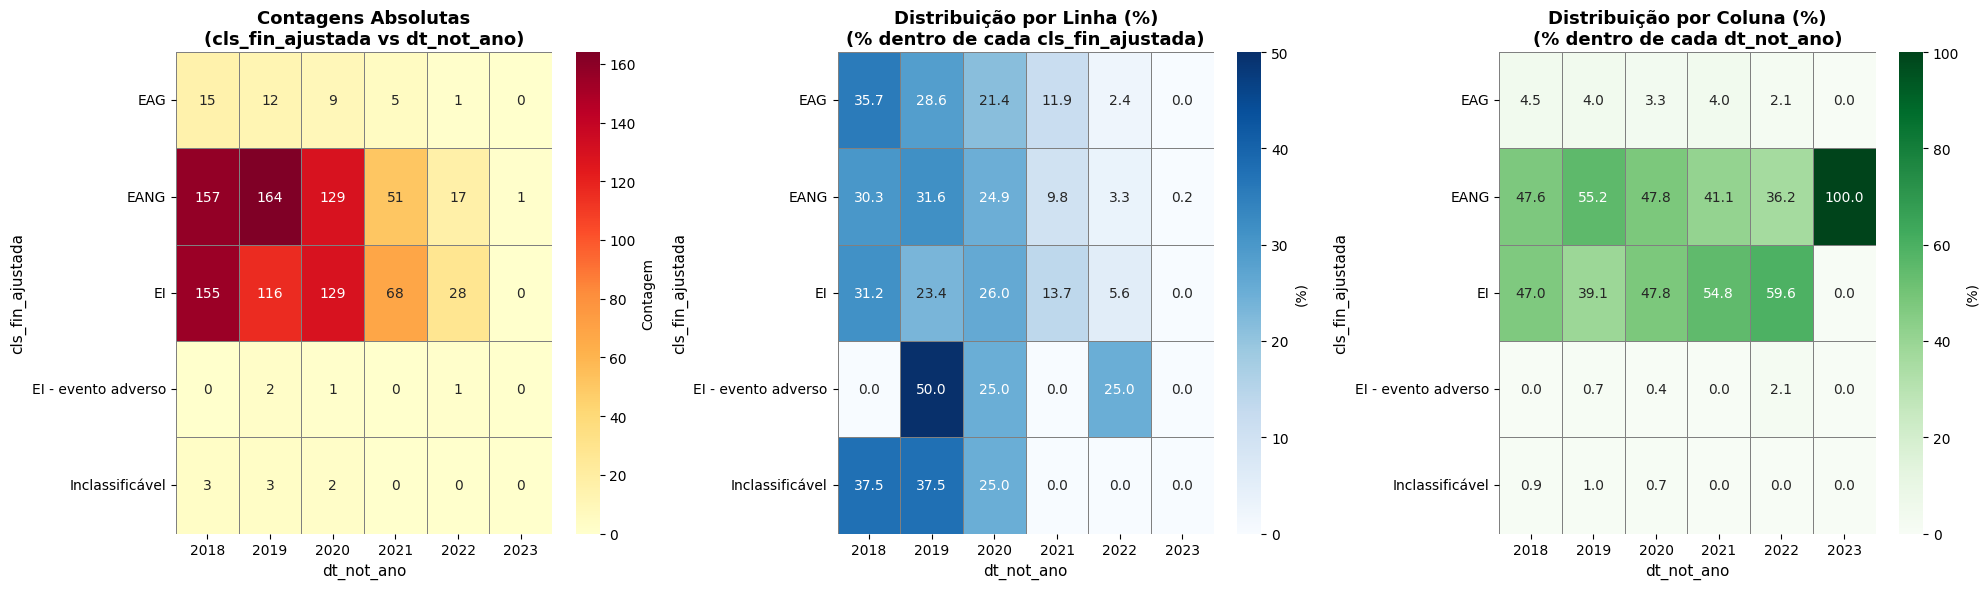


Gerando gráficos para: regiao vs cls_fin_ajustada


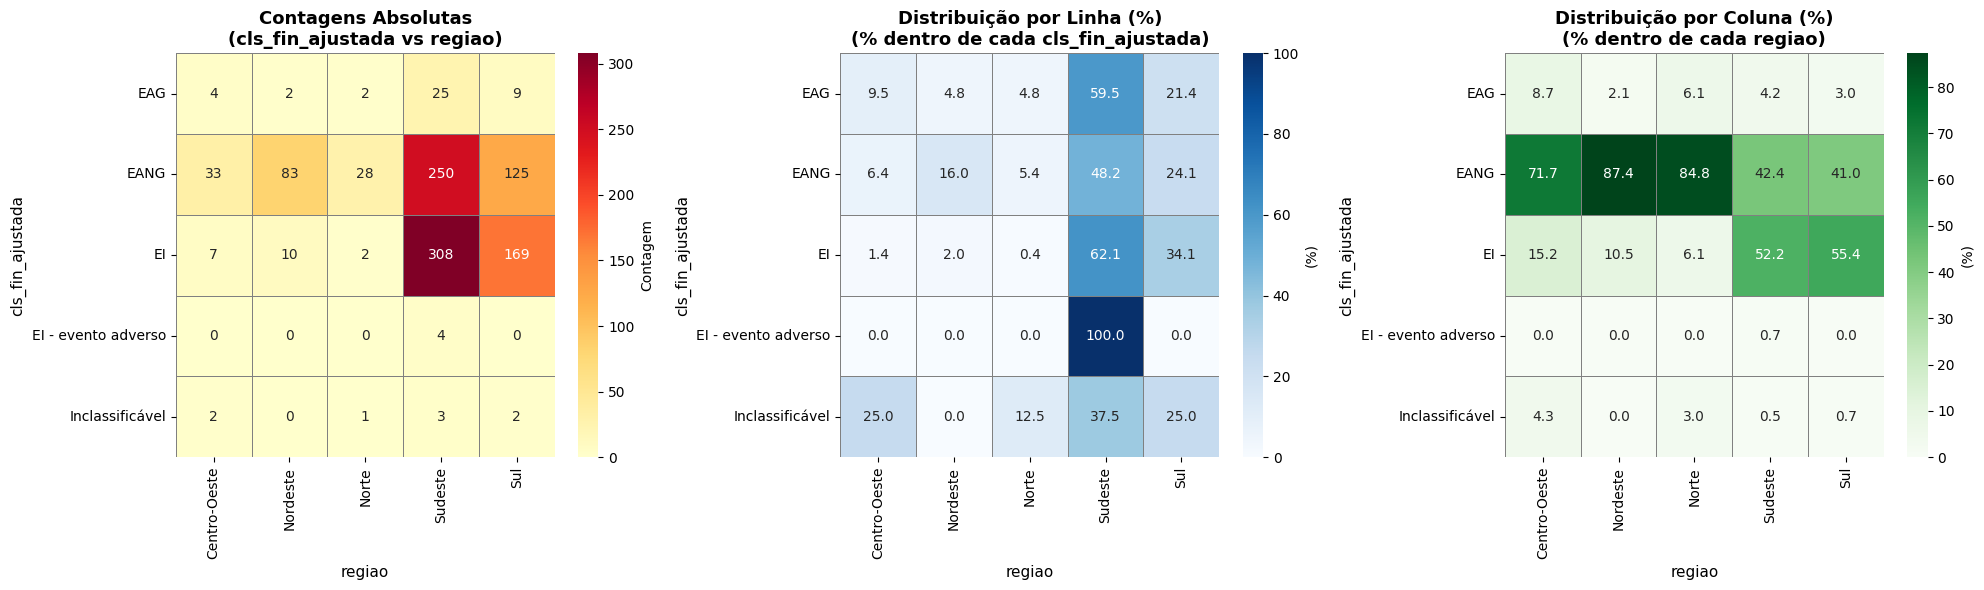


Gerando gráficos para: pais_nasc vs cls_fin_ajustada


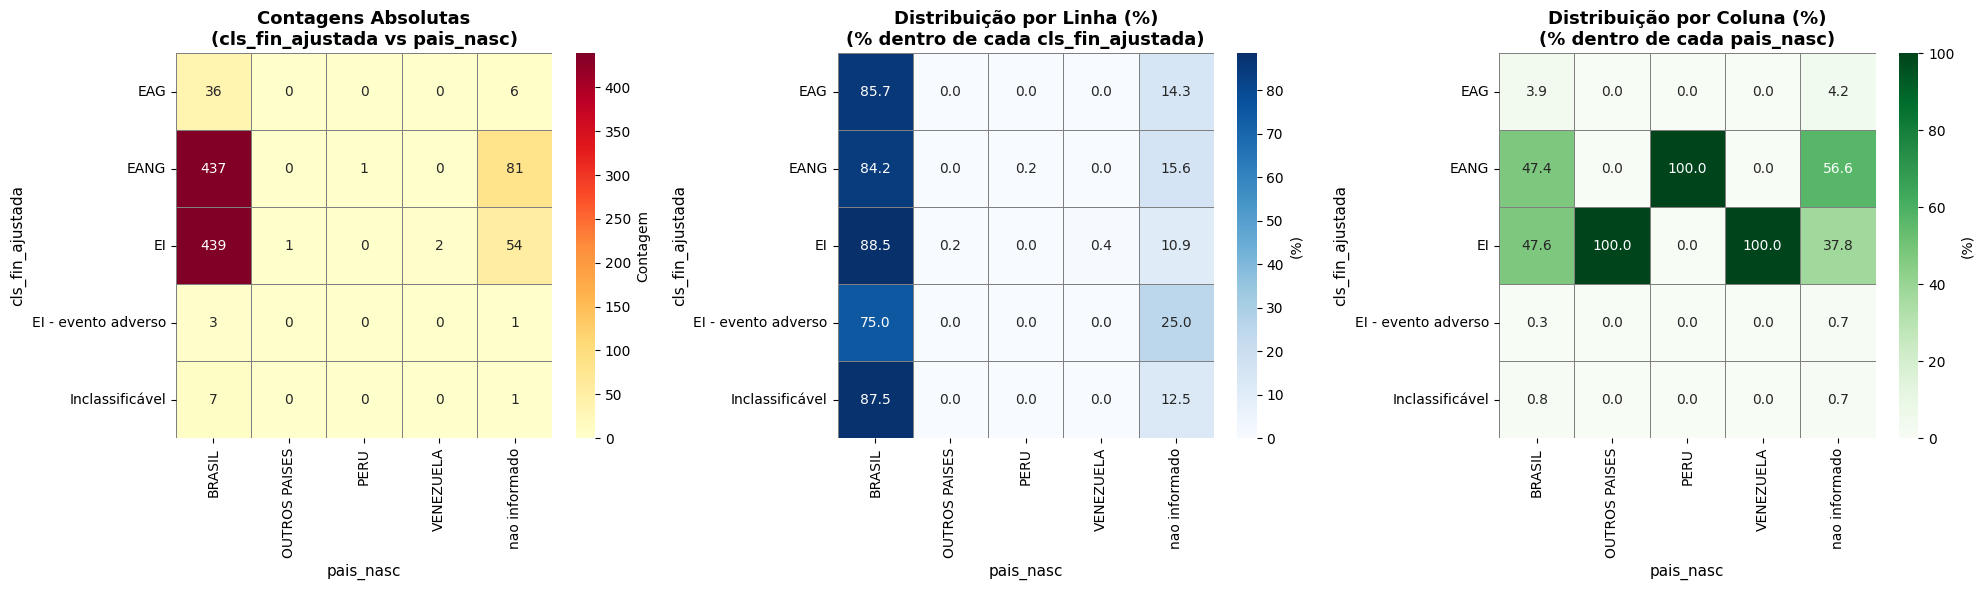


Gerando gráficos para: sexo vs cls_fin_ajustada


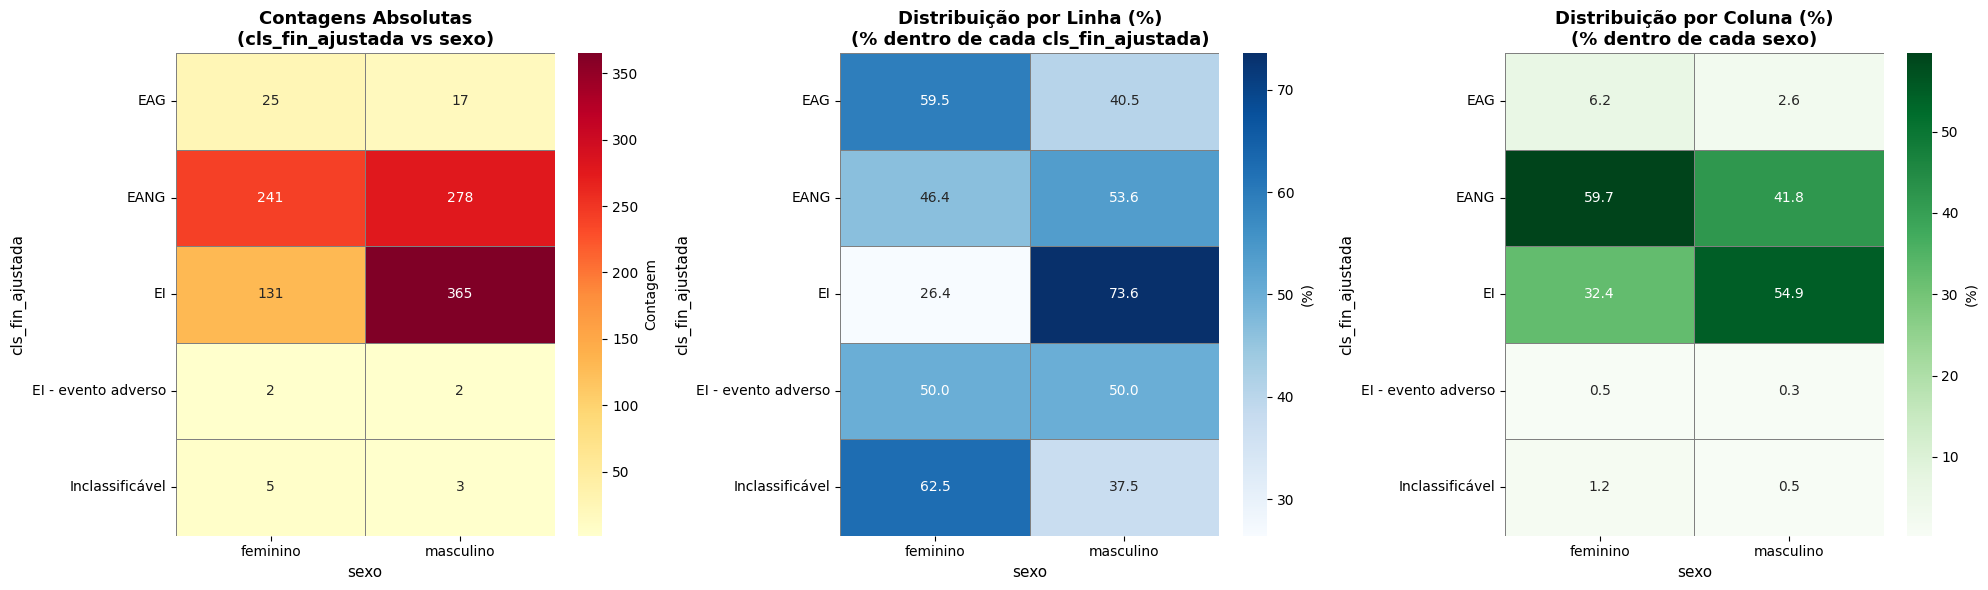


Gerando gráficos para: cor vs cls_fin_ajustada


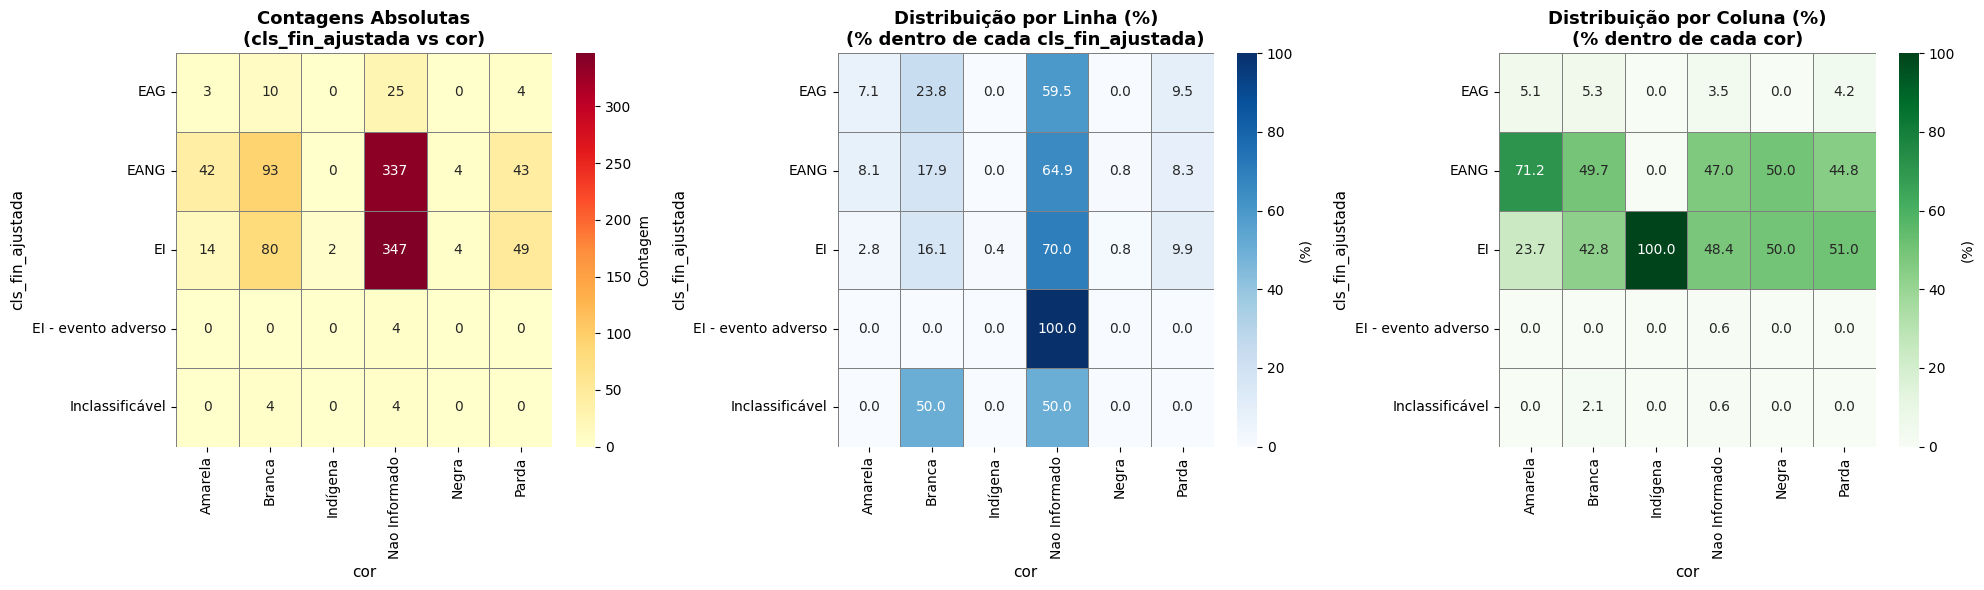


Gerando gráficos para: gestante vs cls_fin_ajustada


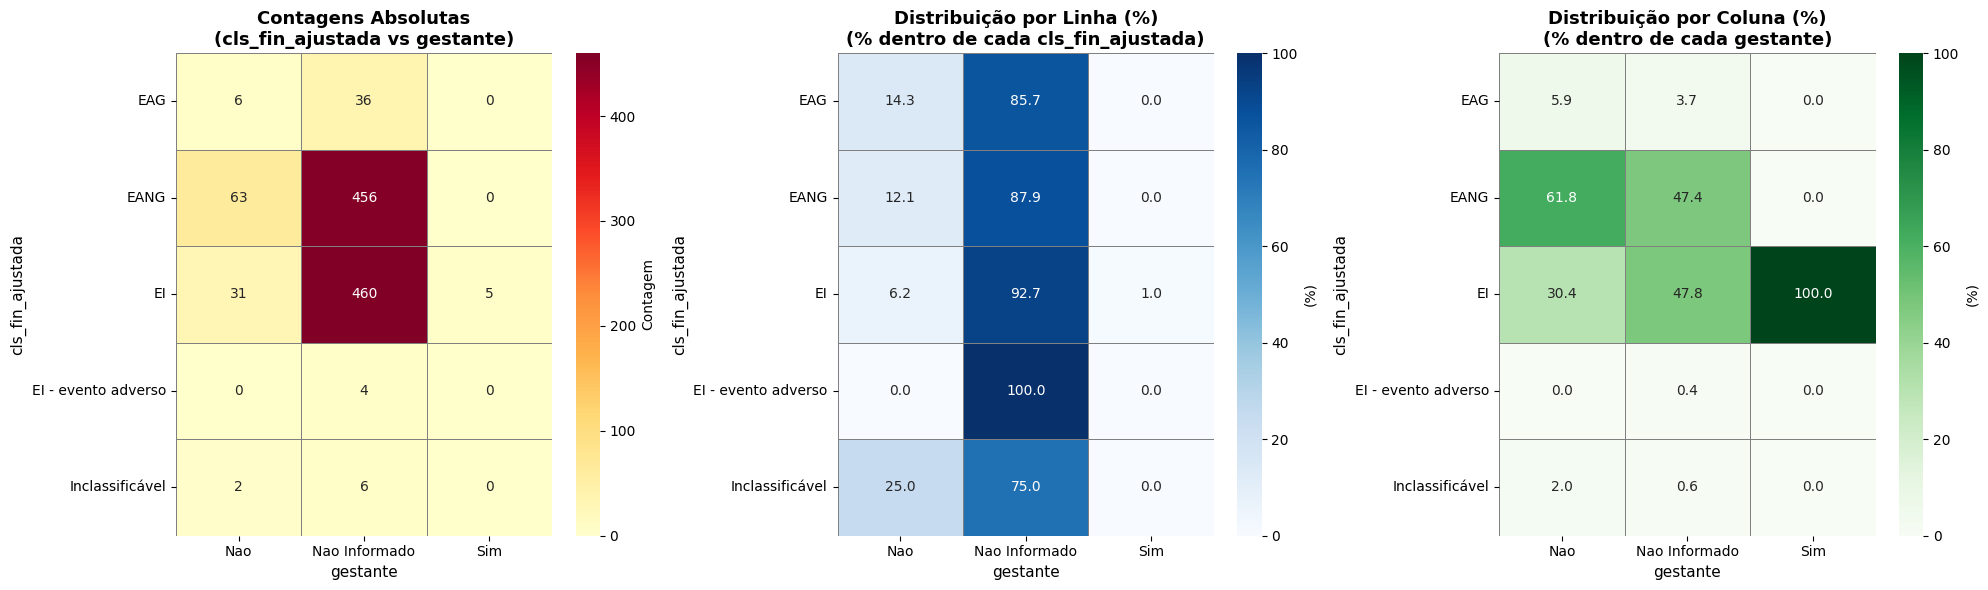


Gerando gráficos para: dt_apl_ano vs cls_fin_ajustada


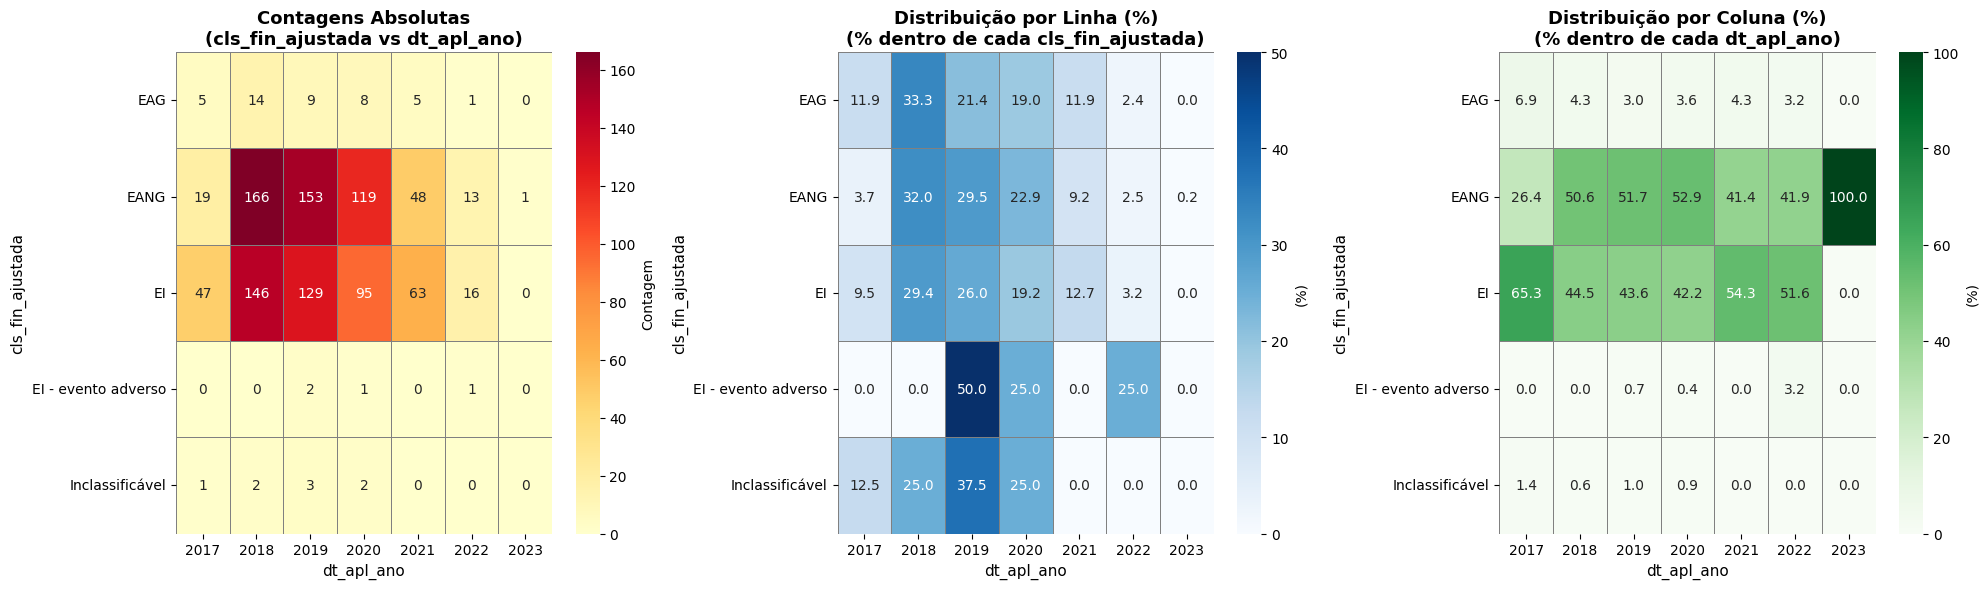


Gerando gráficos para: dose_ajustada vs cls_fin_ajustada


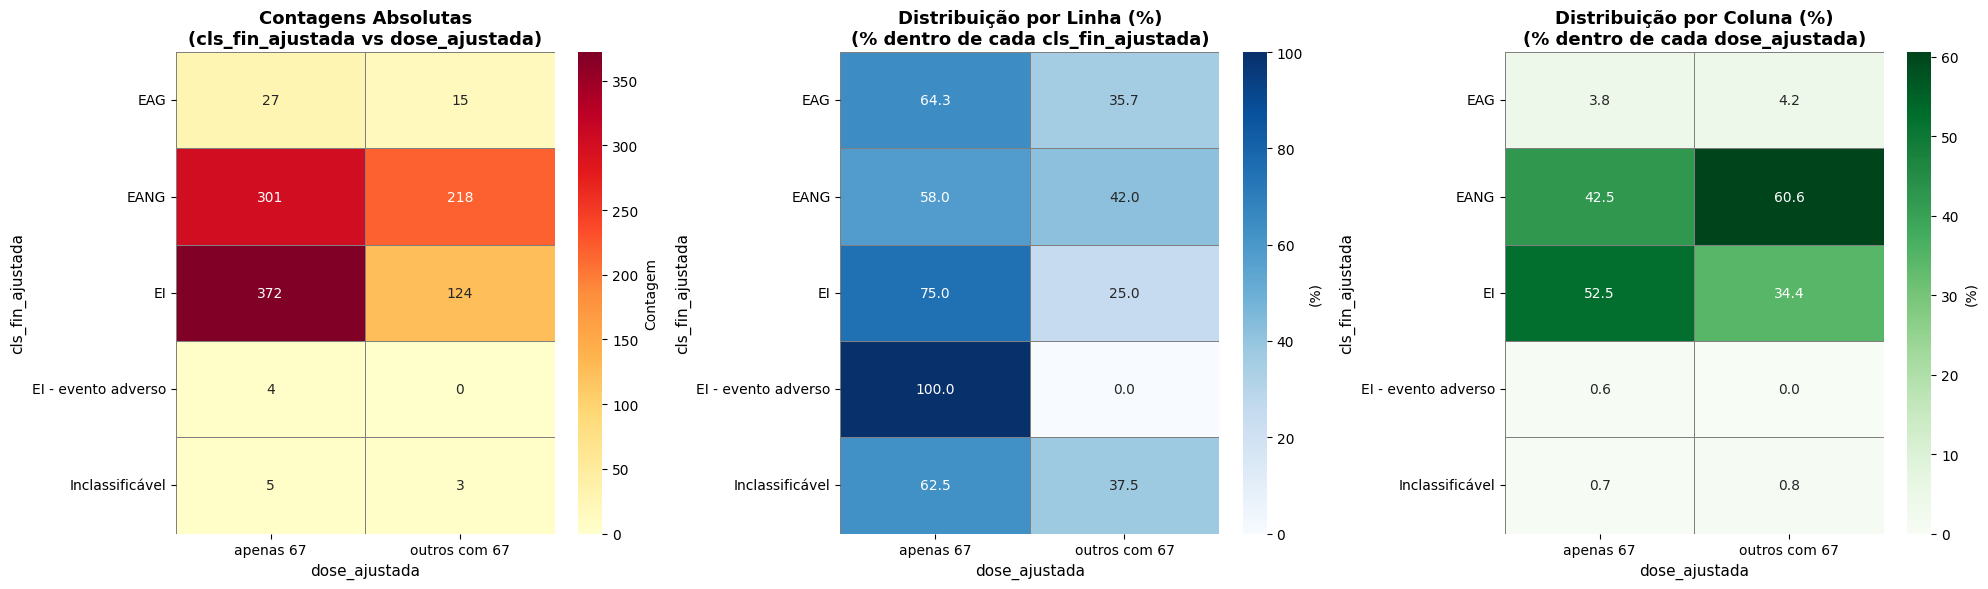


Gerando gráficos para: via_adm_ajustada vs cls_fin_ajustada


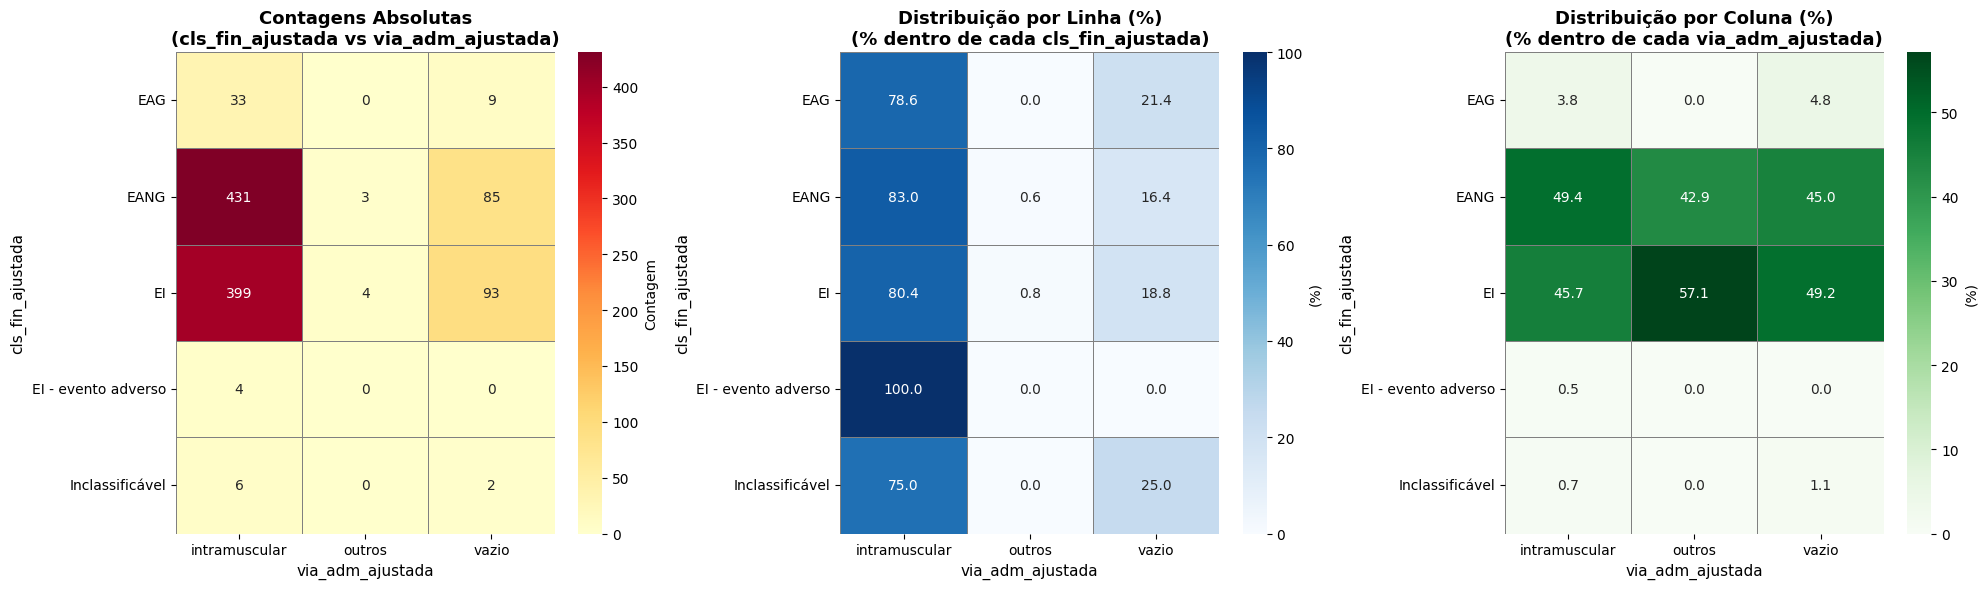


Gerando gráficos para: local_aplic_ajustada vs cls_fin_ajustada


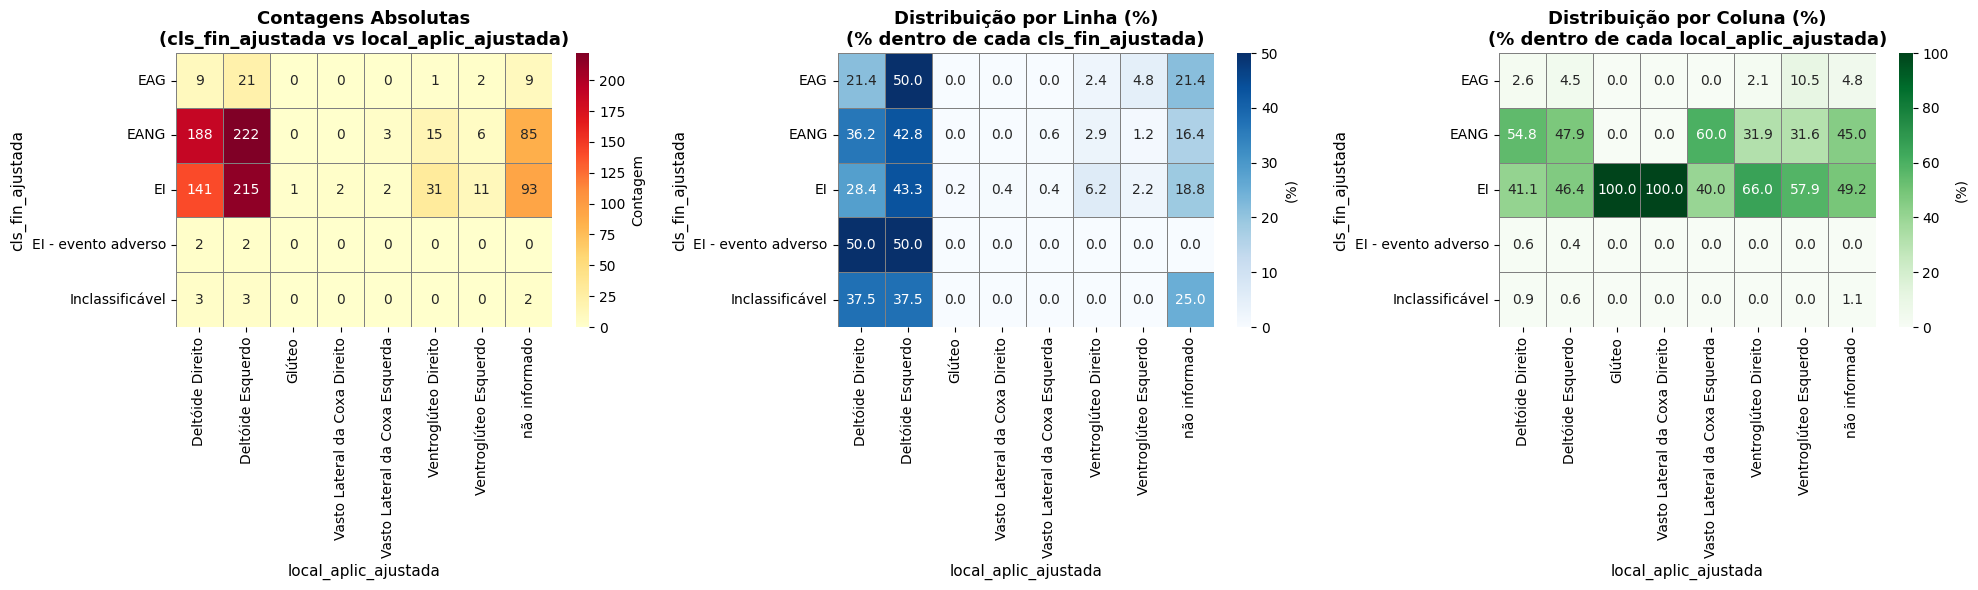


Gerando gráficos para: tp_med vs cls_fin_ajustada


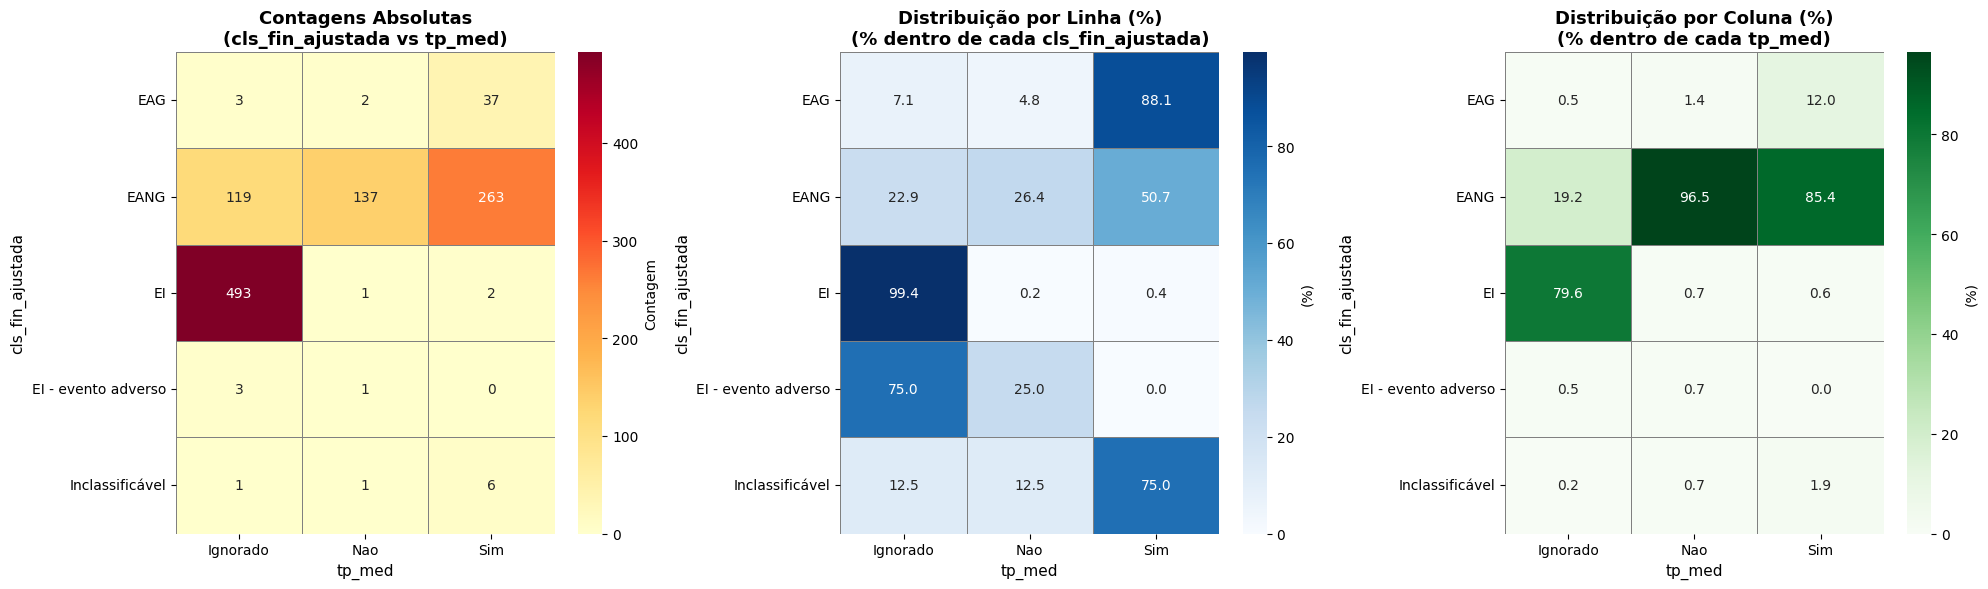


Gerando gráficos para: cls_ei_ajustada vs cls_fin_ajustada


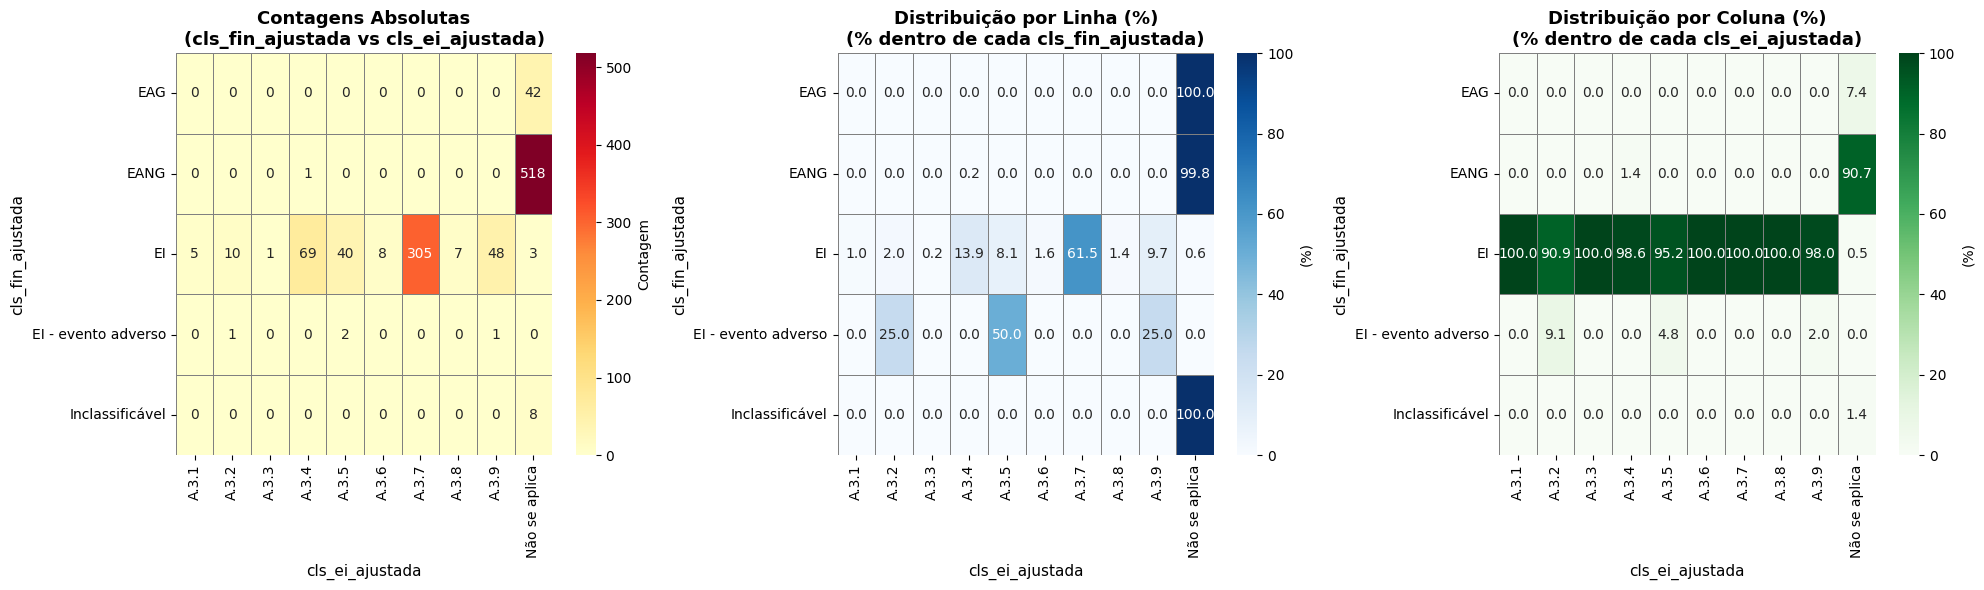


Gerando gráficos para: tp_atd_ajustada vs cls_fin_ajustada


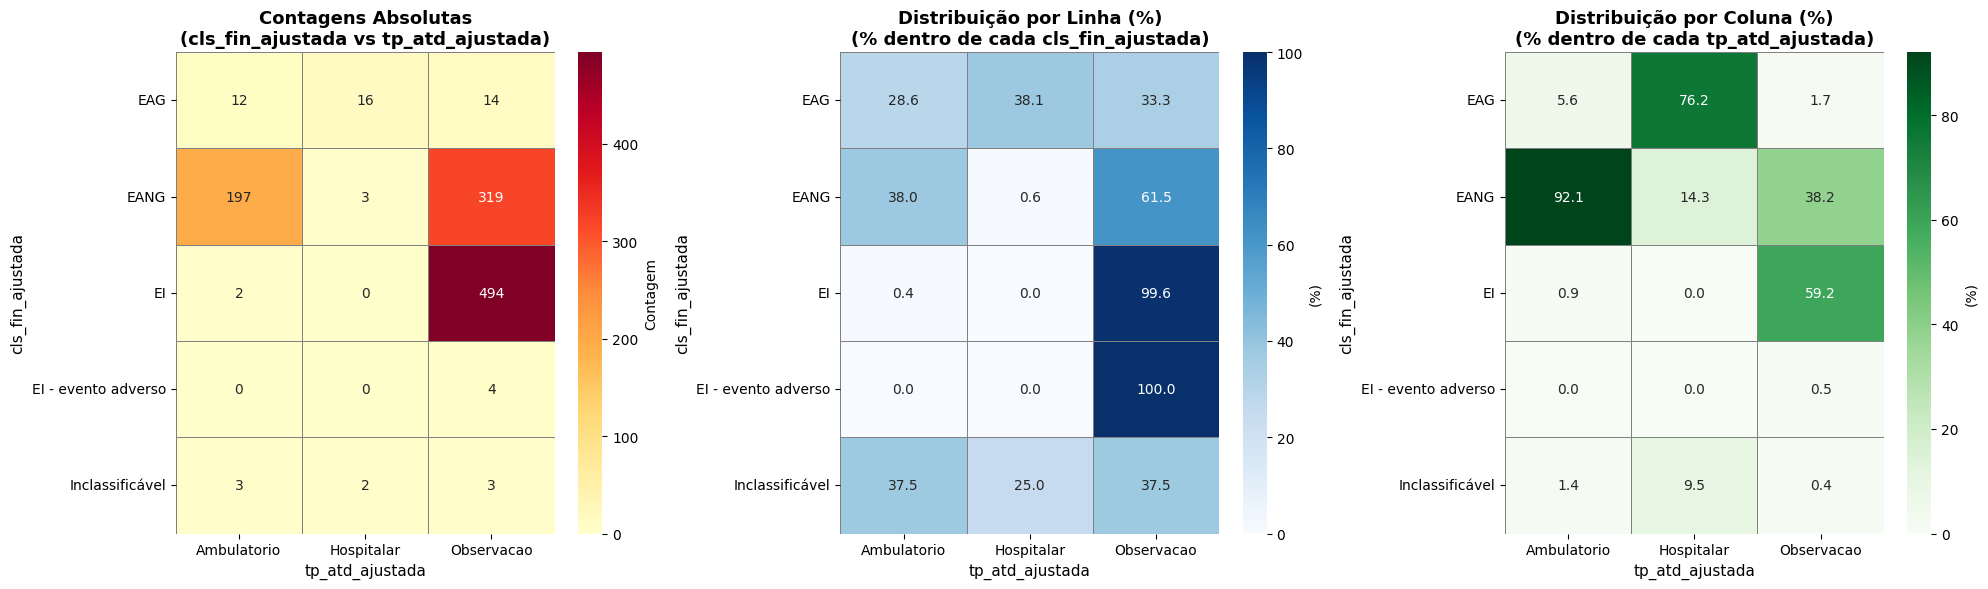


Gerando gráficos para: idade_anos vs cls_fin_ajustada


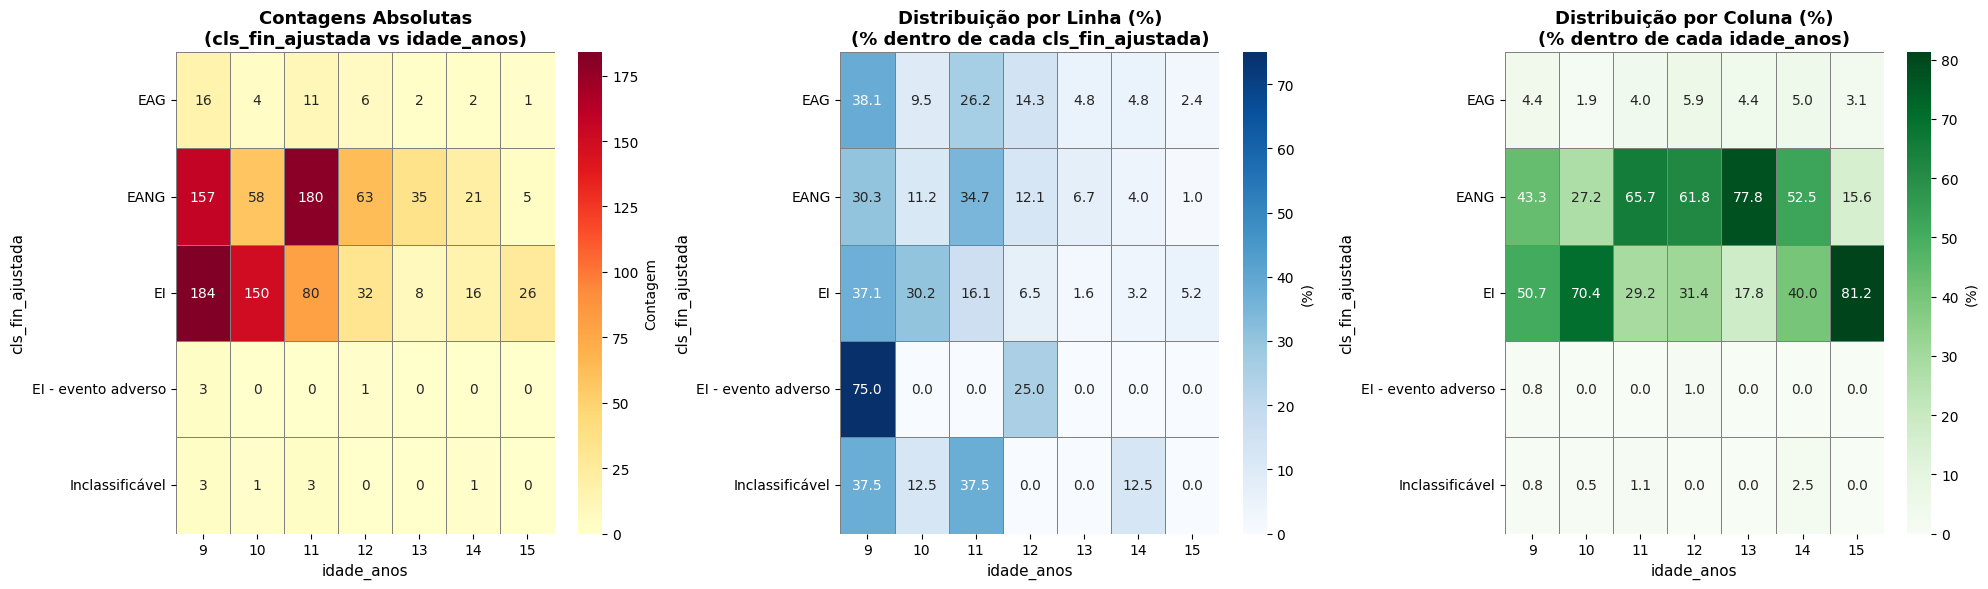


Gerando gráficos para: dor_abdominal vs cls_fin_ajustada


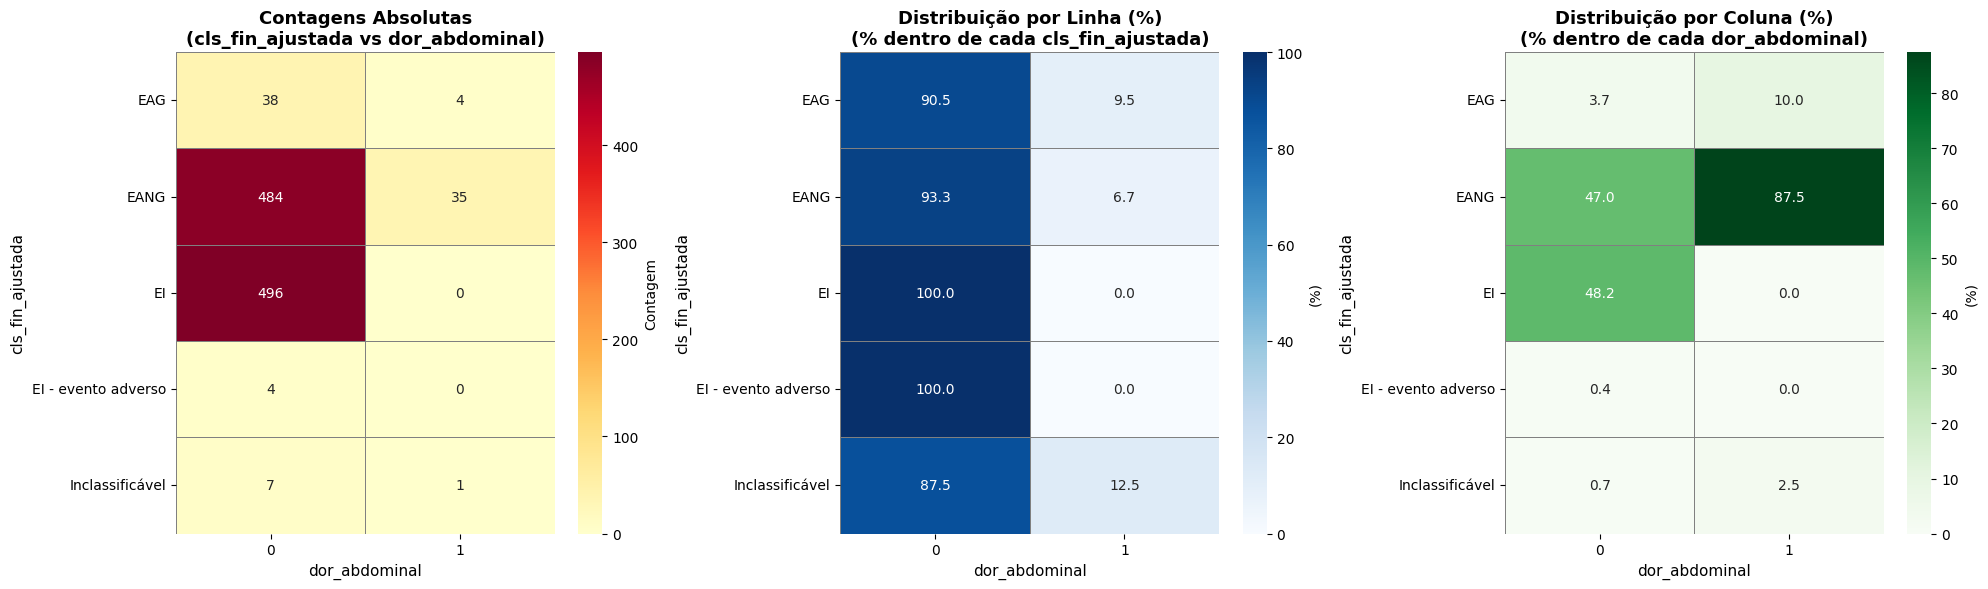


Gerando gráficos para: dor_no_corpo vs cls_fin_ajustada


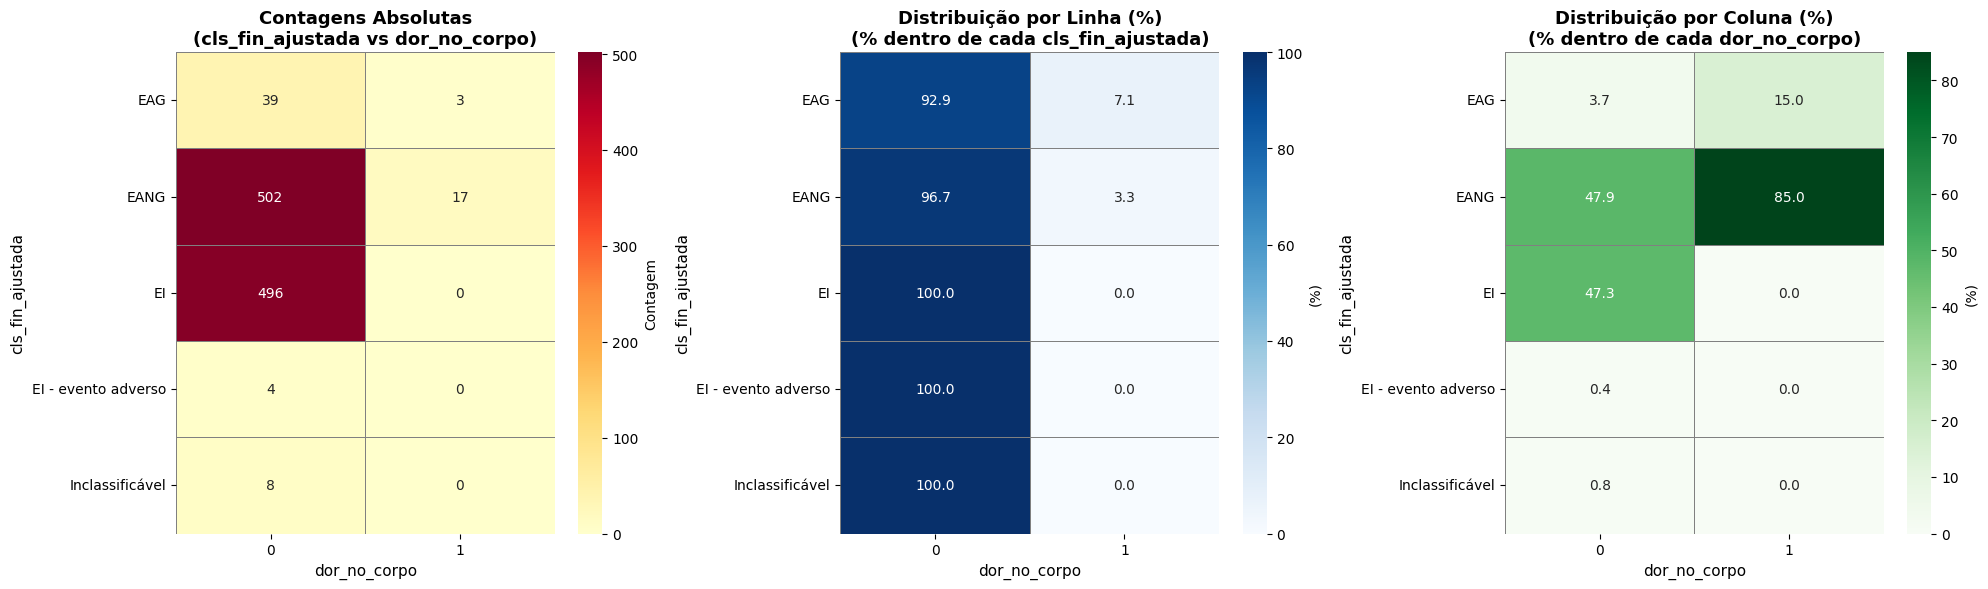


Gerando gráficos para: artralgia vs cls_fin_ajustada


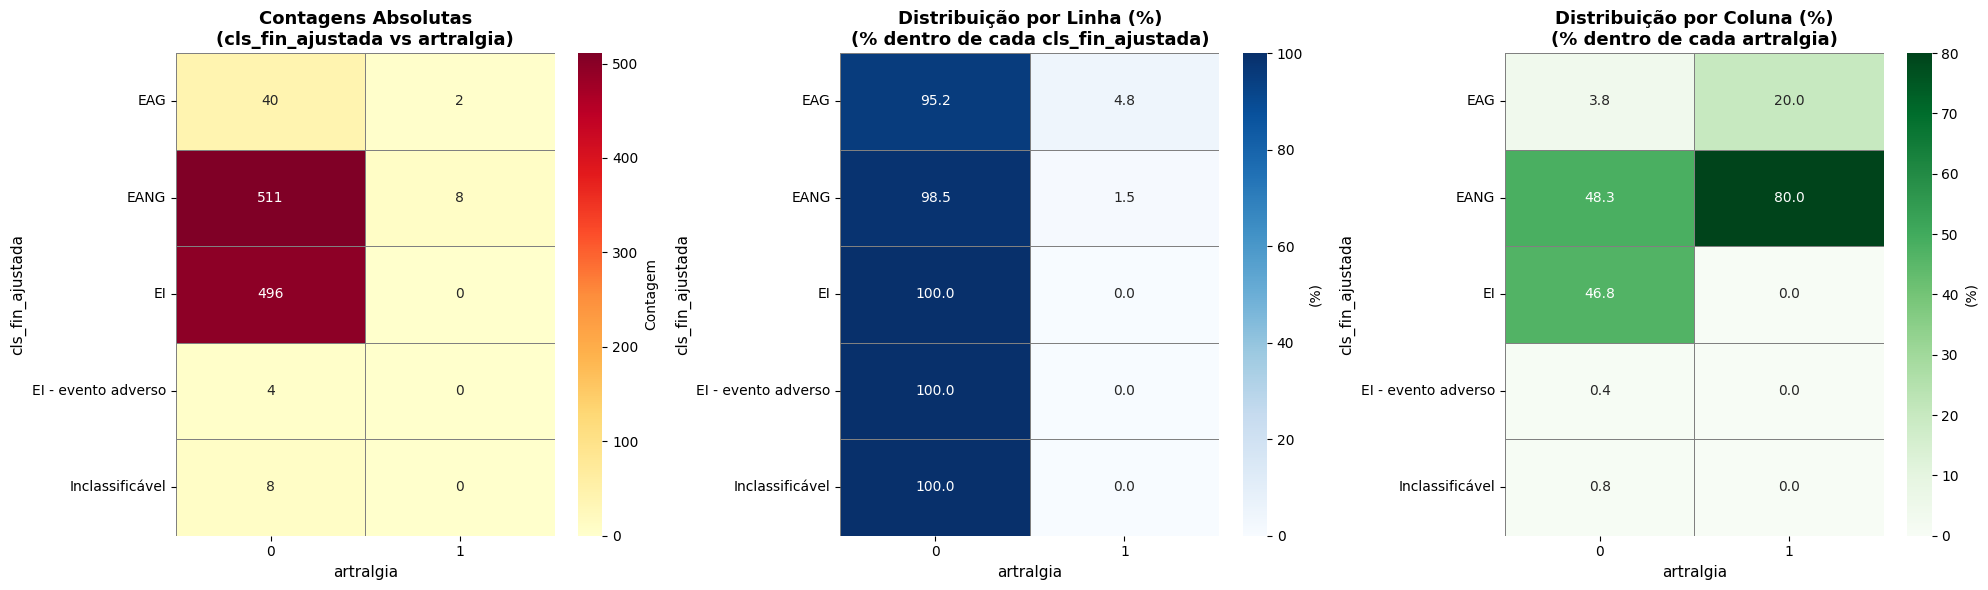


Gerando gráficos para: cefaleia vs cls_fin_ajustada


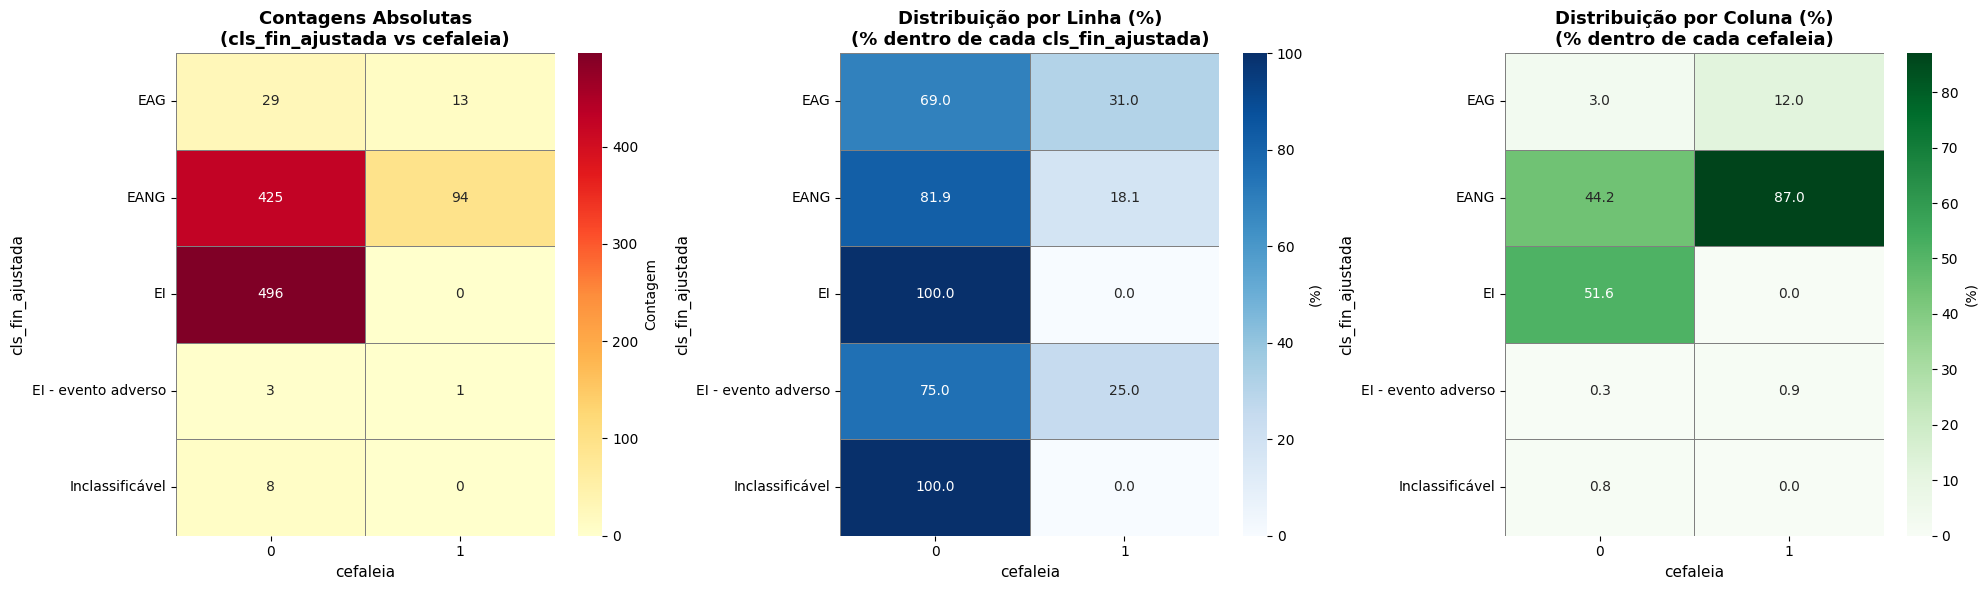


Gerando gráficos para: dor vs cls_fin_ajustada


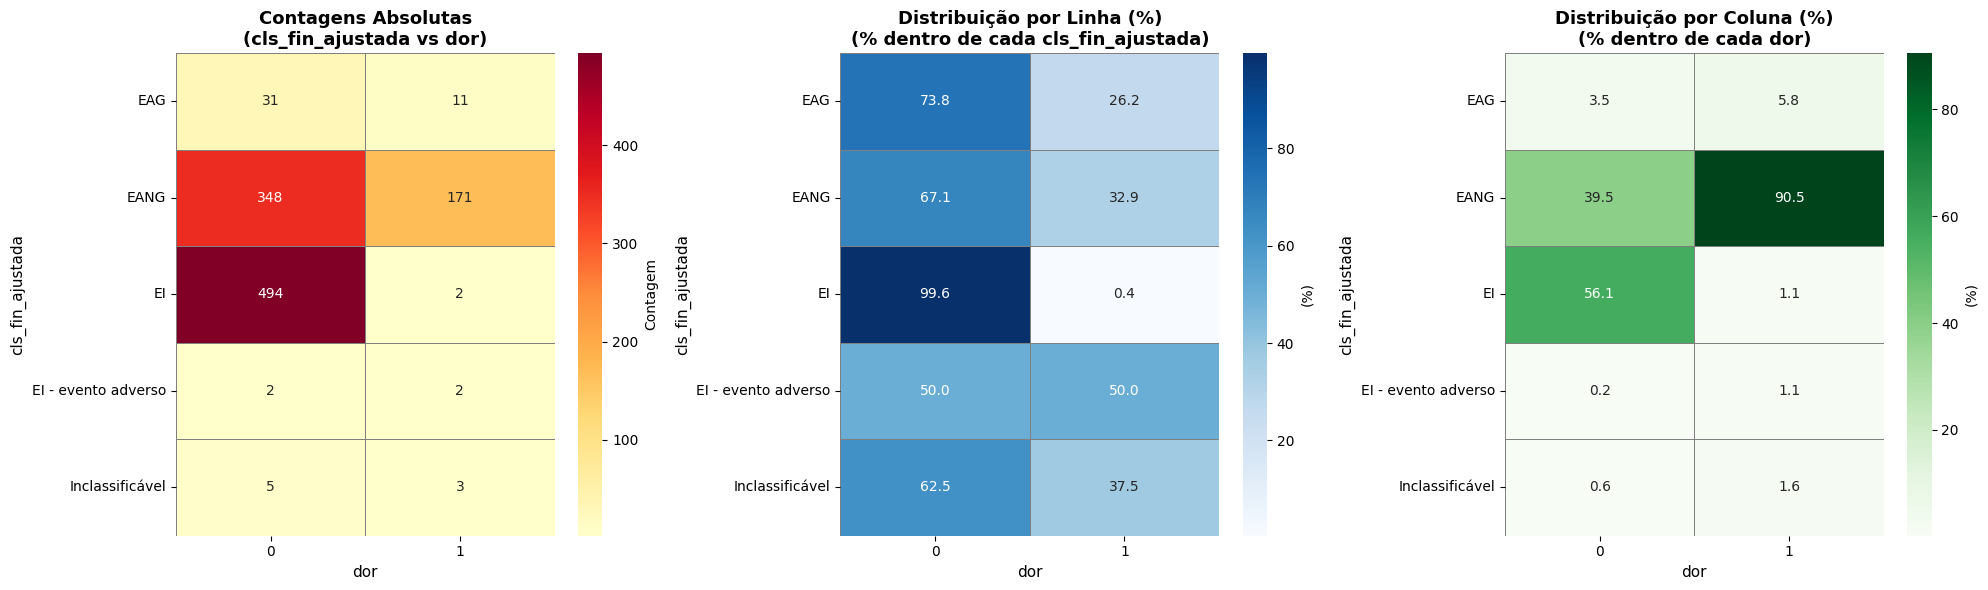


Gerando gráficos para: exantema_local vs cls_fin_ajustada


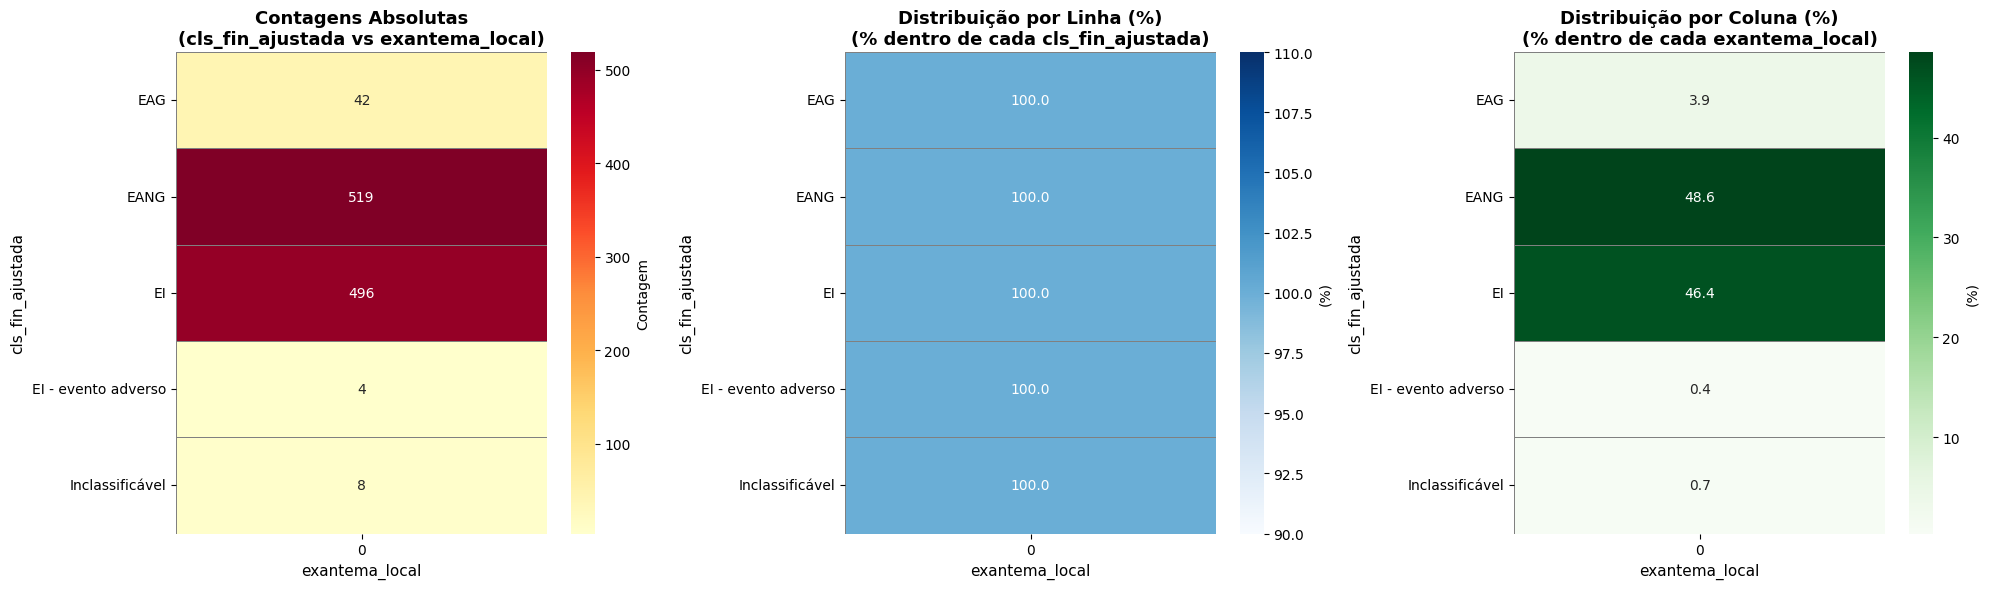


Gerando gráficos para: exantema vs cls_fin_ajustada


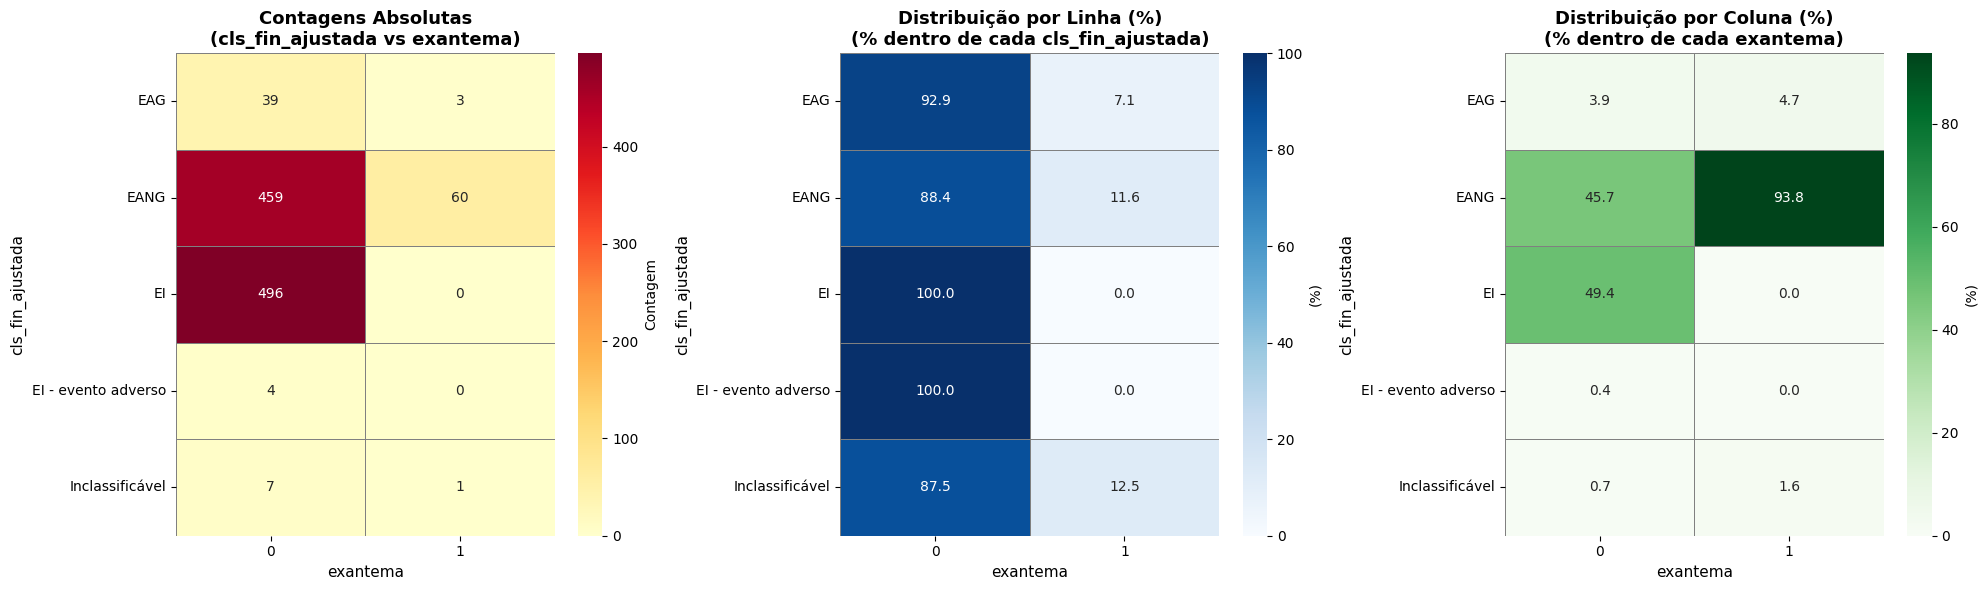


Gerando gráficos para: edema vs cls_fin_ajustada


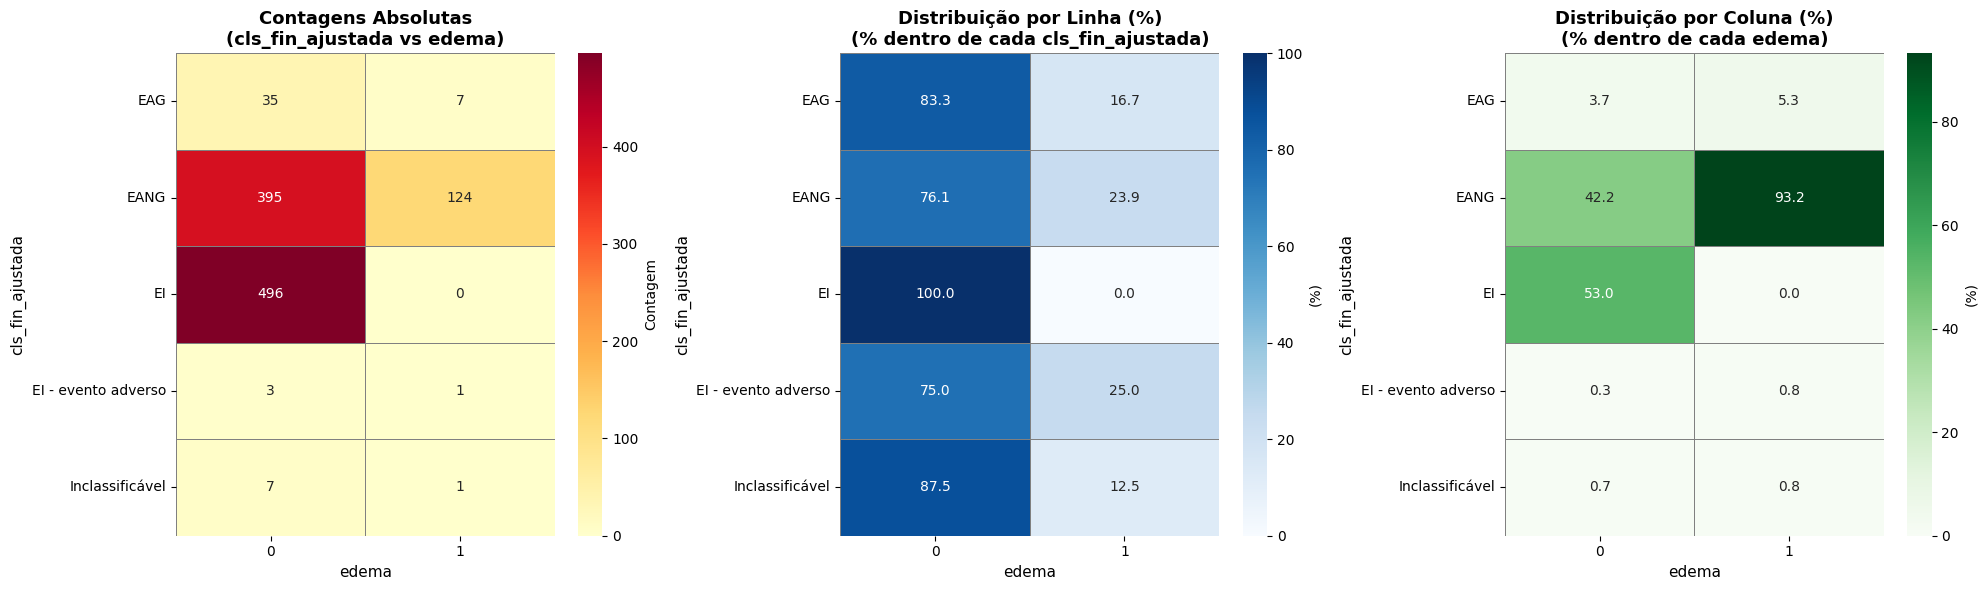


Gerando gráficos para: eritema vs cls_fin_ajustada


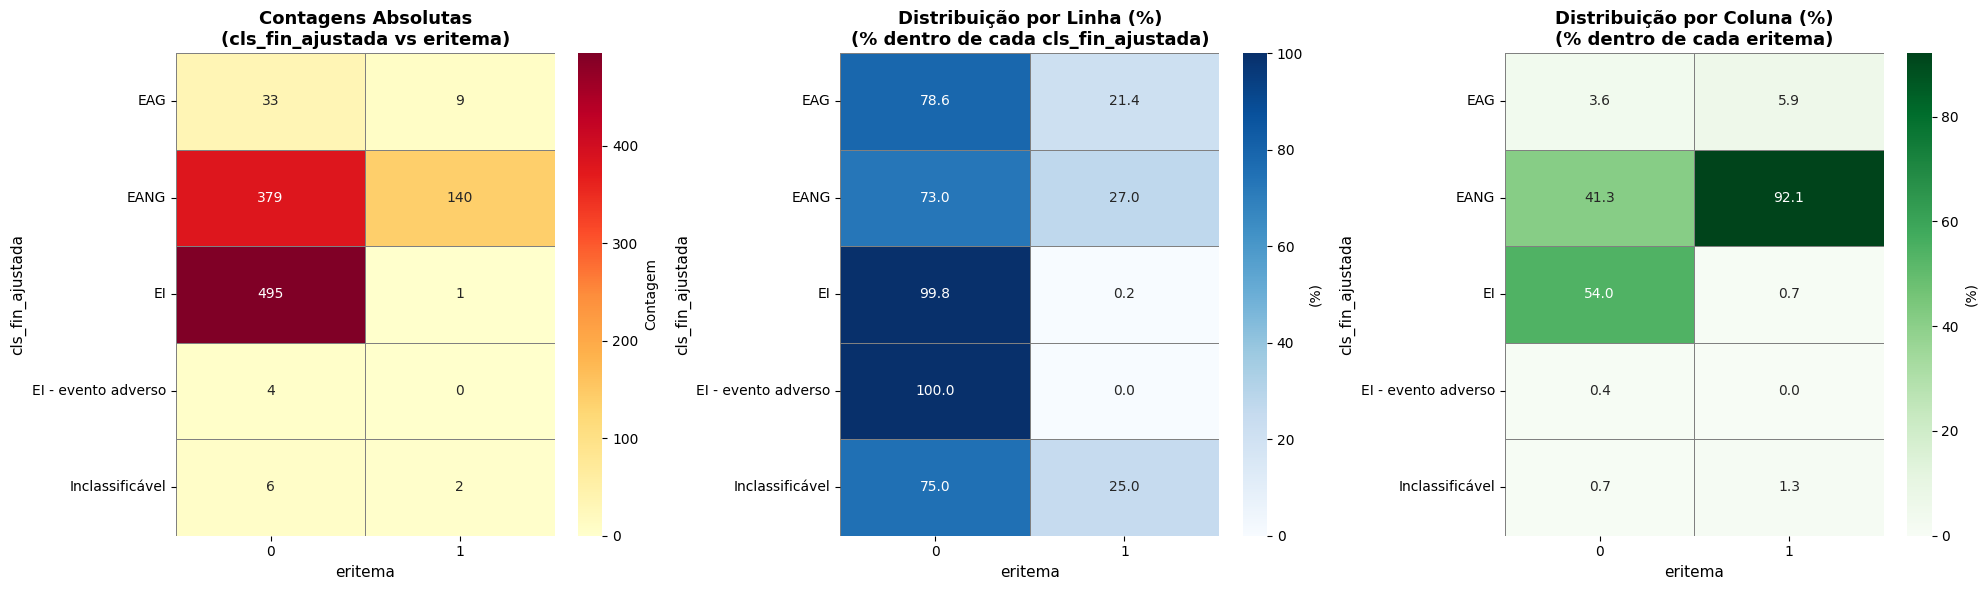


Gerando gráficos para: calor vs cls_fin_ajustada


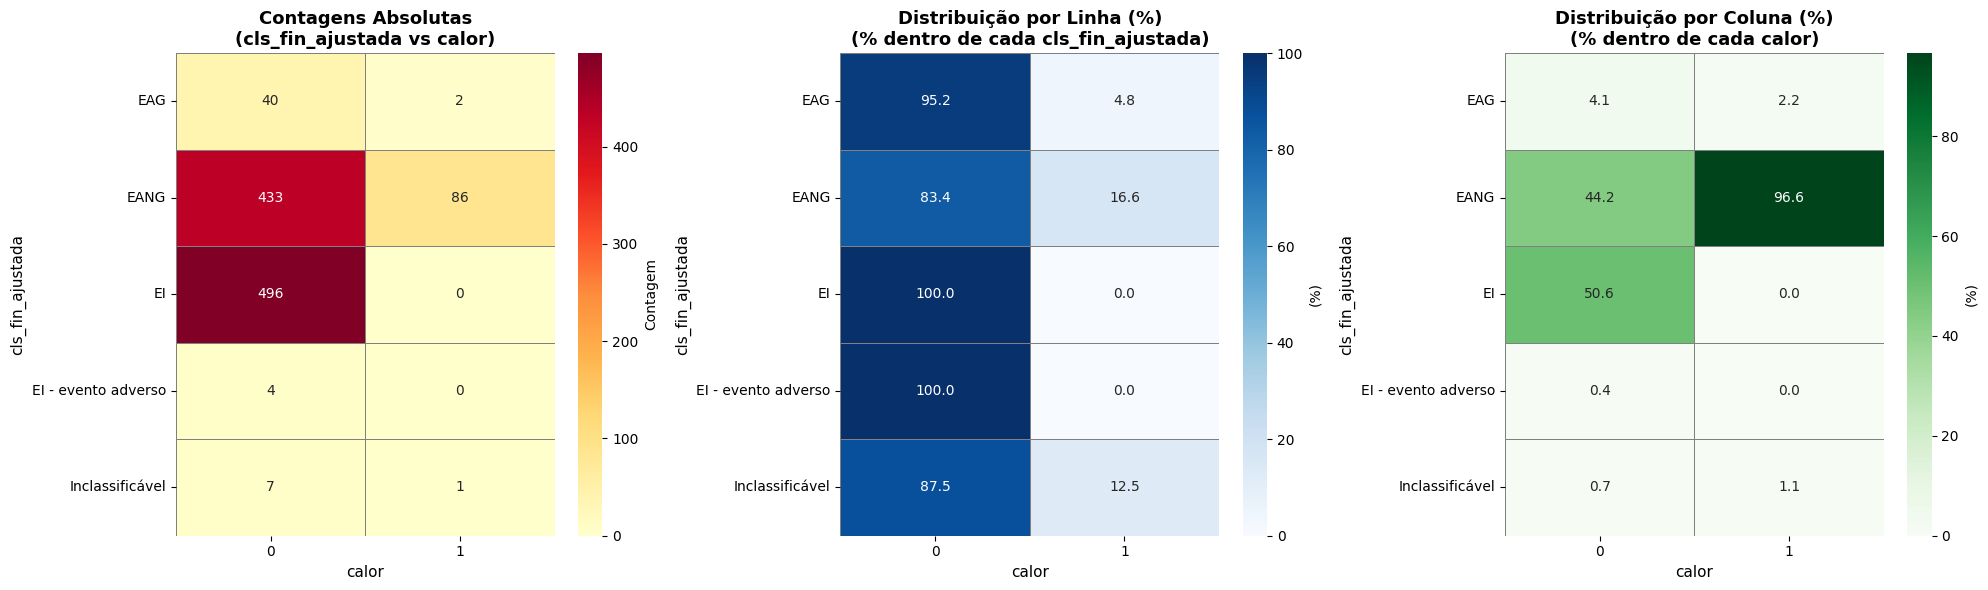


Gerando gráficos para: enduracao vs cls_fin_ajustada


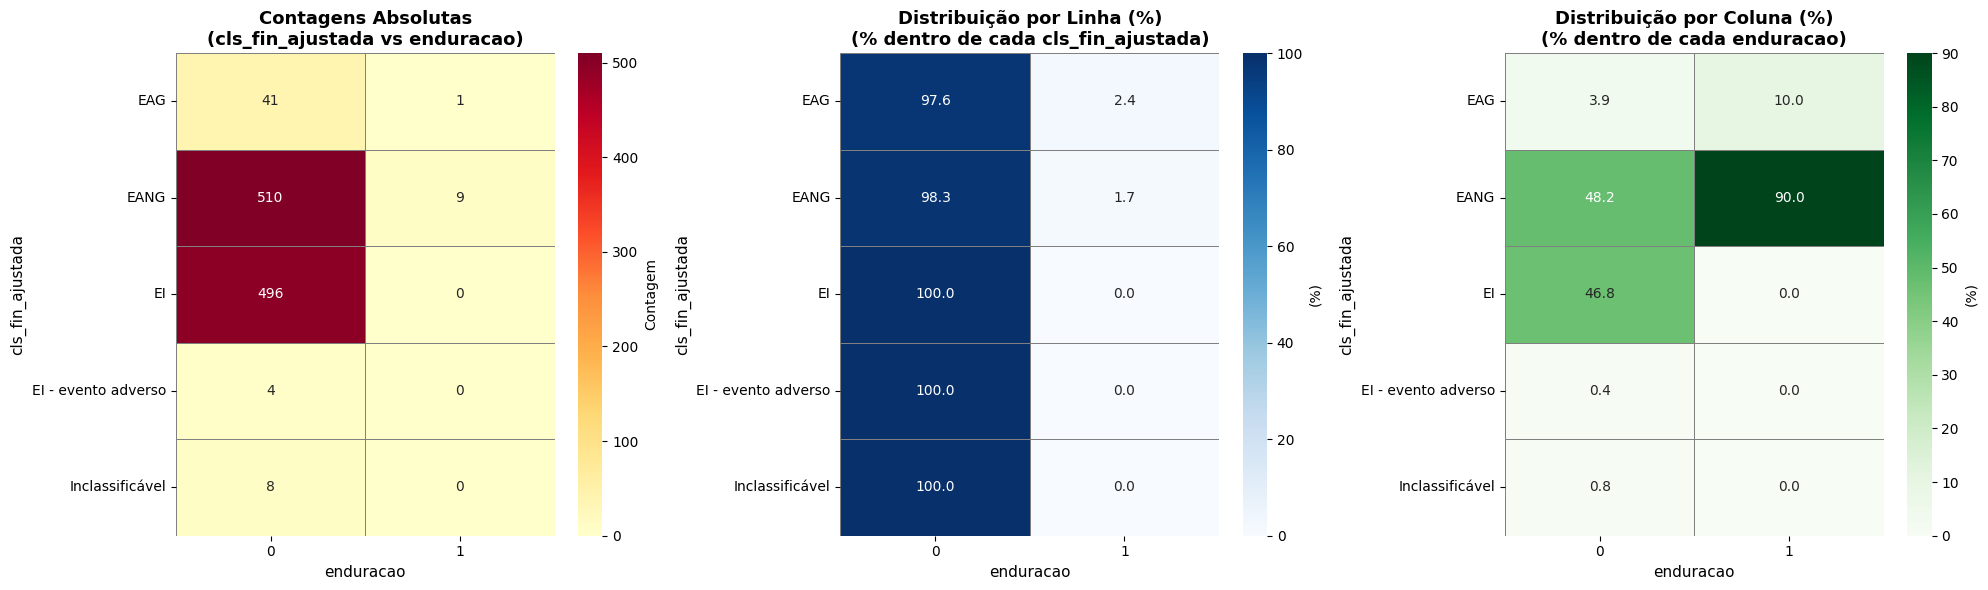


Gerando gráficos para: abscesso_quente vs cls_fin_ajustada


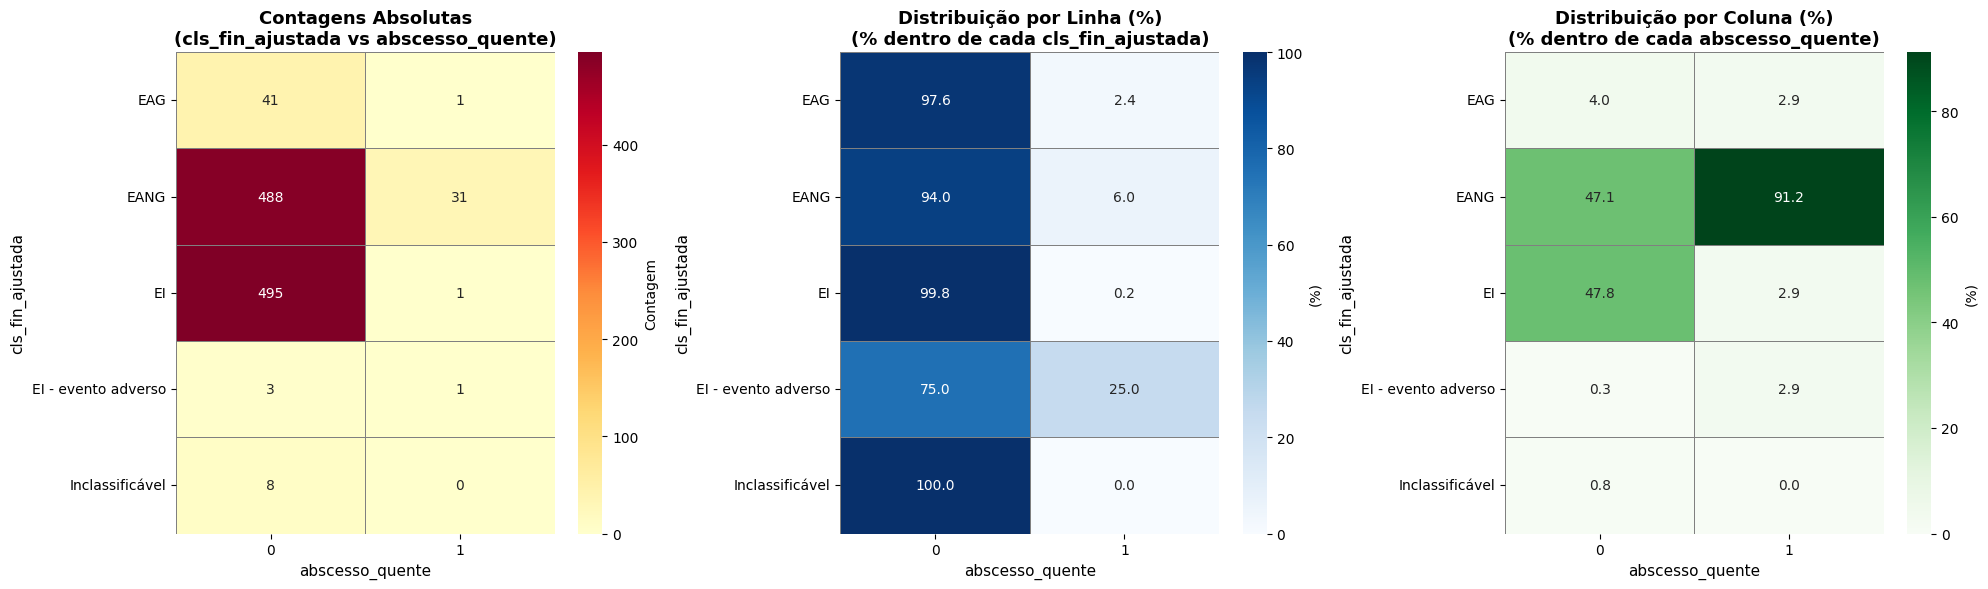


Gerando gráficos para: lesao vs cls_fin_ajustada


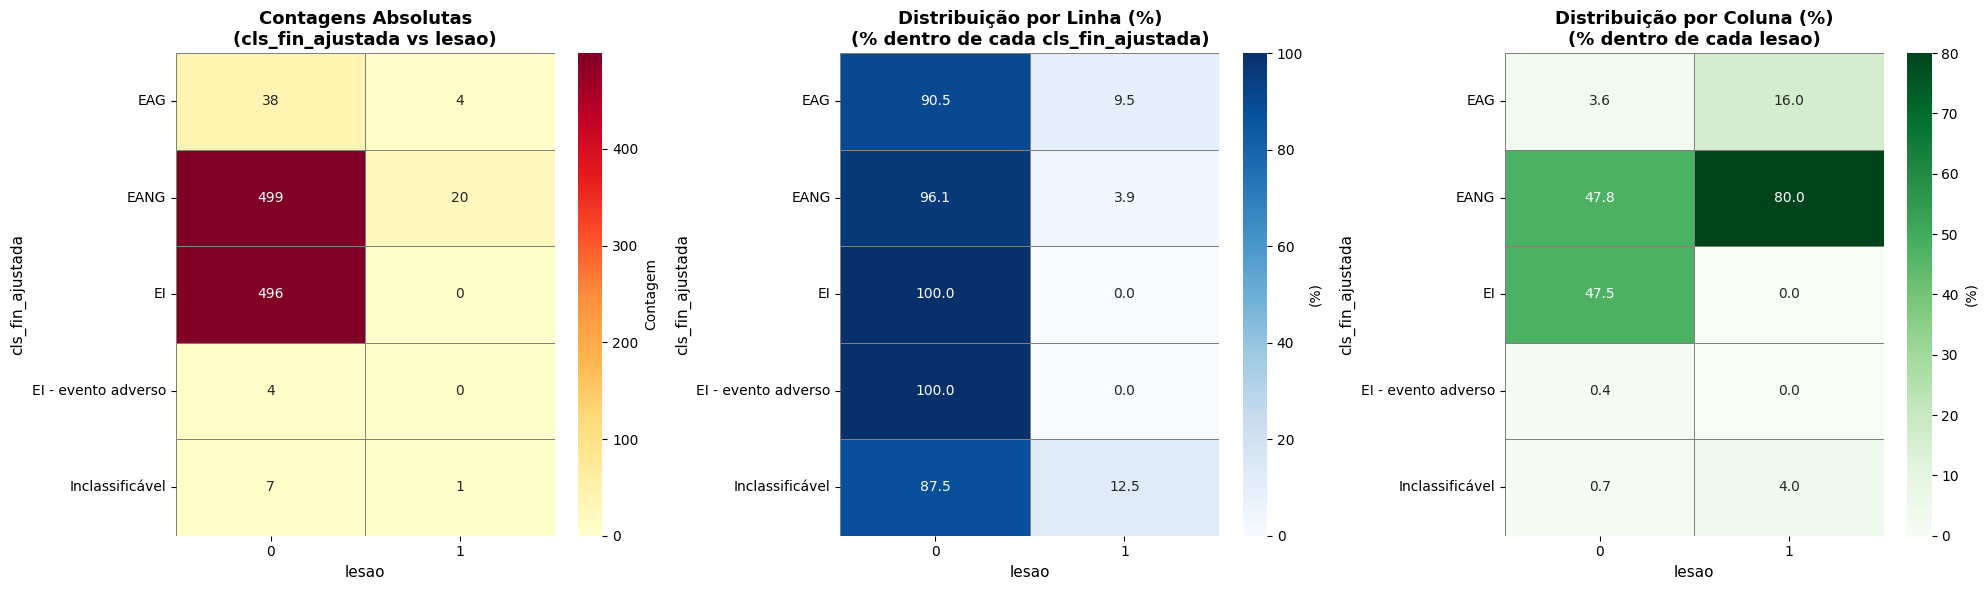


Gerando gráficos para: linfonodomegalia vs cls_fin_ajustada


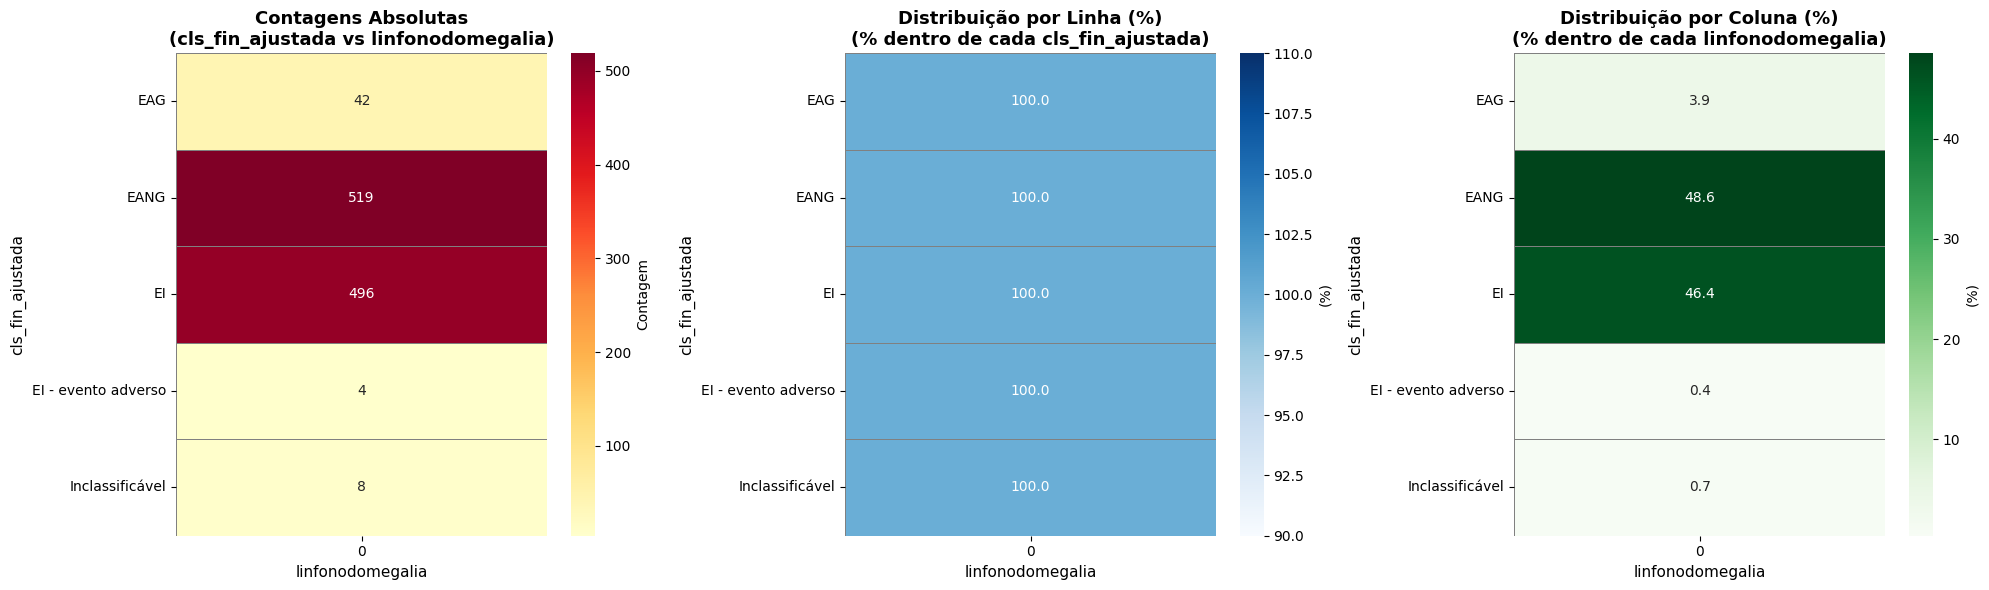


Gerando gráficos para: prurido vs cls_fin_ajustada


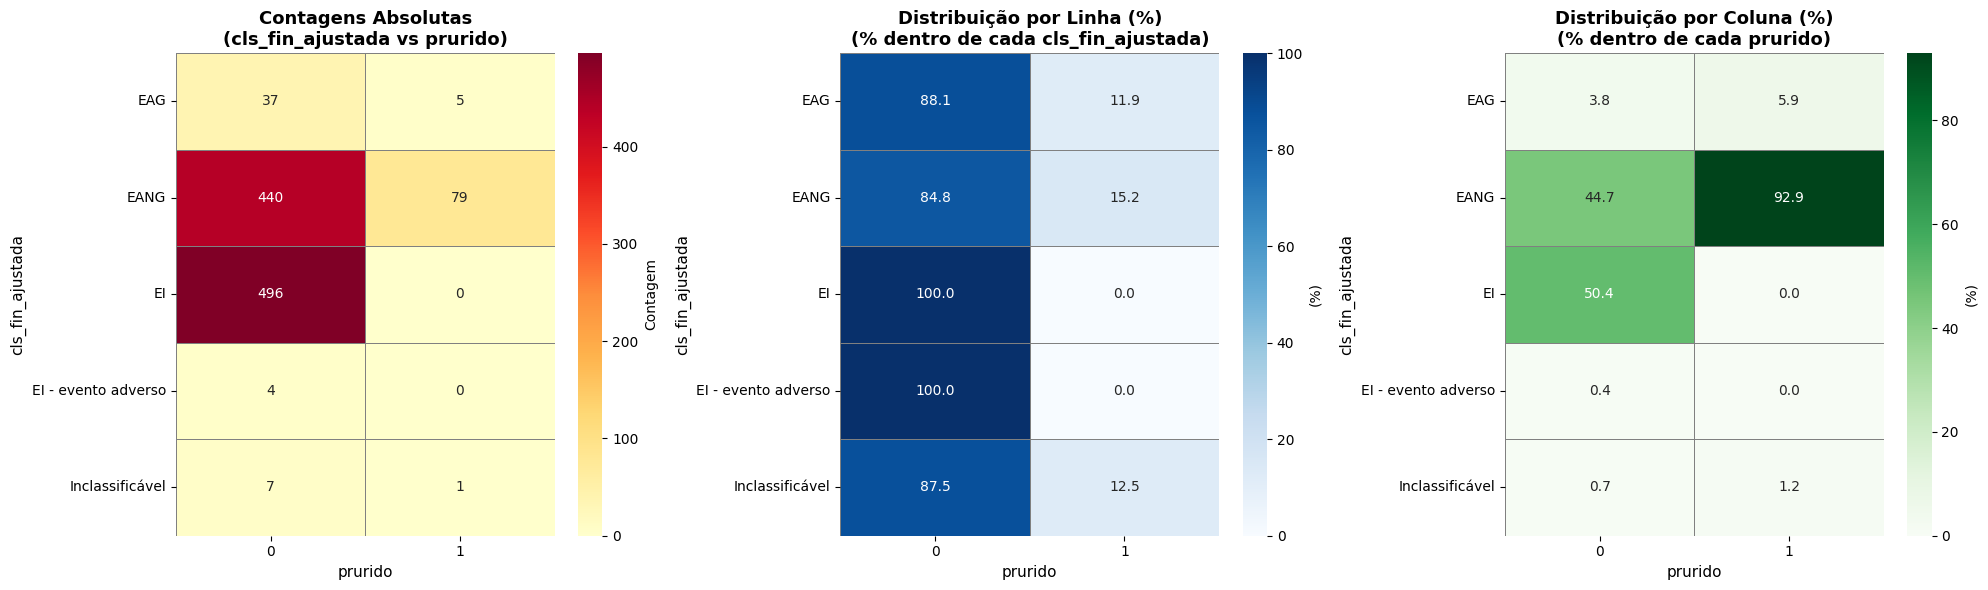


Gerando gráficos para: febre vs cls_fin_ajustada


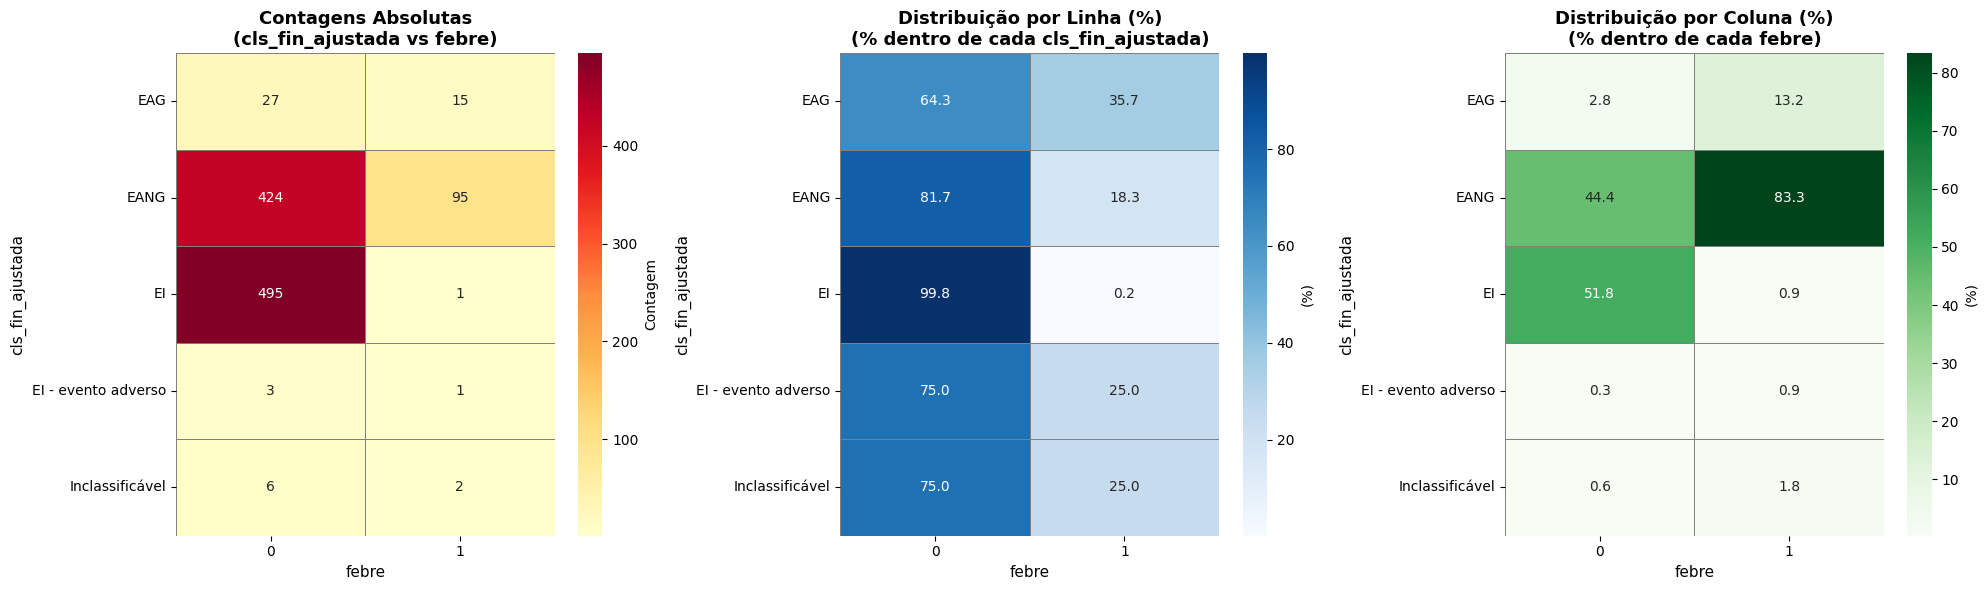


Gerando gráficos para: nausea vs cls_fin_ajustada


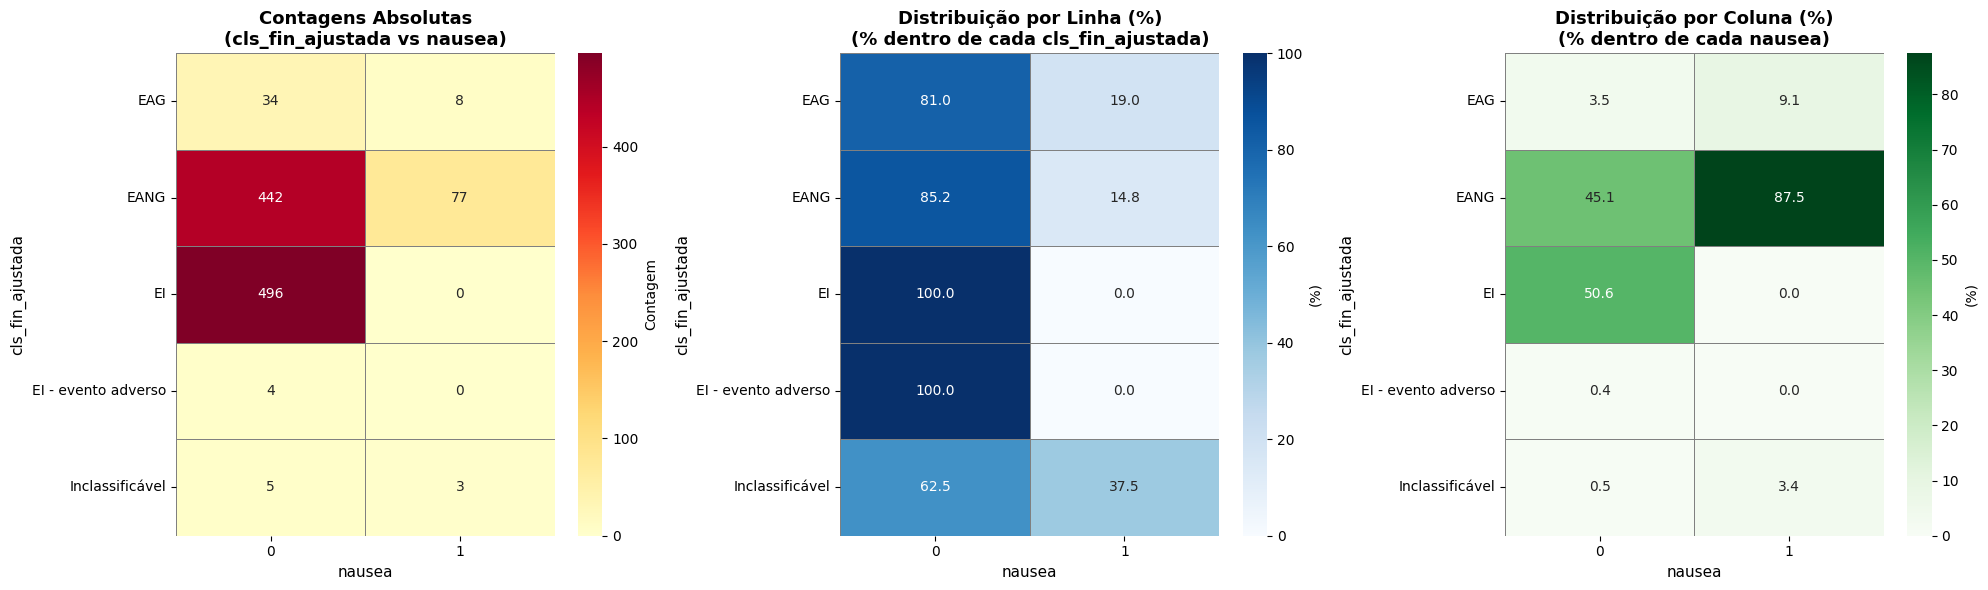


Gerando gráficos para: emese vs cls_fin_ajustada


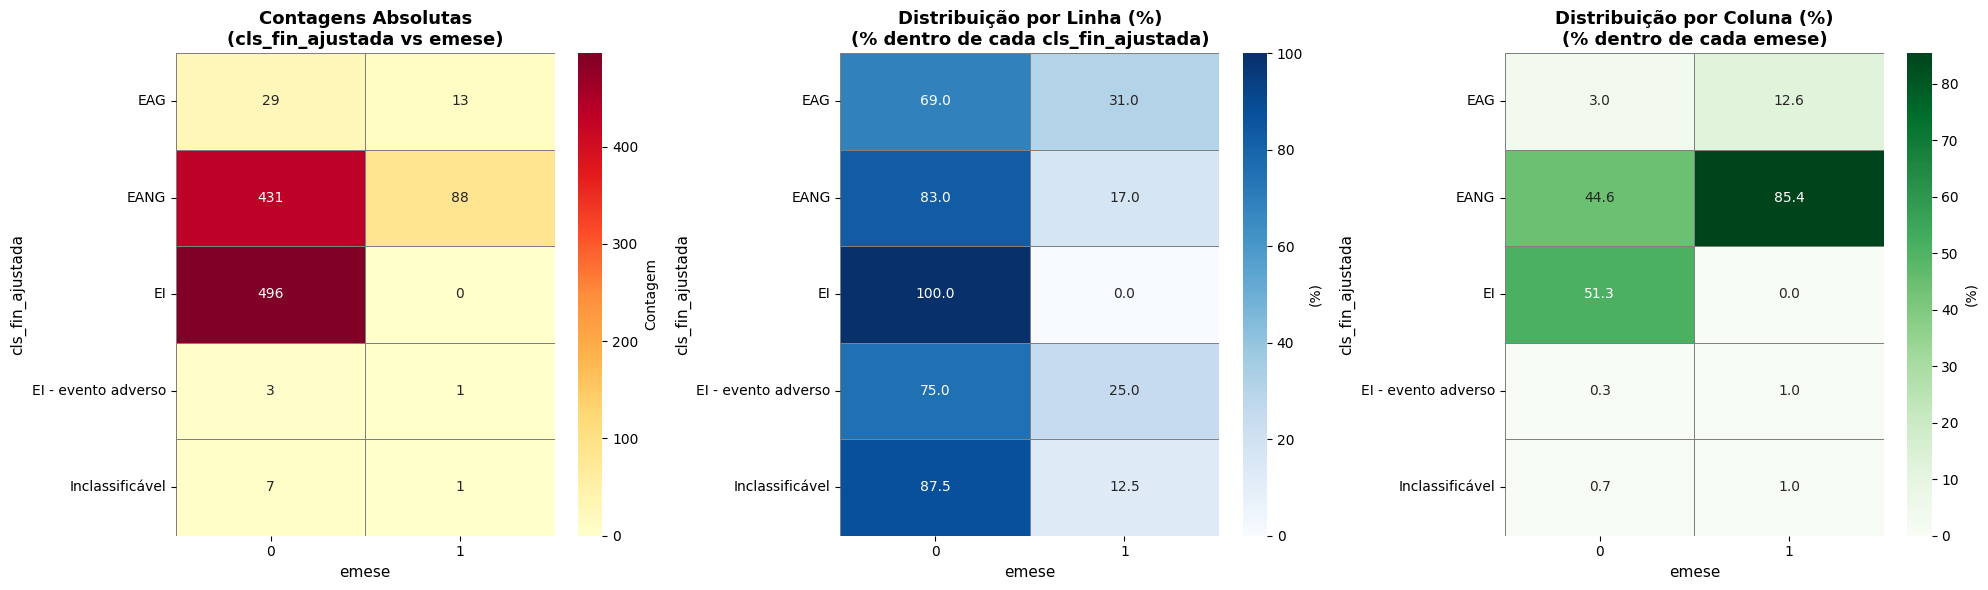


Gerando gráficos para: diarreia vs cls_fin_ajustada


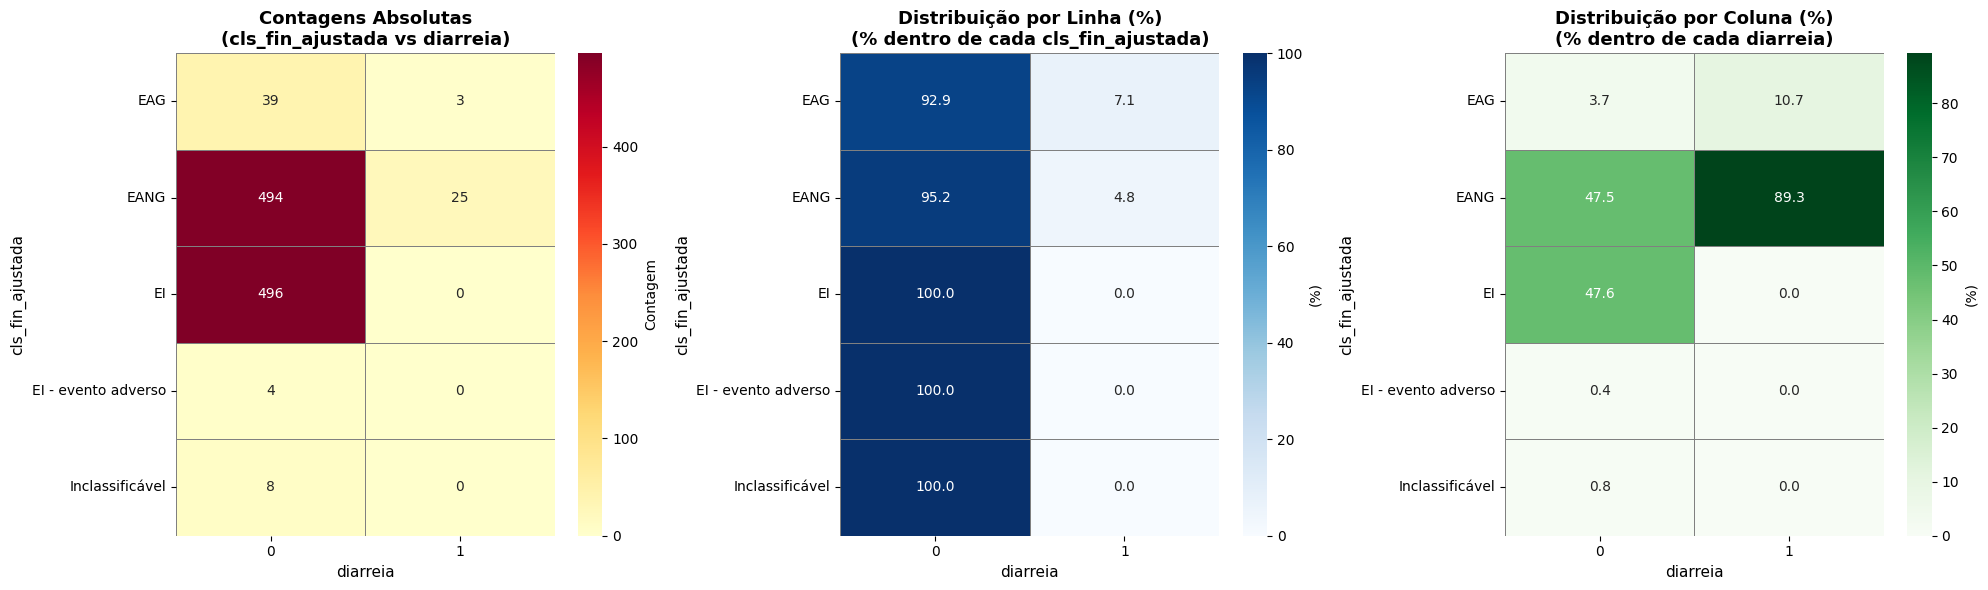


Gerando gráficos para: tontura vs cls_fin_ajustada


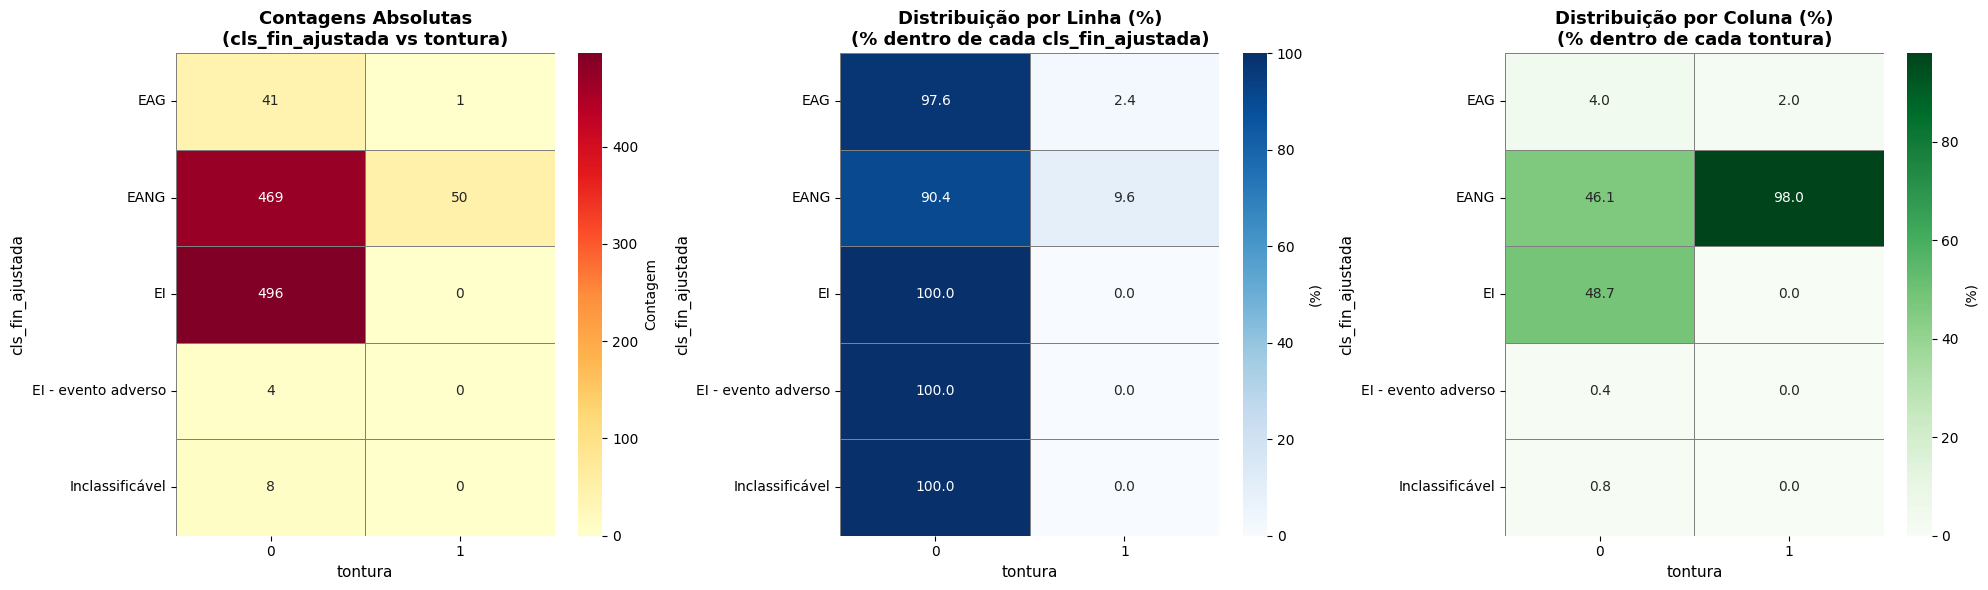


Gerando gráficos para: sincope vs cls_fin_ajustada


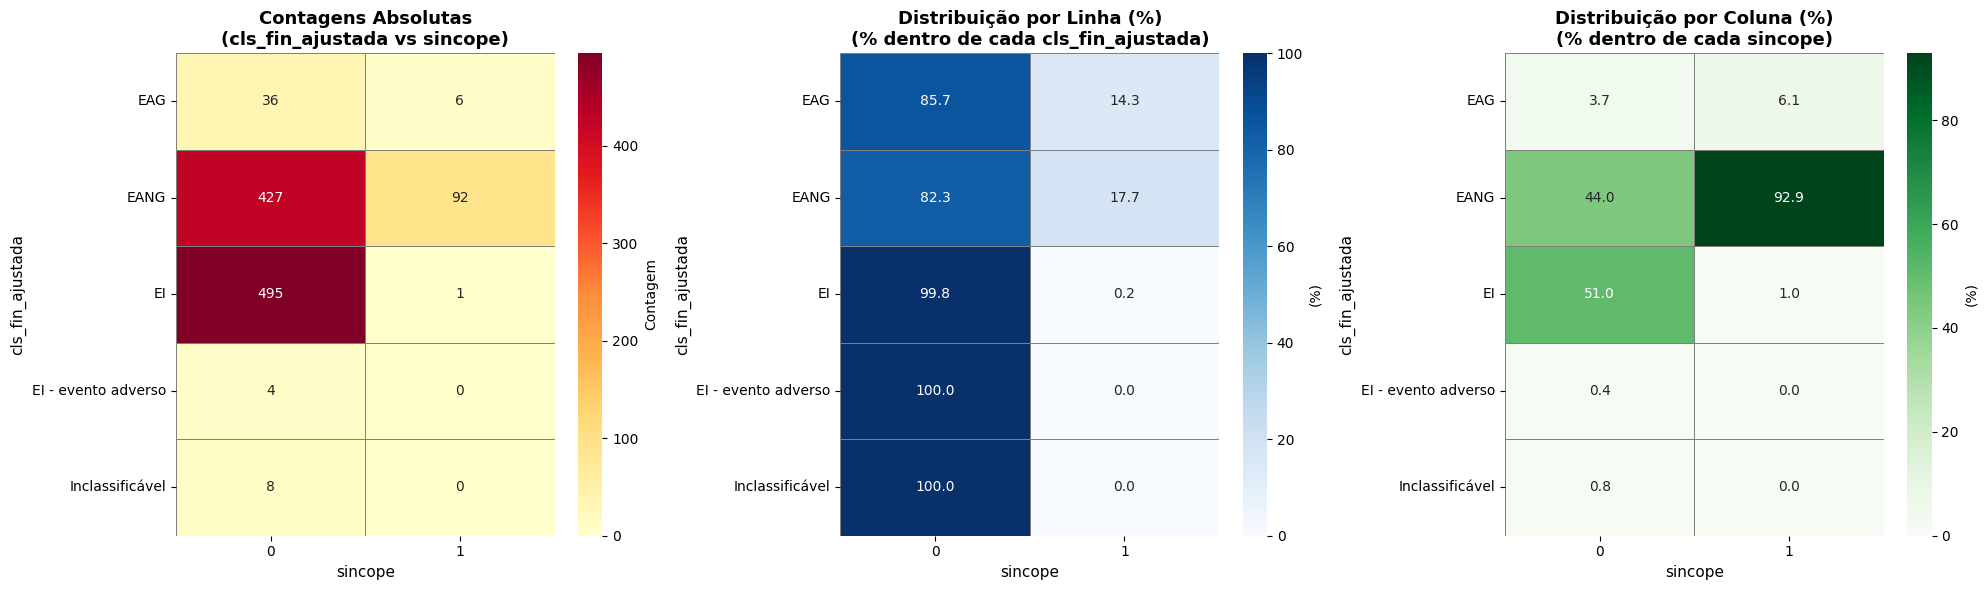


Gerando gráficos para: parestesia vs cls_fin_ajustada


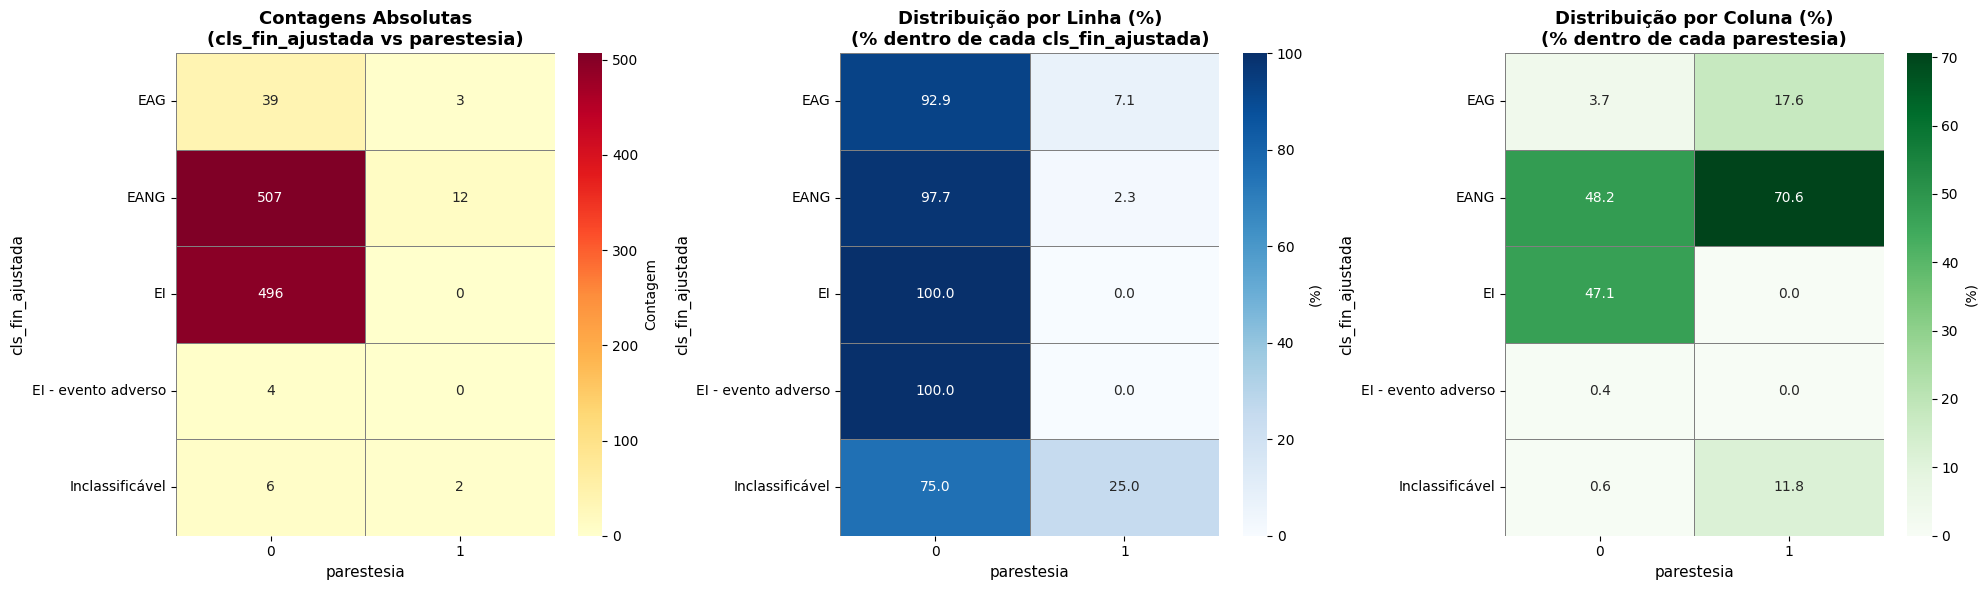


Gerando gráficos para: convulsao vs cls_fin_ajustada


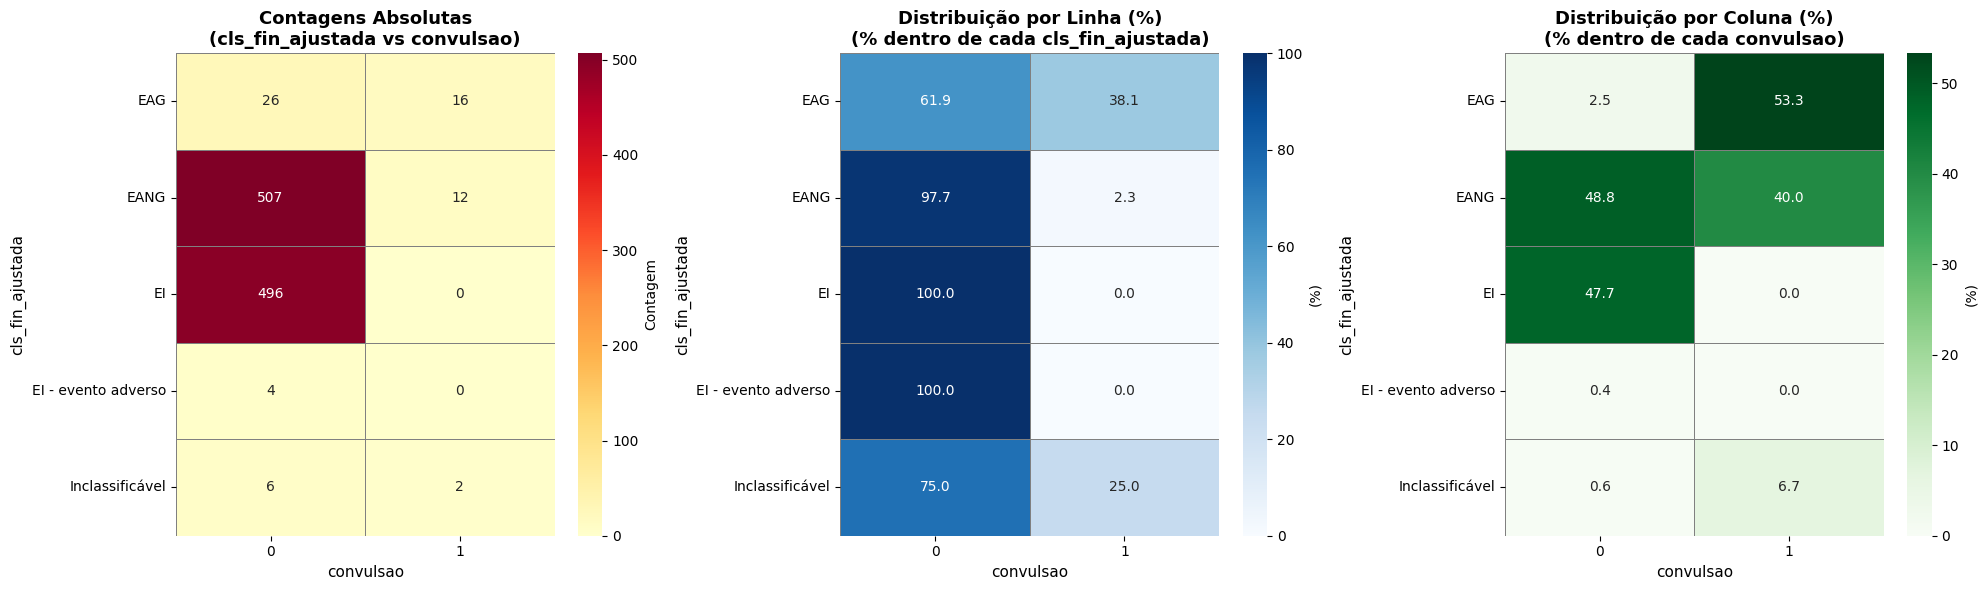


Gerando gráficos para: confusao_mental vs cls_fin_ajustada


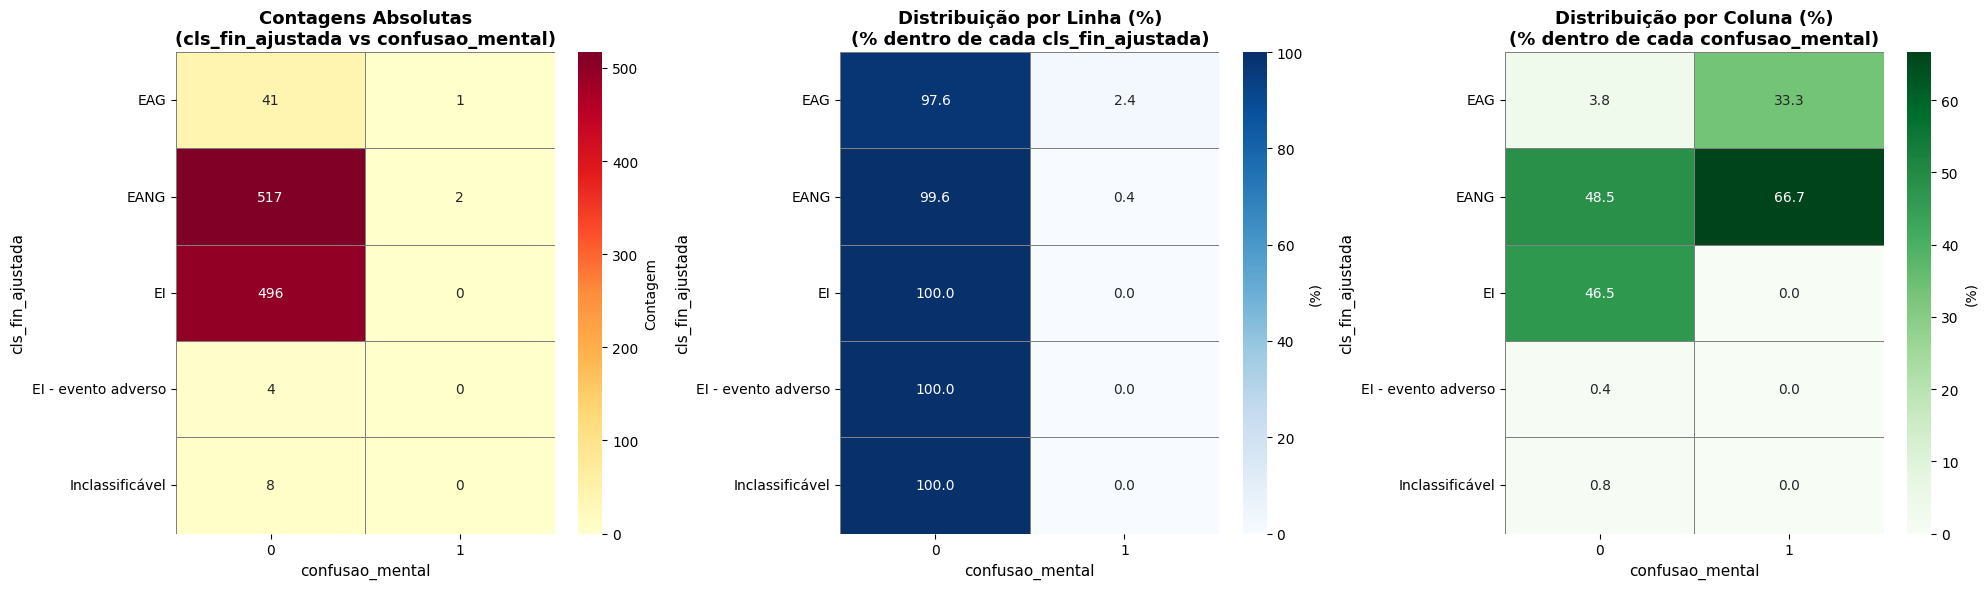


Gerando gráficos para: fraqueza vs cls_fin_ajustada


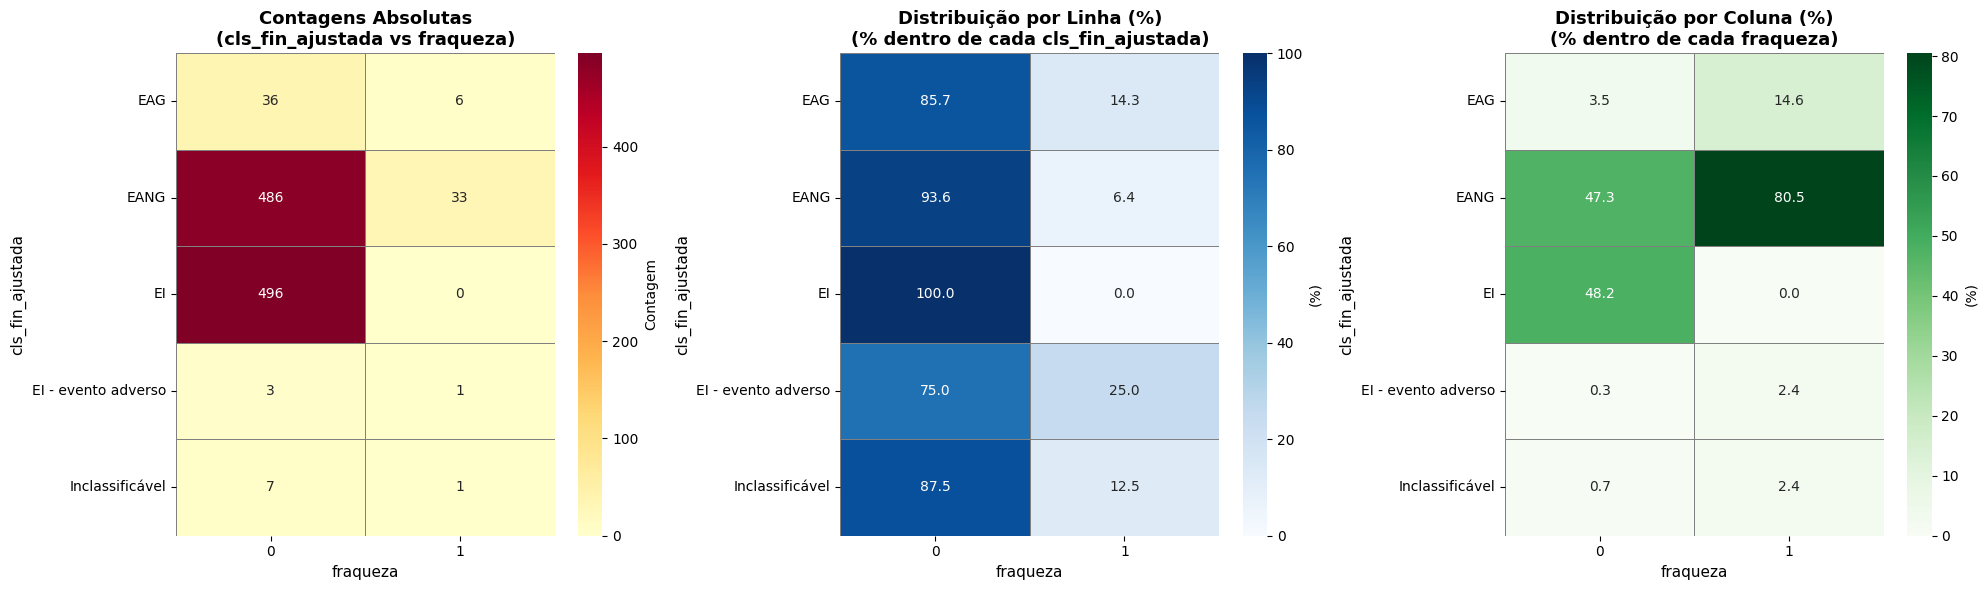


Gerando gráficos para: hipotensao vs cls_fin_ajustada


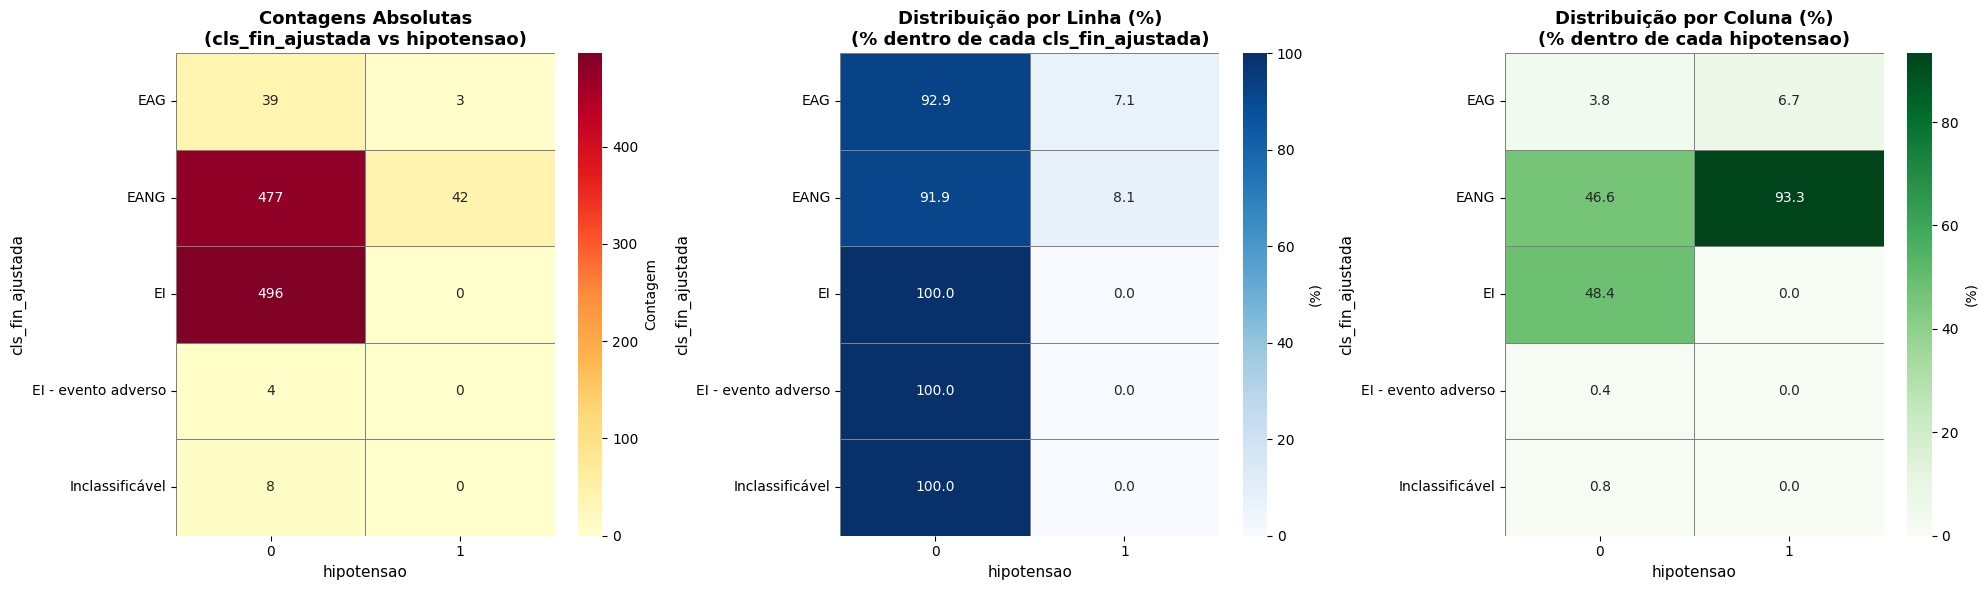


Gerando gráficos para: taquicardia vs cls_fin_ajustada


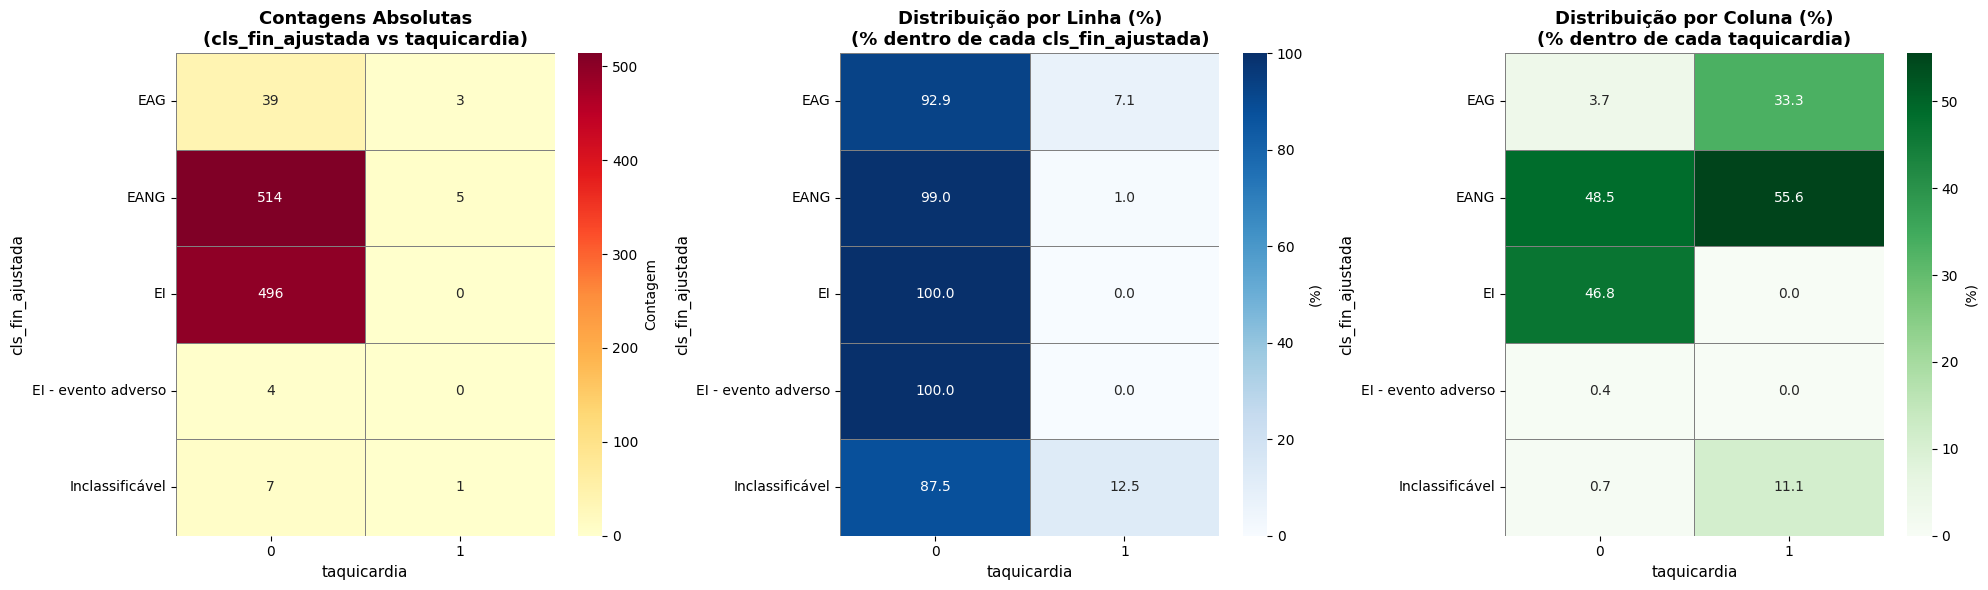


Gerando gráficos para: bradicardia vs cls_fin_ajustada


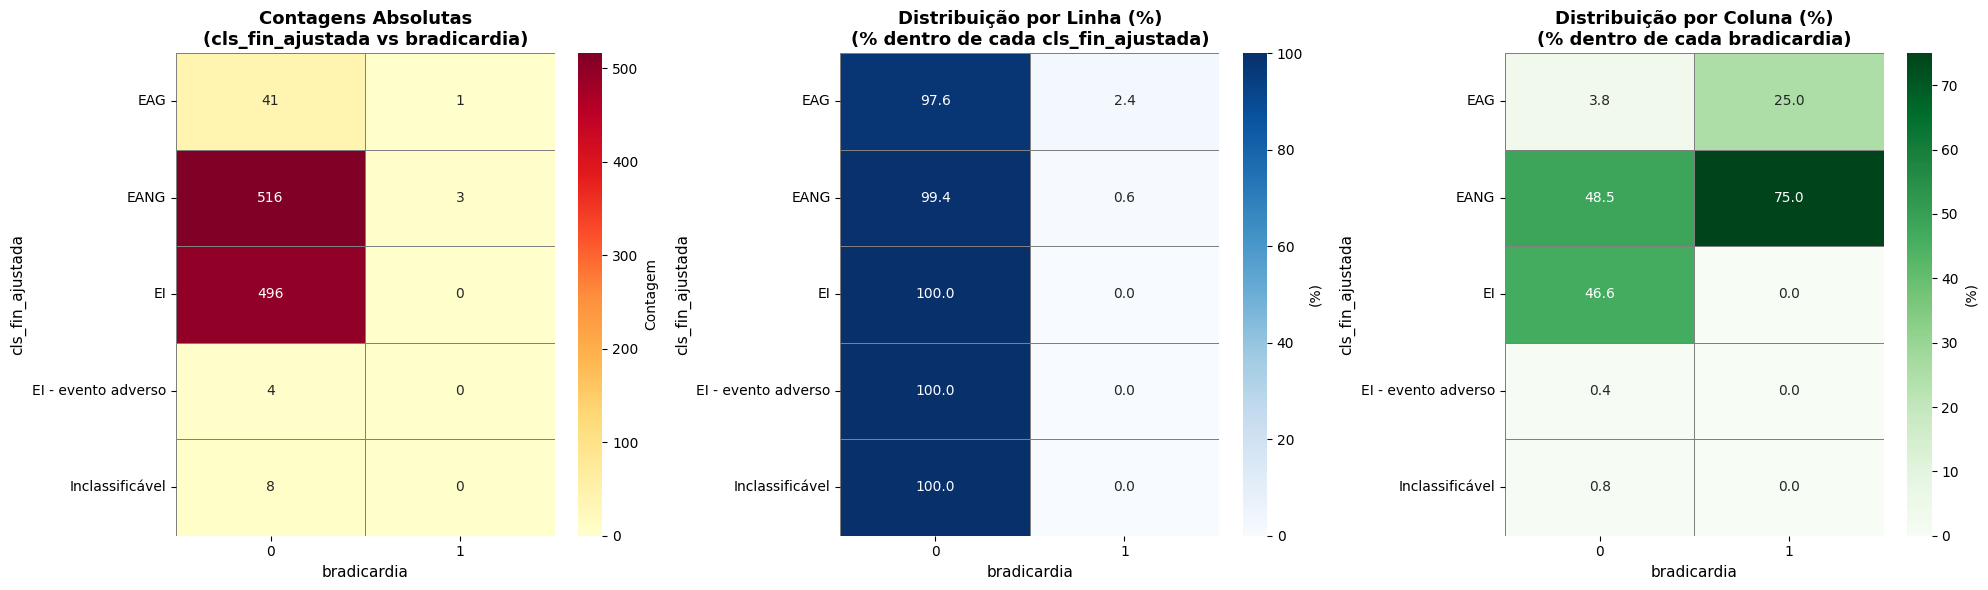


Gerando gráficos para: extremidades_frias vs cls_fin_ajustada


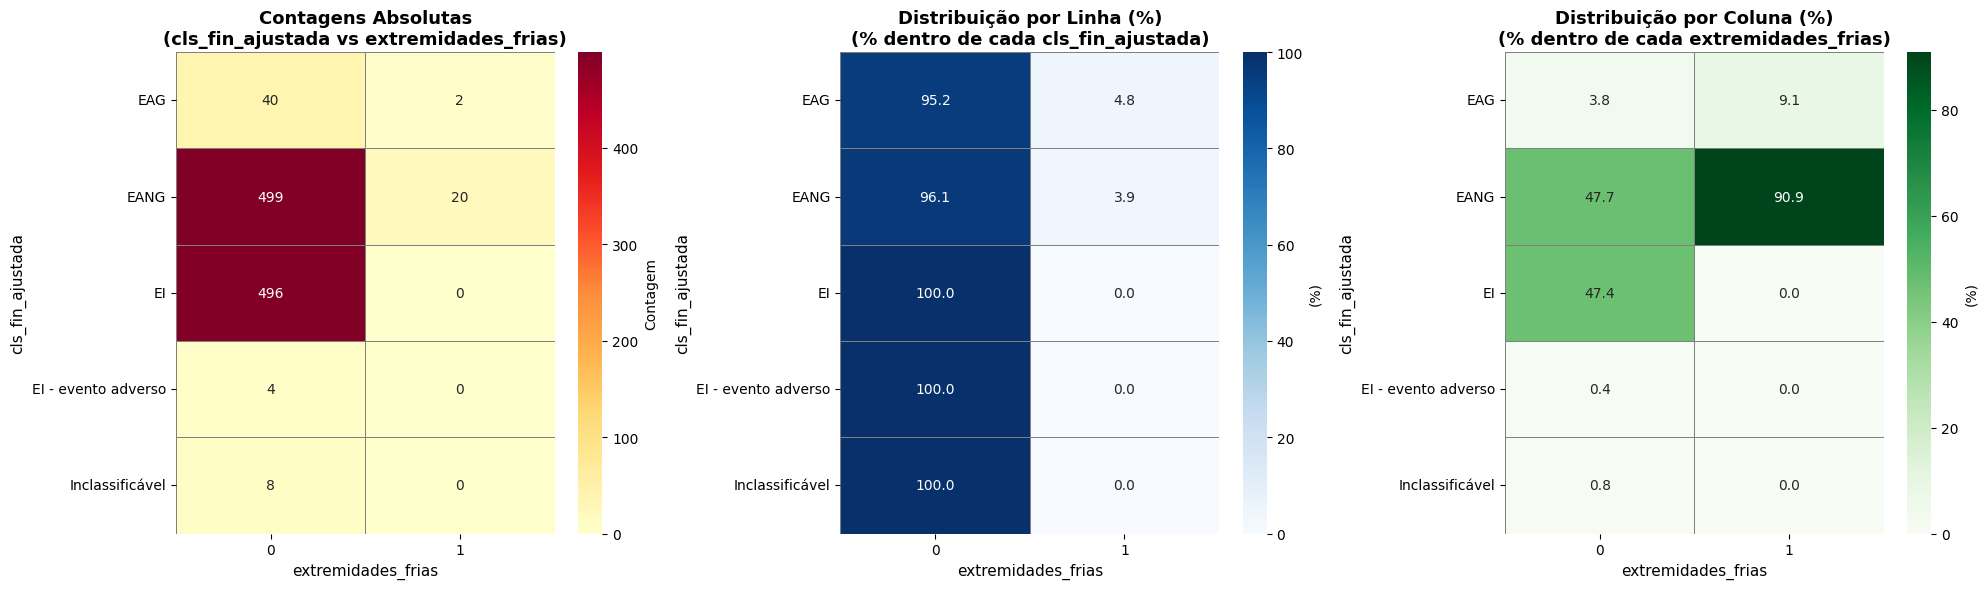


Gerando gráficos para: palidez vs cls_fin_ajustada


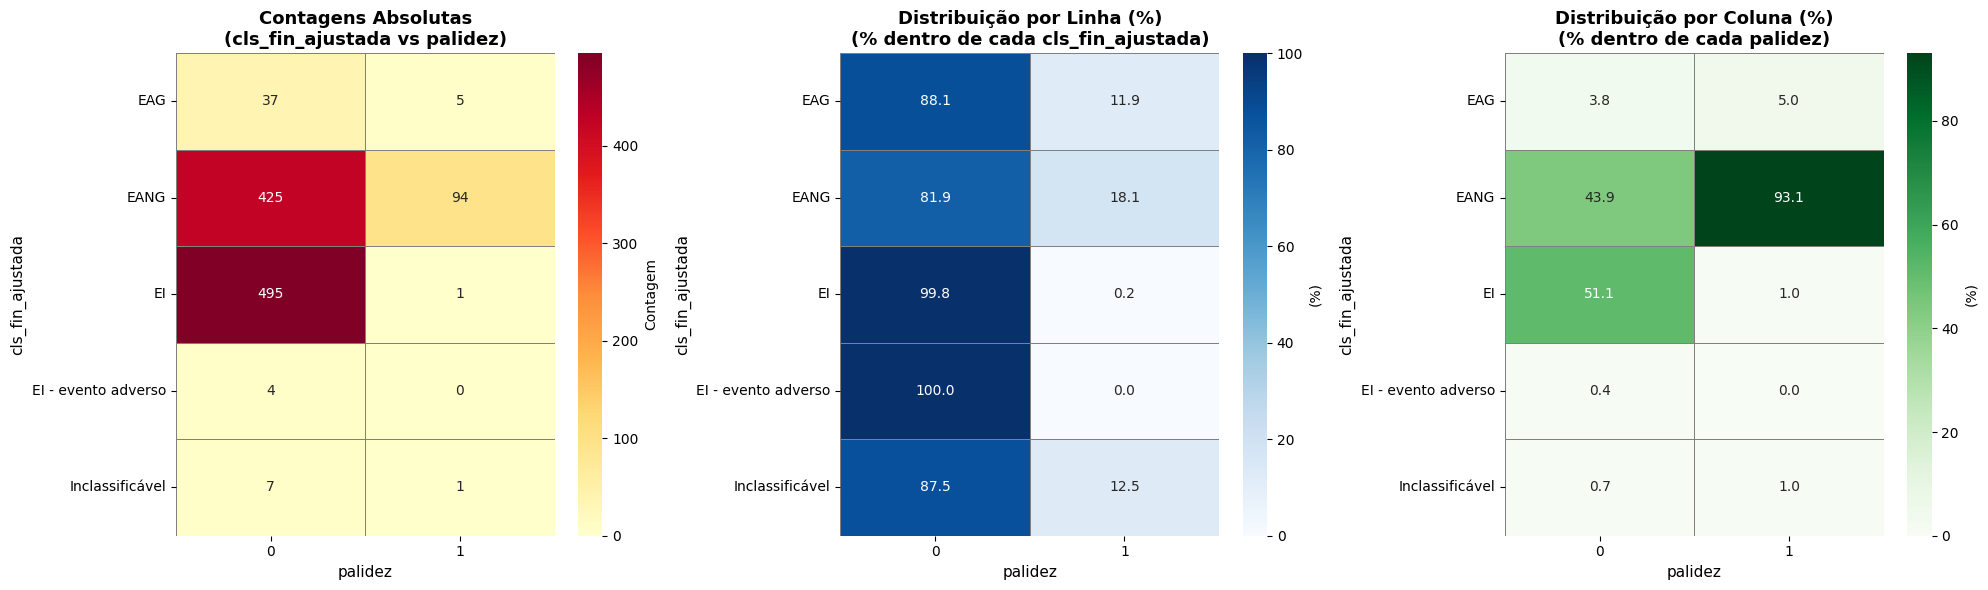


Gerando gráficos para: sudorese vs cls_fin_ajustada


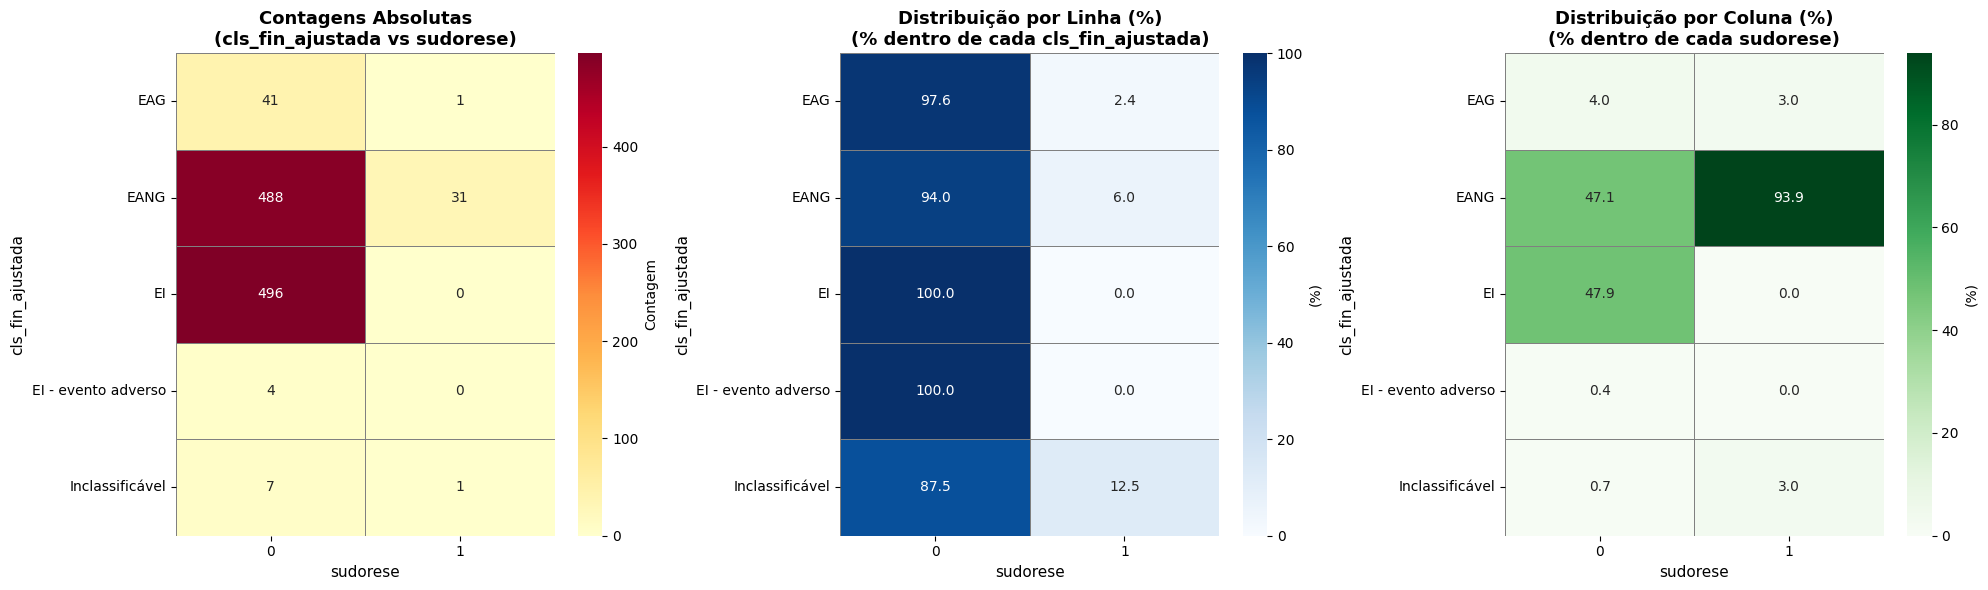


Gerando gráficos para: urticaria vs cls_fin_ajustada


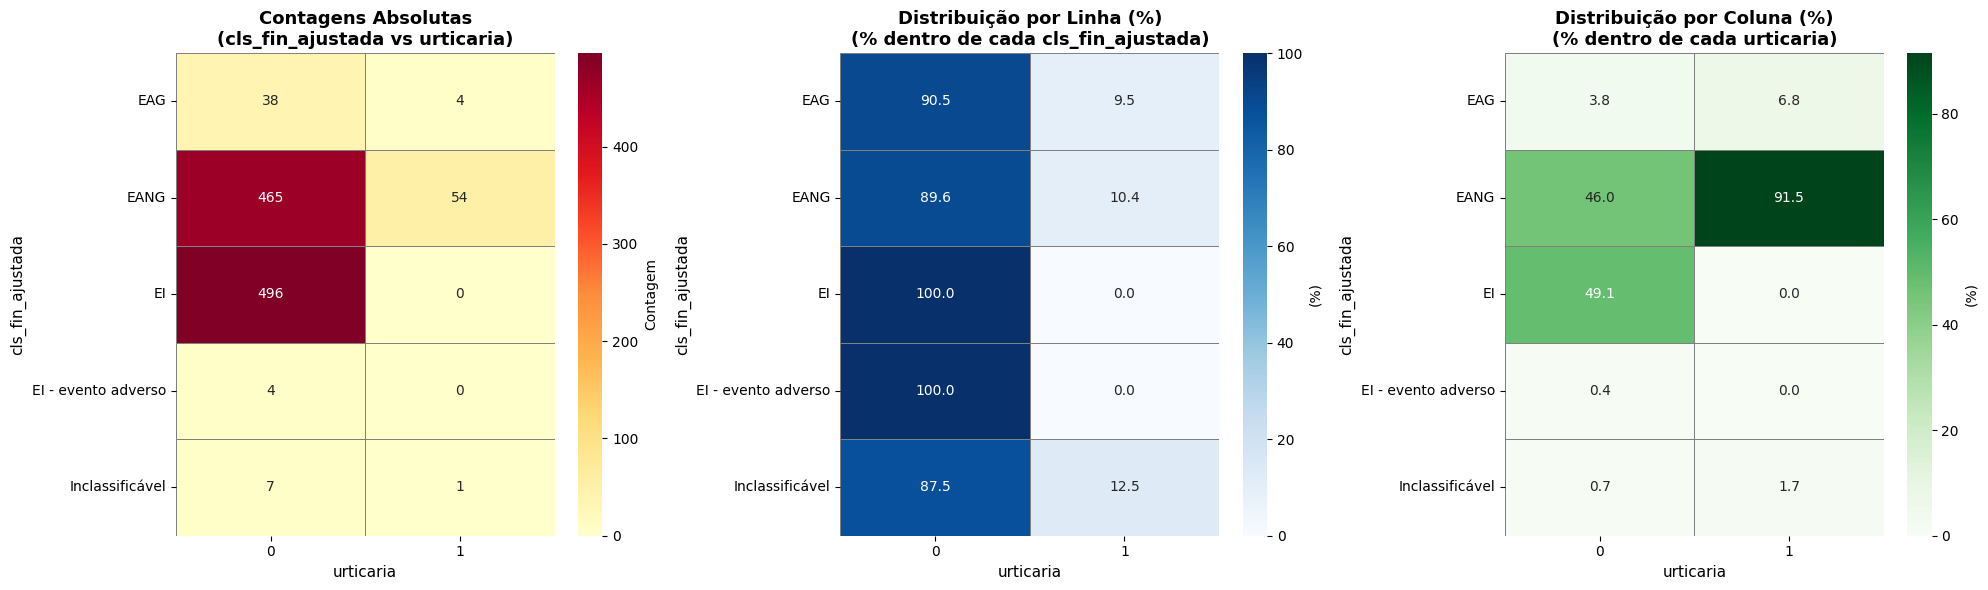


Gerando gráficos para: broncoespasmo vs cls_fin_ajustada


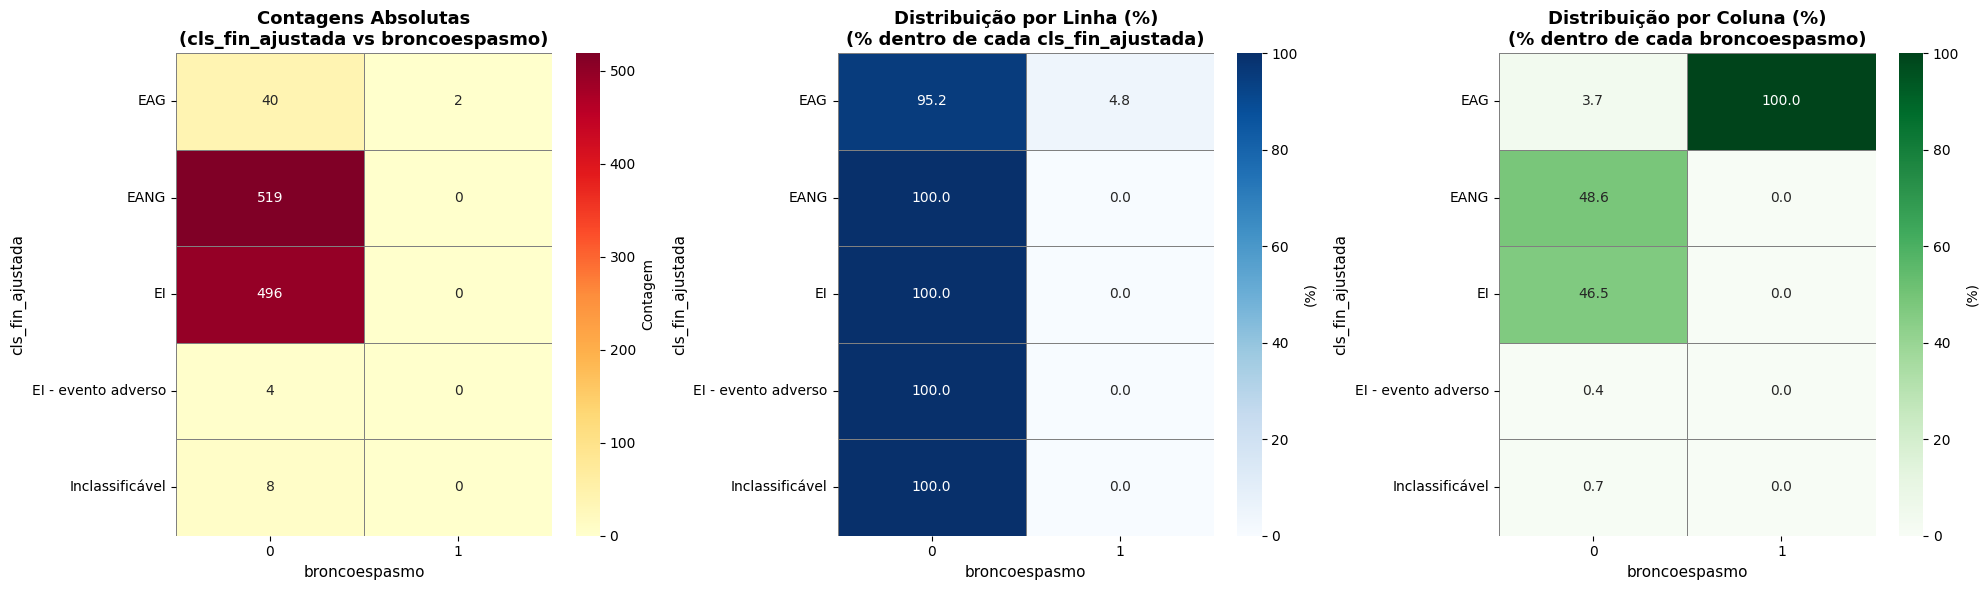


Gerando gráficos para: dispneia vs cls_fin_ajustada


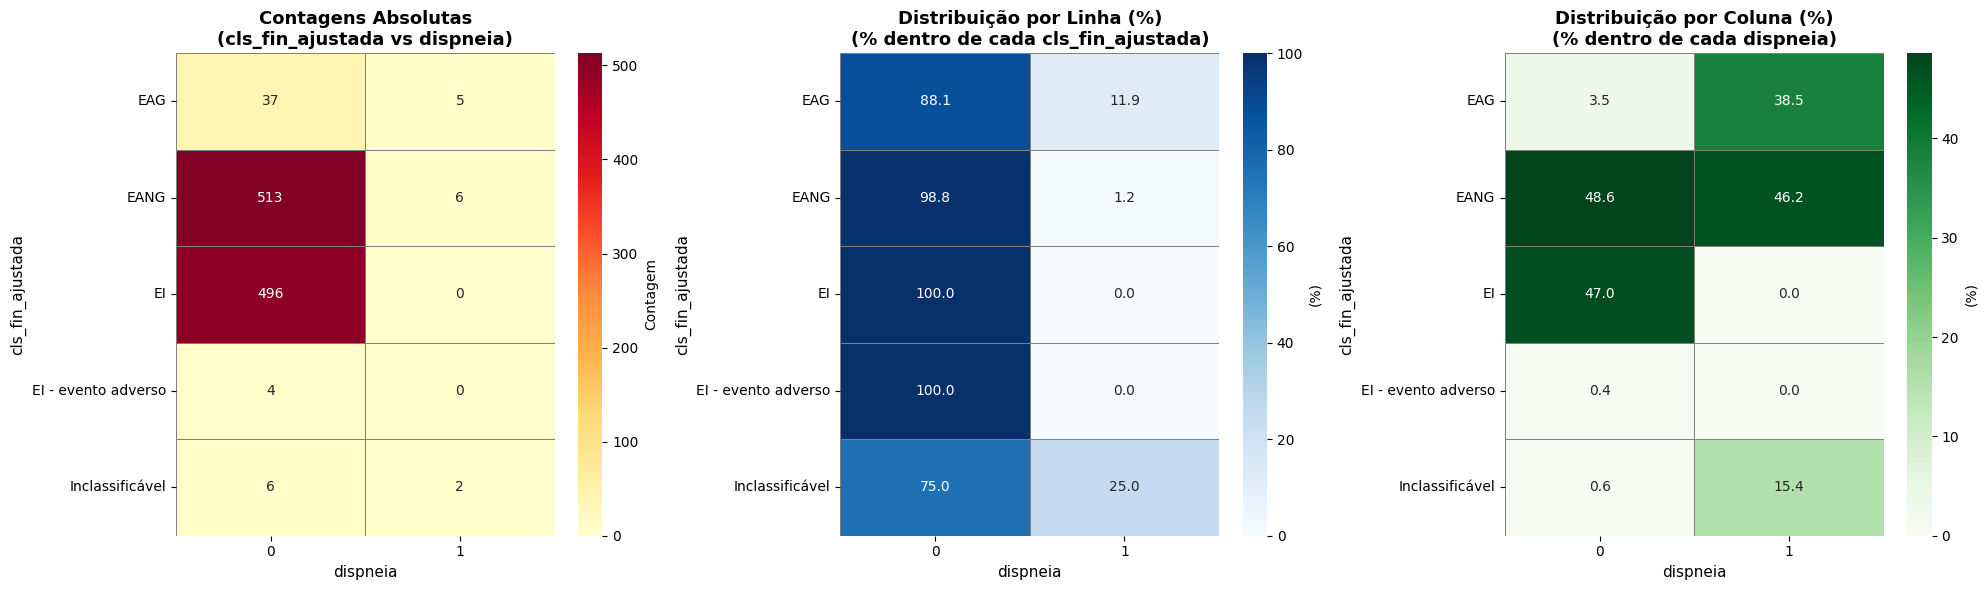


Gerando gráficos para: angioedema vs cls_fin_ajustada


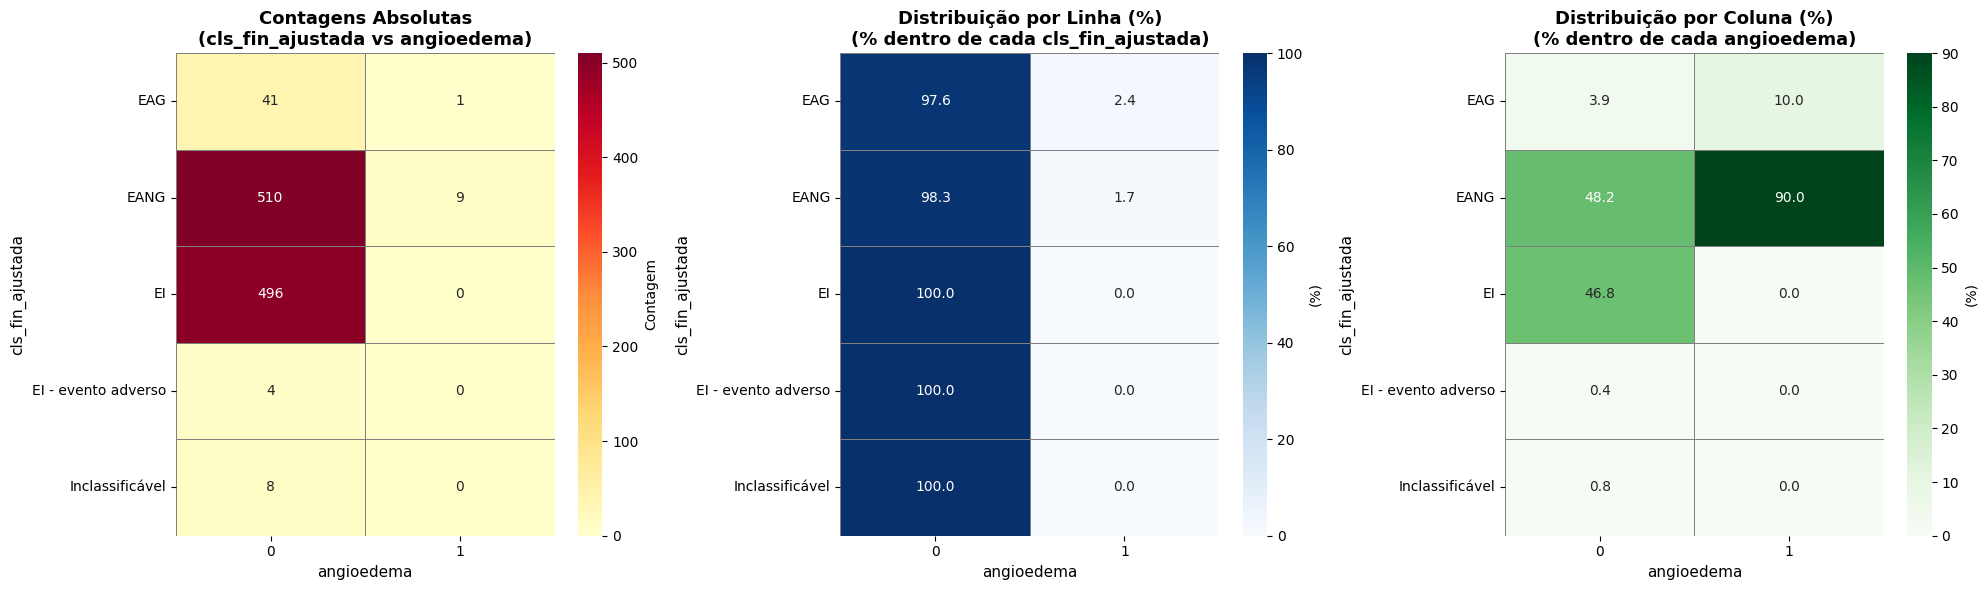


Gerando gráficos para: tremor vs cls_fin_ajustada


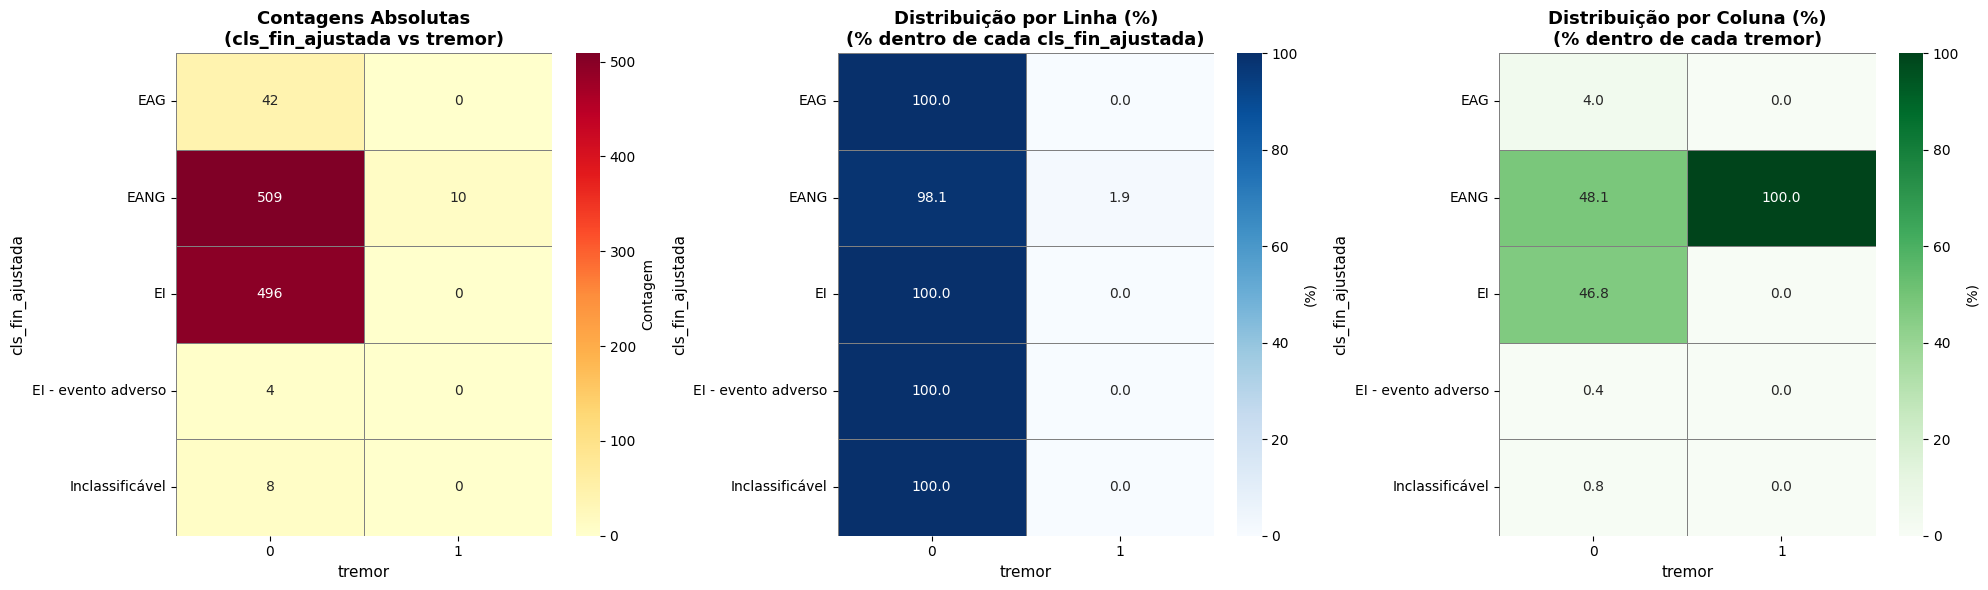


Gerando gráficos para: fotofobia vs cls_fin_ajustada


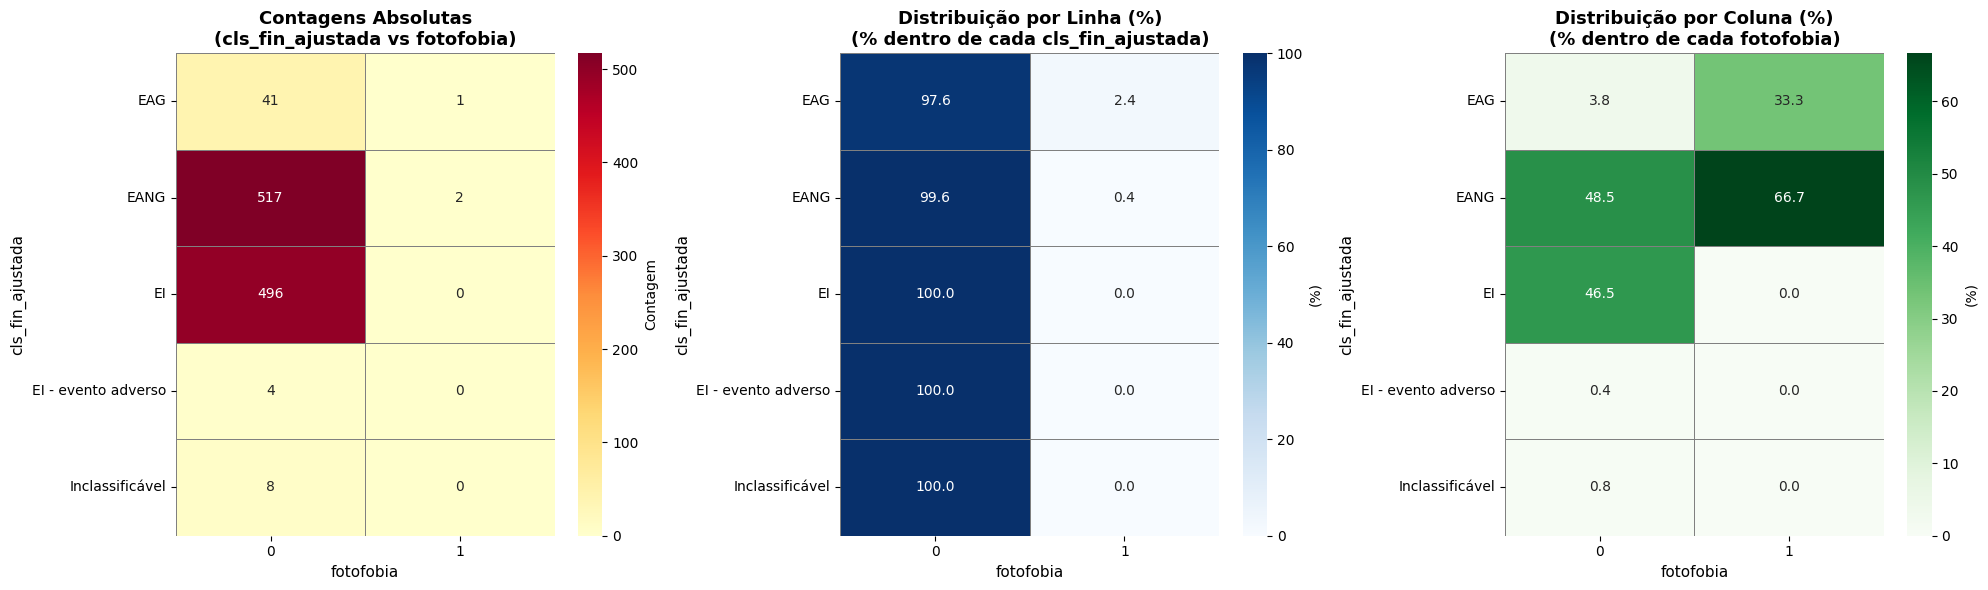


Gerando gráficos para: visao_turva vs cls_fin_ajustada


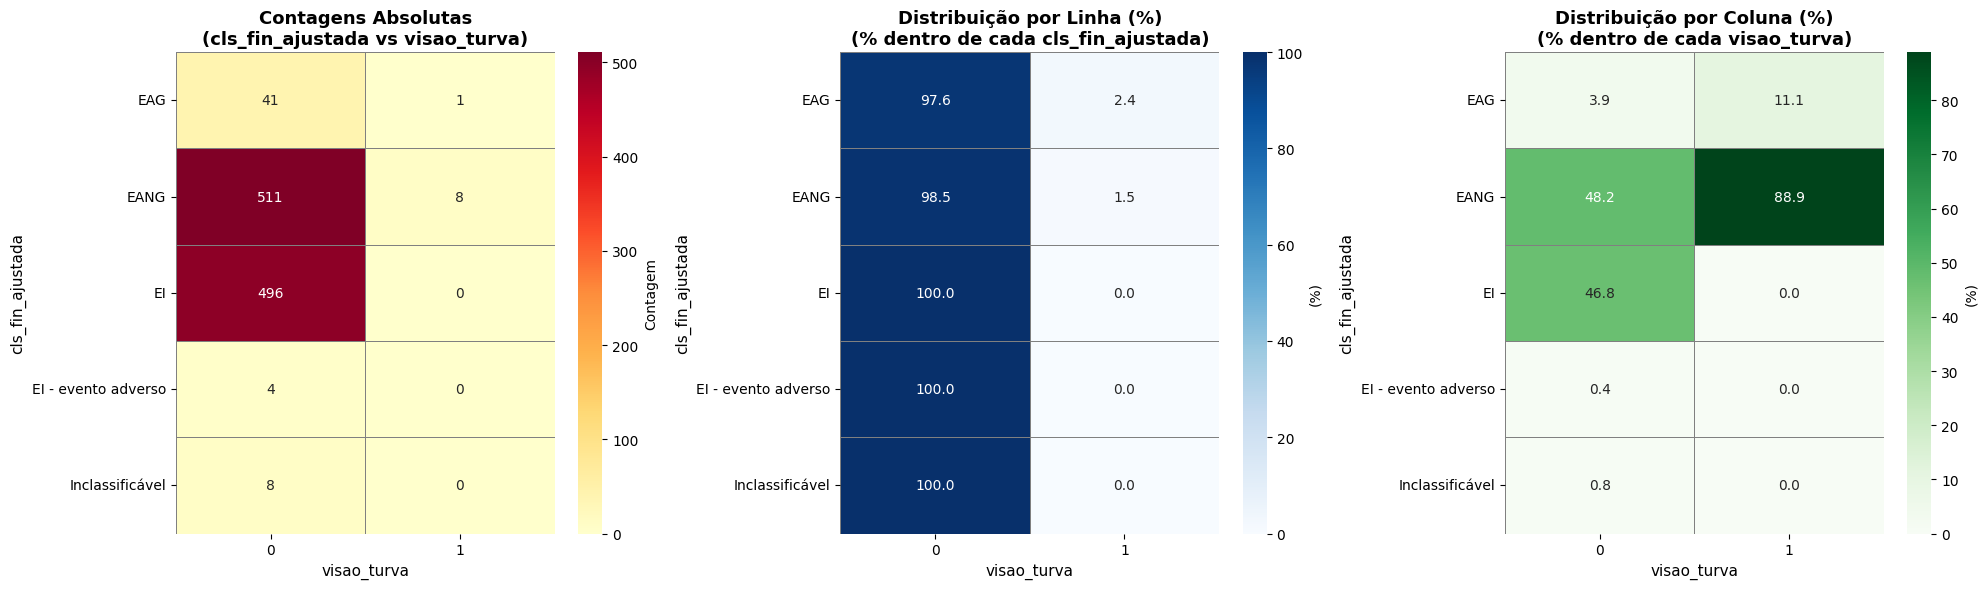


Gerando gráficos para: guillain_barre vs cls_fin_ajustada


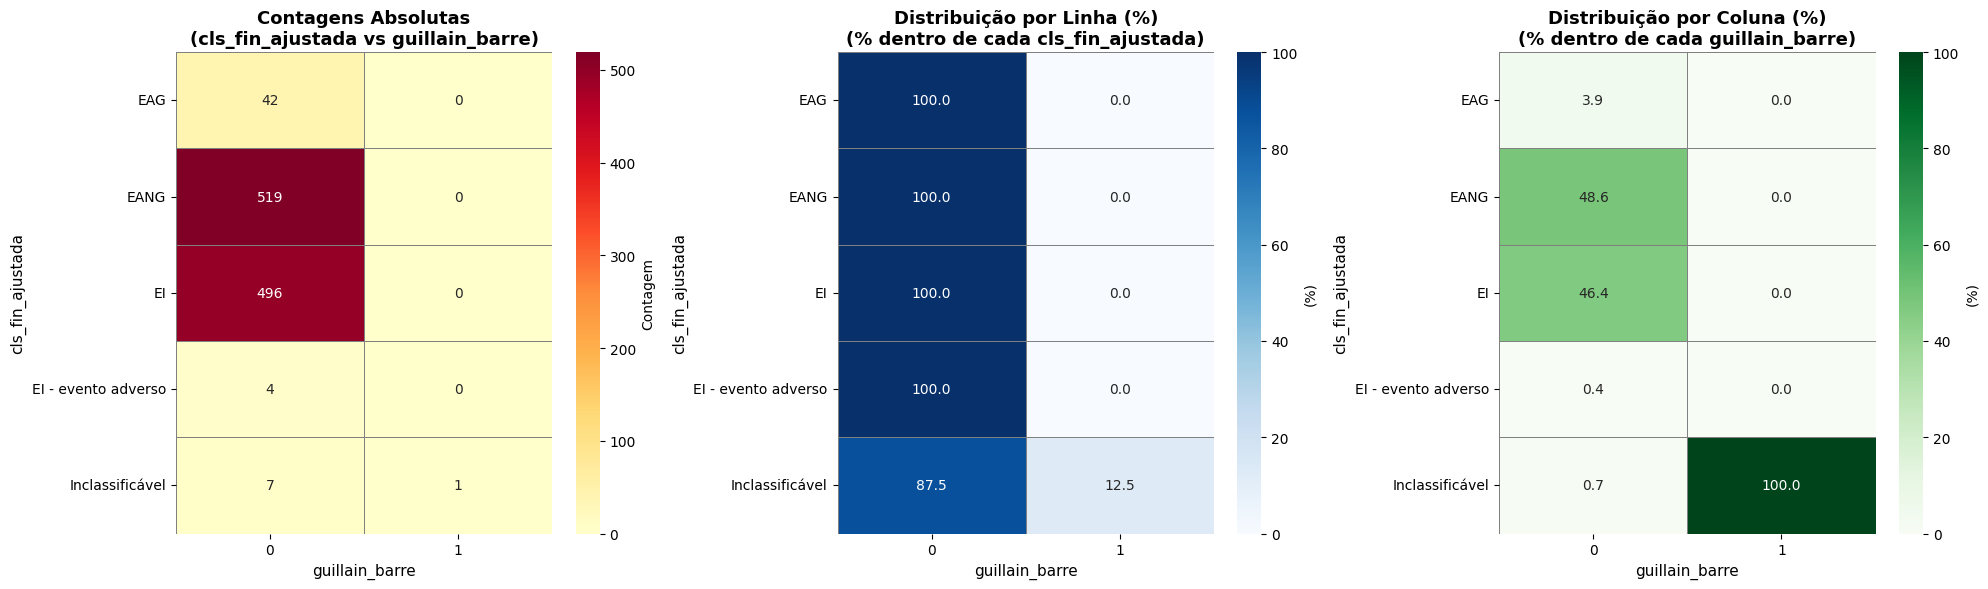


Gerando gráficos para: encefalite vs cls_fin_ajustada


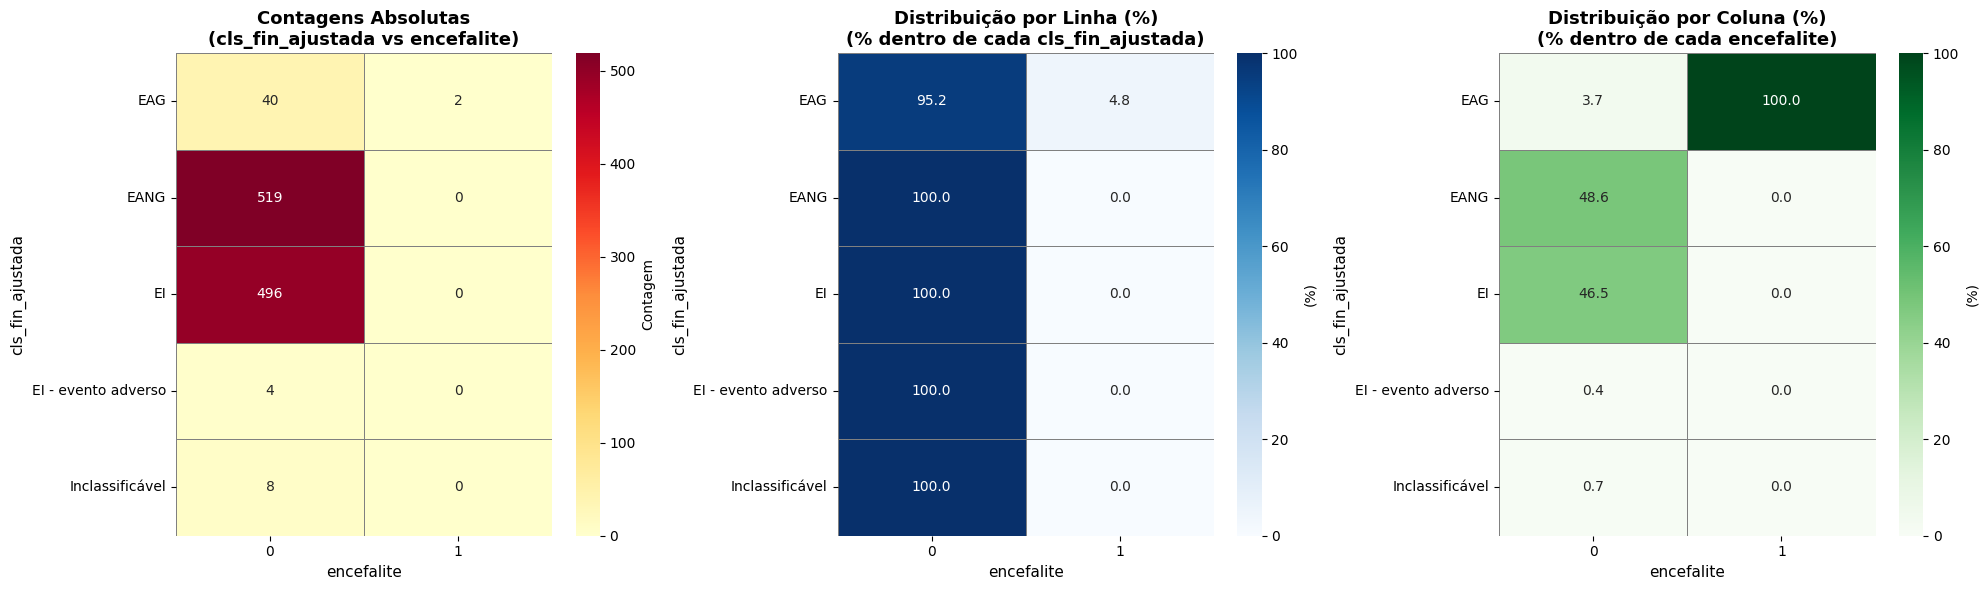


Gerando gráficos para: epilepsia vs cls_fin_ajustada


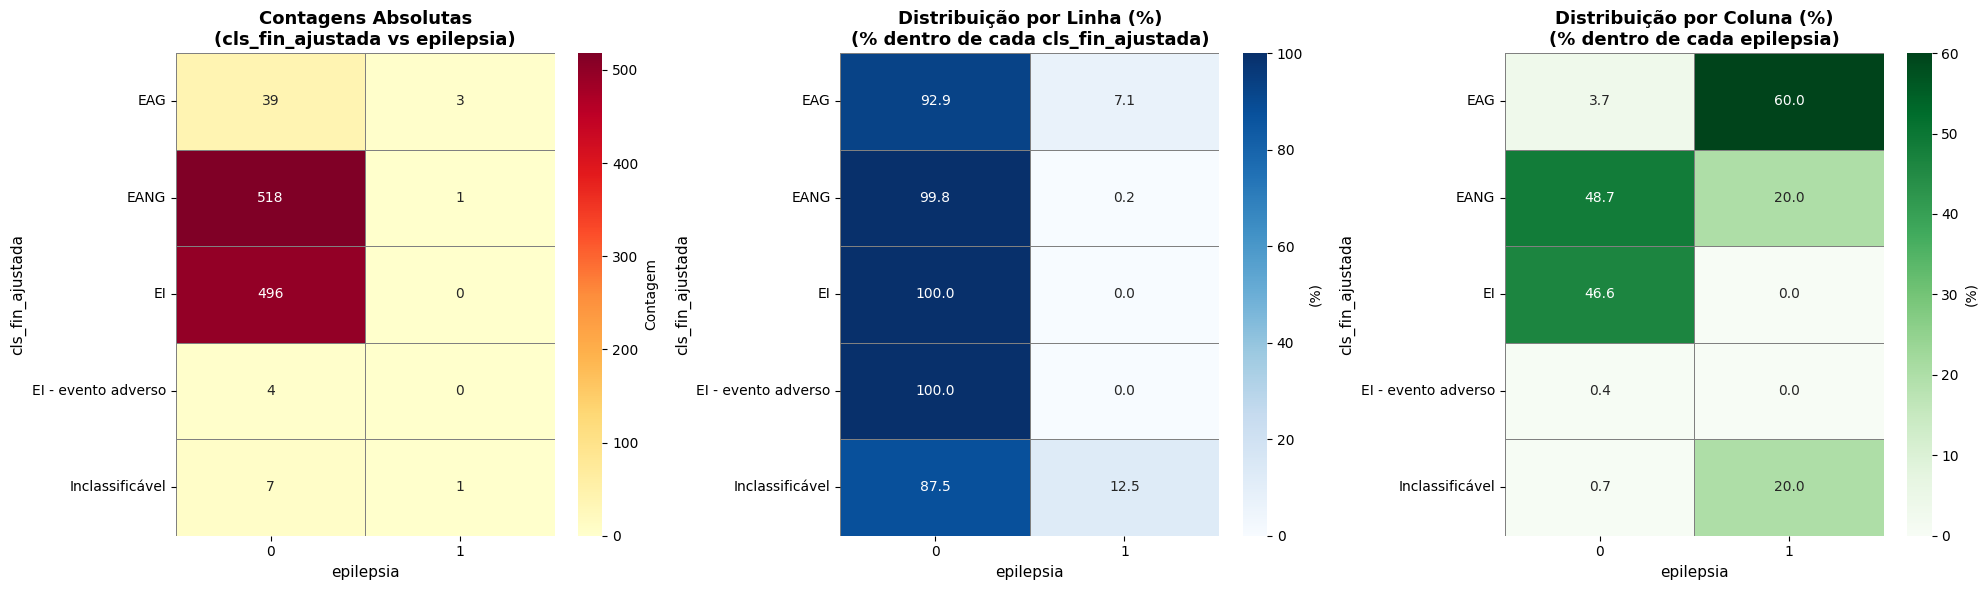


Gerando gráficos para: paralisia vs cls_fin_ajustada


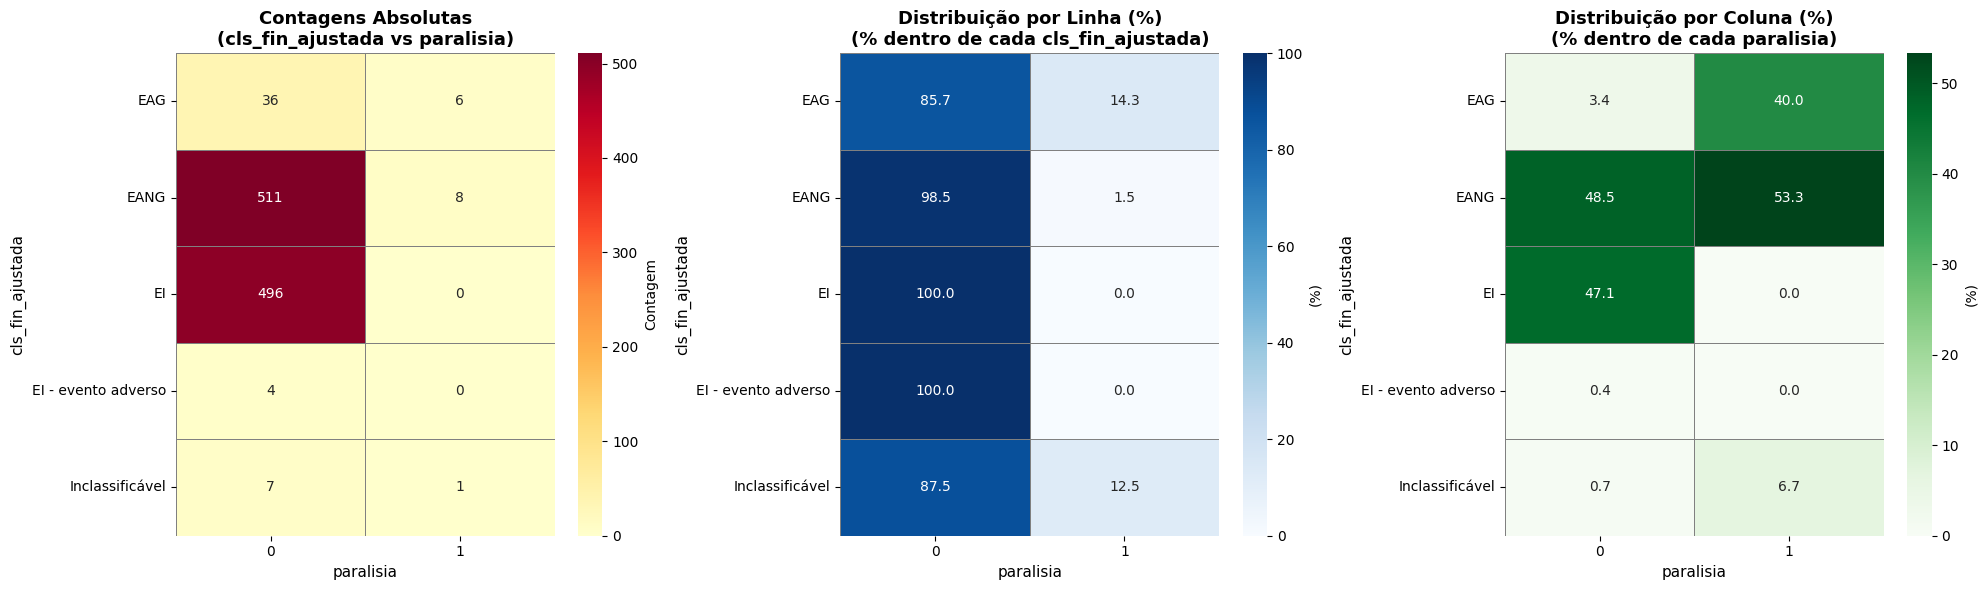


Gerando gráficos para: purpura_trombocitopenica vs cls_fin_ajustada


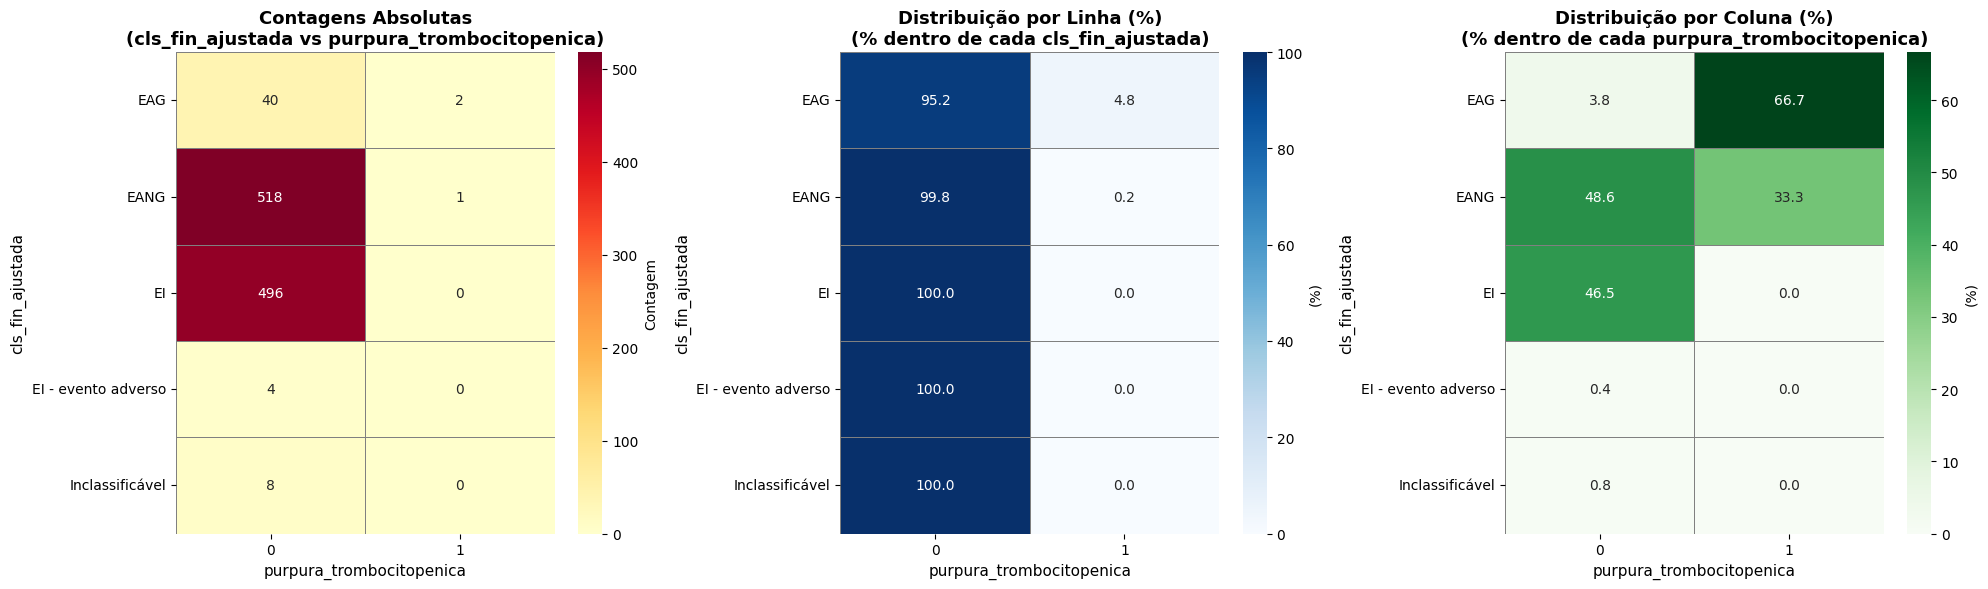


Gerando gráficos para: manifestacoes_locais vs cls_fin_ajustada


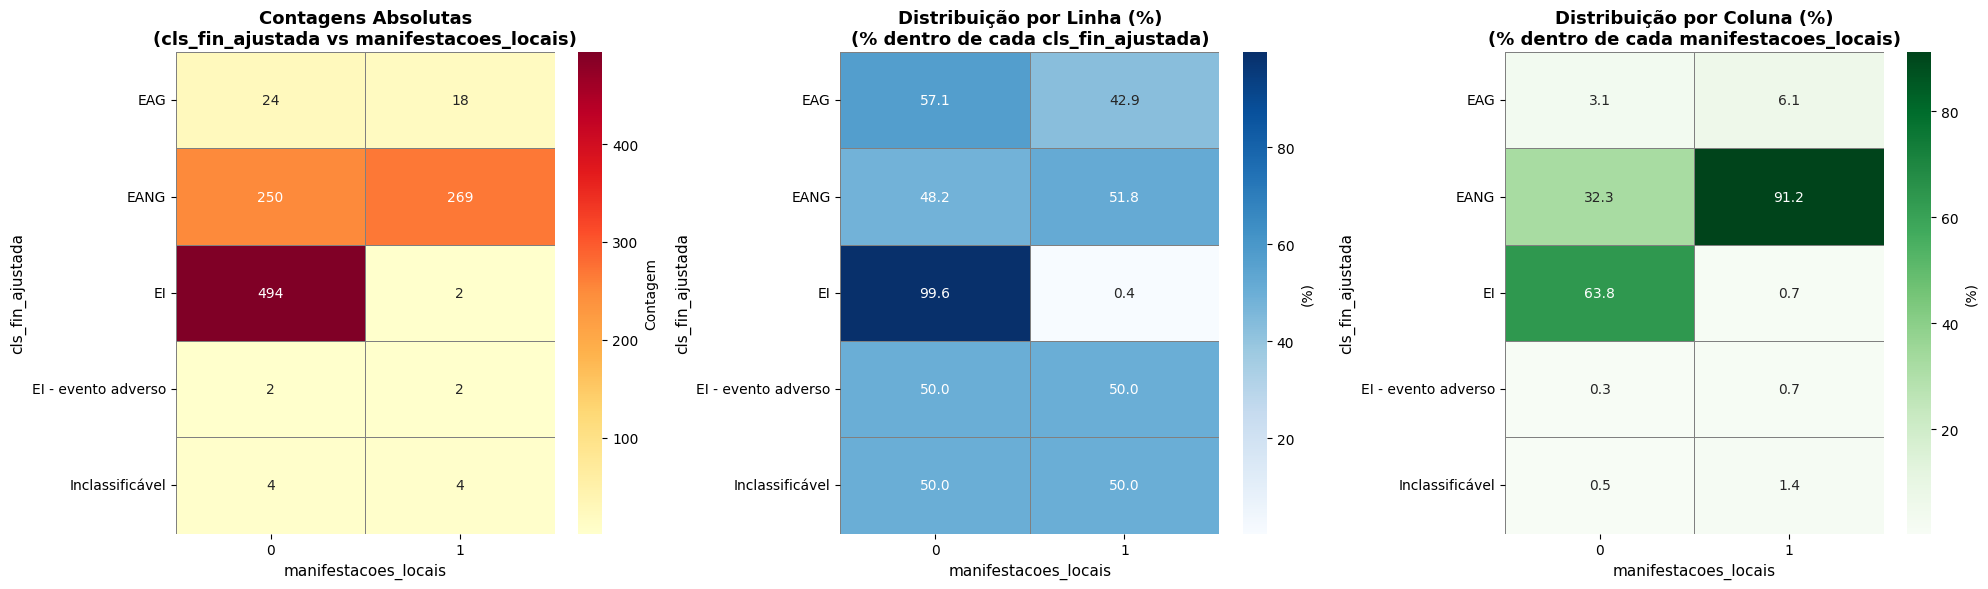


Gerando gráficos para: manifestacoes_sistemicas vs cls_fin_ajustada


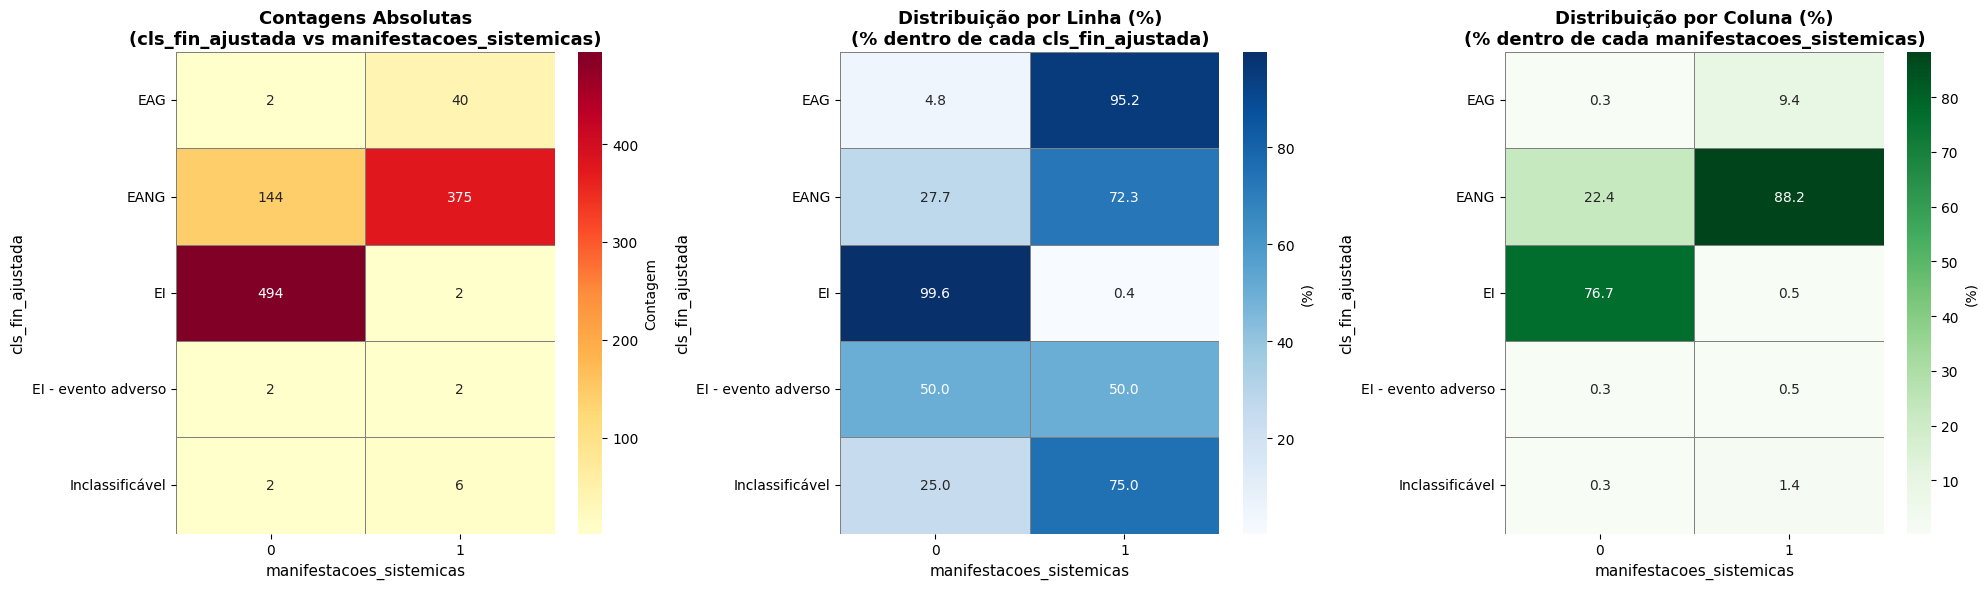

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Como coluna_resposta é uma lista no seu setup ['cls_fin_ajustada'], 
# vamos pegar a string dentro dela para usar nos títulos e eixos.
resposta = coluna_resposta[0] 

# Loop para passar por todas as variáveis explicativas
for comparacao in colunas_explicativas:
    
    # 1. Trava de segurança para variáveis com muitas categorias
    num_categorias = dados_finais[comparacao].nunique()
    if num_categorias > 20:
        print(f"\n{'-'*60}")
        print(f"Pulando '{comparacao}': possui {num_categorias} categorias.")
        print(f"Um heatmap com {num_categorias} colunas ficaria ilegível.")
        print(f"{'-'*60}\n")
        continue # Pula para a próxima variável da lista
        
    print(f"\nGerando gráficos para: {comparacao} vs {resposta}")
    
    # 2. Tabelas de Contingência
    # Usando dropna=False se quiser ver os nulos, ou deixe padrão para ignorá-los
    contagem = pd.crosstab(dados_finais[resposta], dados_finais[comparacao])
    percentual_linhas = pd.crosstab(dados_finais[resposta], dados_finais[comparacao], normalize='index') * 100
    percentual_colunas = pd.crosstab(dados_finais[resposta], dados_finais[comparacao], normalize='columns') * 100

    # 3. Configuração da Figura
    fig, axes = plt.subplots(1, 3, figsize=(20, 6)) # Aumentei um pouco a largura para caber bem as 3

    # --- Gráfico 1: Contagens Absolutas ---
    sns.heatmap(contagem, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Contagem'},
                ax=axes[0], linewidths=0.5, linecolor='gray')
    axes[0].set_title(f'Contagens Absolutas\n({resposta} vs {comparacao})', fontsize=13, fontweight='bold')
    axes[0].set_xlabel(comparacao, fontsize=11)
    axes[0].set_ylabel(resposta, fontsize=11)

    # --- Gráfico 2: Distribuição por Linha ---
    sns.heatmap(percentual_linhas, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': '(%)'},
                ax=axes[1], linewidths=0.5, linecolor='gray')
    axes[1].set_title(f'Distribuição por Linha (%)\n(% dentro de cada {resposta})', fontsize=13, fontweight='bold')
    axes[1].set_xlabel(comparacao, fontsize=11)
    axes[1].set_ylabel(resposta, fontsize=11)

    # --- Gráfico 3: Distribuição por Coluna ---
    sns.heatmap(percentual_colunas, annot=True, fmt='.1f', cmap='Greens', cbar_kws={'label': '(%)'},
                ax=axes[2], linewidths=0.5, linecolor='gray')
    axes[2].set_title(f'Distribuição por Coluna (%)\n(% dentro de cada {comparacao})', fontsize=13, fontweight='bold')
    axes[2].set_xlabel(comparacao, fontsize=11)
    axes[2].set_ylabel(resposta, fontsize=11)

    # Ajusta o layout para não cortar os eixos e exibe
    plt.tight_layout()
    plt.show()